Loading wind dataset from OPSD / Renewables.ninja ...
Loading UCI Air Quality dataset from official ZIP ...

Dataset: Wind-Norway-NextHour

Predictive performance
Validation: {'RMSE': 0.01284224039140155, 'MAE': 0.008996068924061549, 'R2': 0.9939276991144352}
Test      : {'RMSE': 0.010909089917469316, 'MAE': 0.007918639794952368, 'R2': 0.9946680806773558}

Running explainer: Kernel-MCIR

Running explainer: Gain

Running explainer: Permutation

Running explainer: MutualInfo

Running explainer: TreeSHAP

Running explainer: KernelSHAP


  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]


Explainer comparison summary
        method  stability_spearman  deletion_auc  runtime_sec
0  Kernel-MCIR            0.969644      0.054938     8.522740
1   MutualInfo            1.000000      0.054949    10.540433
2   KernelSHAP            0.928915      0.054990    69.994281
3  Permutation            0.826754      0.054999    23.145028
4         Gain            1.000000      0.055005     0.011037
5     TreeSHAP            0.973302      0.055009     0.584166

Kernel sensitivity (Kernel-MCIR rank agreement)
  kernel_a kernel_b  spearman_corr
0   linear     poly       0.911257
1   linear      rbf       0.966604
2     poly      rbf       0.929081


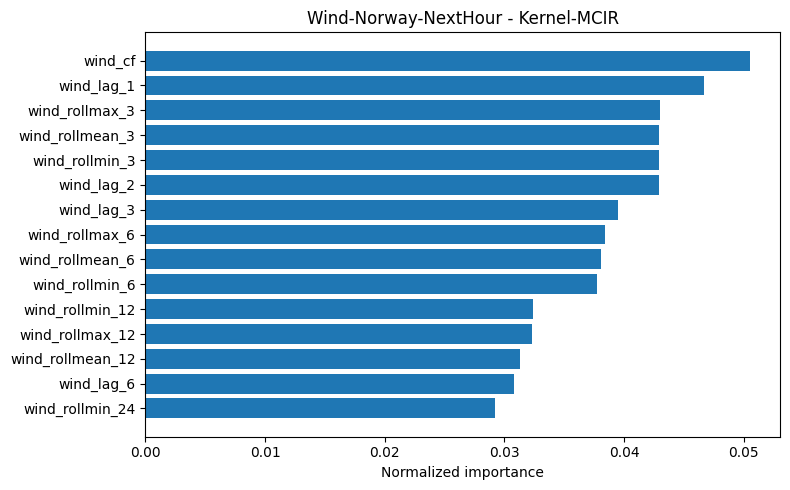

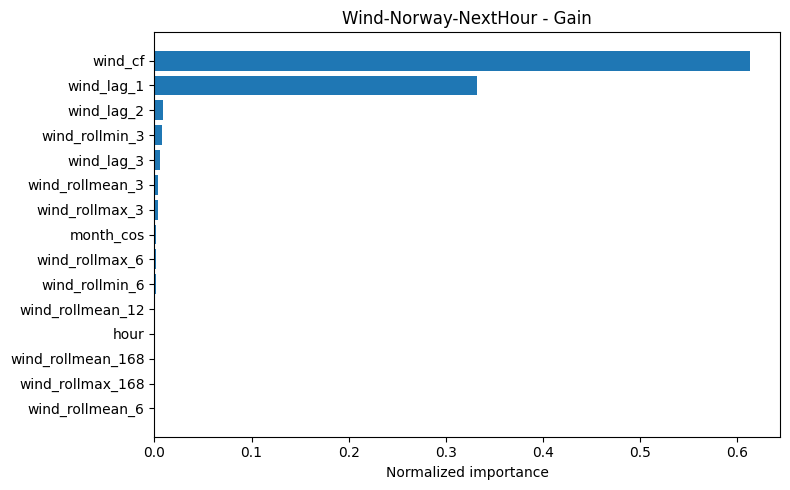

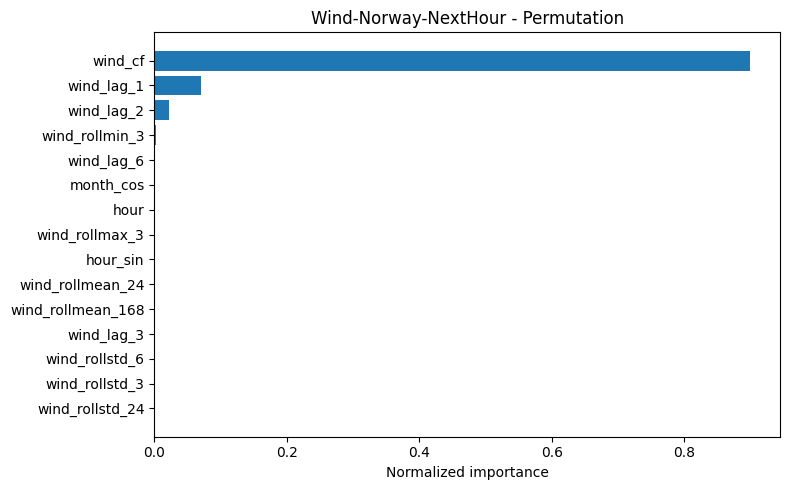

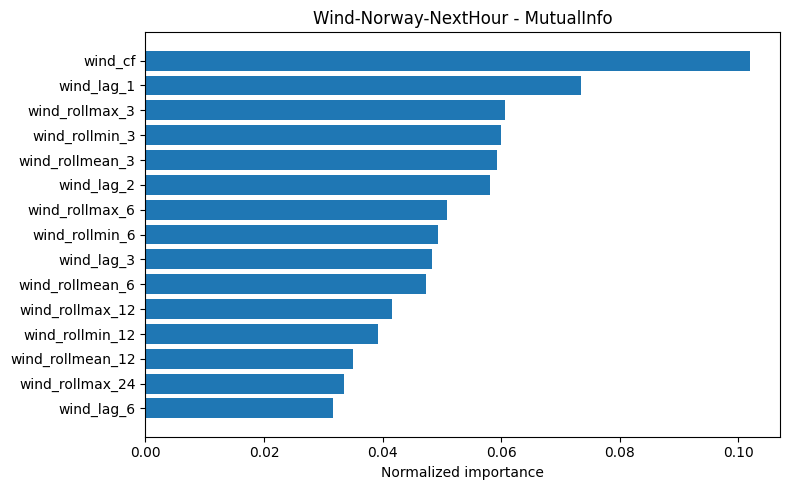

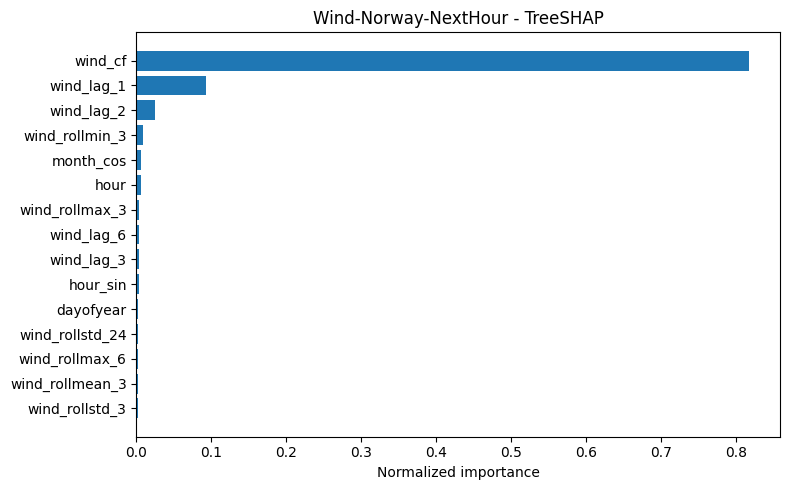

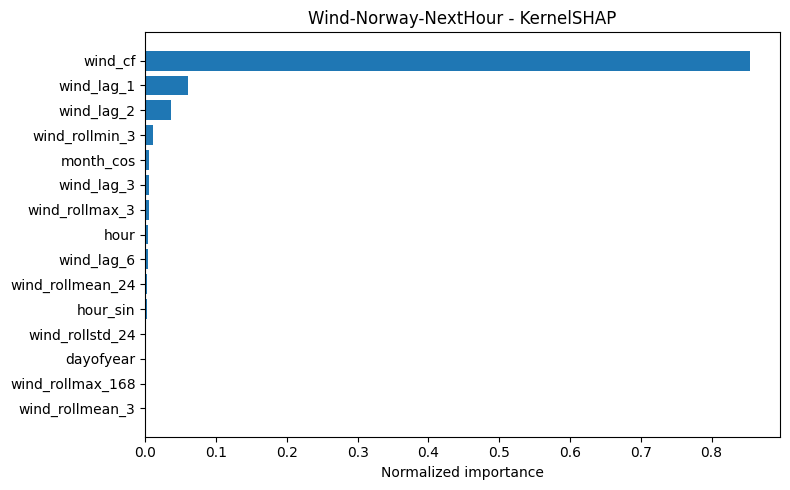

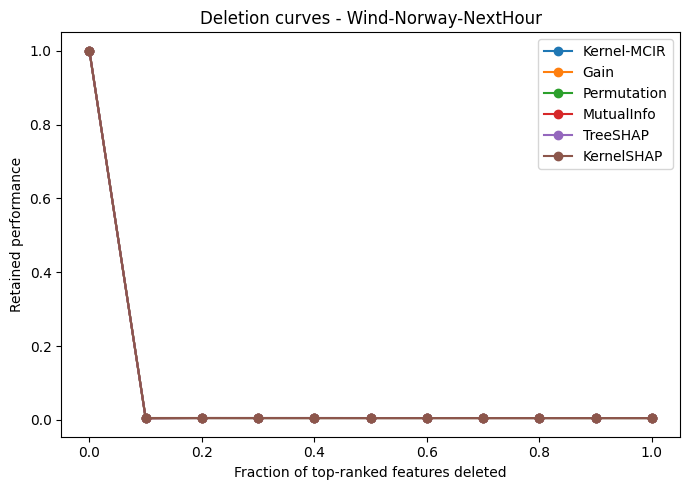

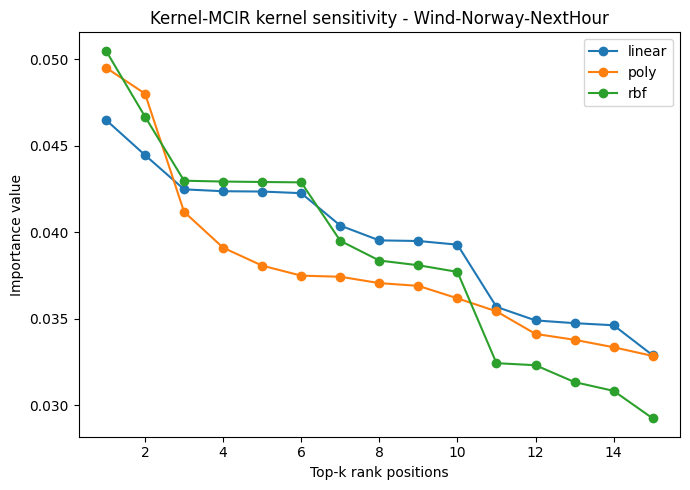


Dataset: UCI-AirQuality-NextHour-CO

Predictive performance
Validation: {'RMSE': 0.7712658056841096, 'MAE': 0.5128818923513249, 'R2': 0.6221428565966396}
Test      : {'RMSE': 0.5947083371572439, 'MAE': 0.4090180687259796, 'R2': 0.8079101024988388}

Running explainer: Kernel-MCIR

Running explainer: Gain

Running explainer: Permutation

Running explainer: MutualInfo

Running explainer: TreeSHAP

Running explainer: KernelSHAP


  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]


Explainer comparison summary
        method  stability_spearman  deletion_auc  runtime_sec
0     TreeSHAP            0.993321      0.221868     1.127389
1         Gain            1.000000      0.222147     0.001980
2  Permutation            0.704738      0.222443     2.241282
3   KernelSHAP            0.940184      0.223160    70.160680
4  Kernel-MCIR            0.796338      0.225497    10.913347
5   MutualInfo            1.000000      0.233487     0.625061

Kernel sensitivity (Kernel-MCIR rank agreement)
  kernel_a kernel_b  spearman_corr
0   linear     poly       0.855910
1   linear      rbf       0.907317
2     poly      rbf       0.759287


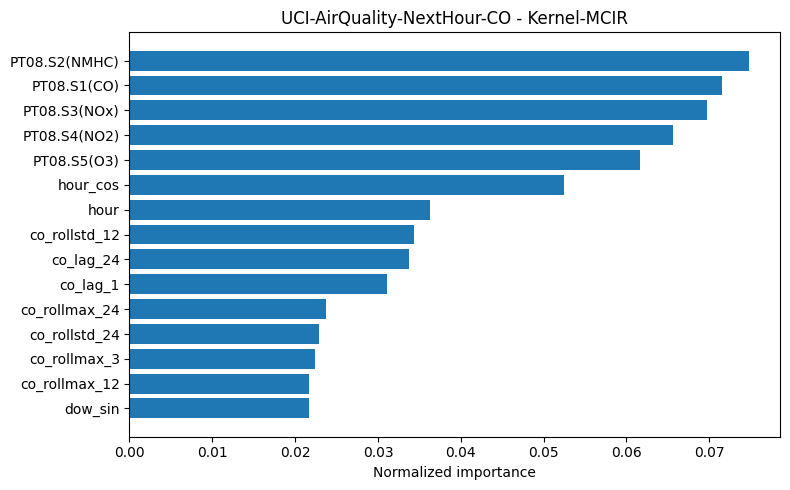

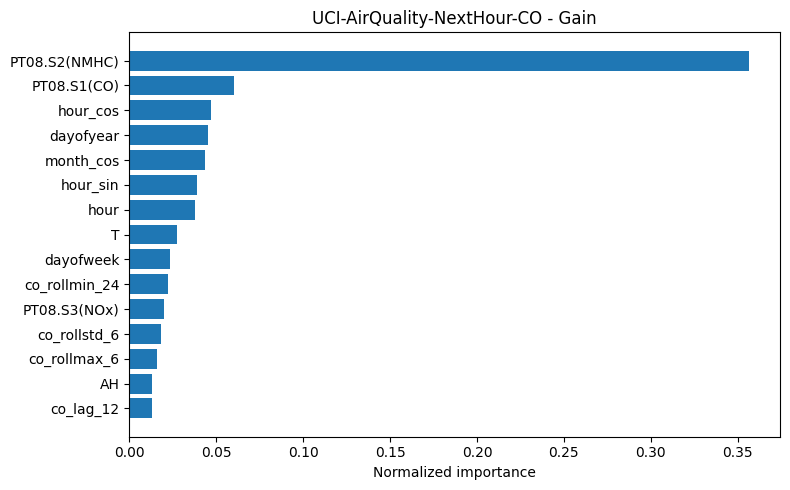

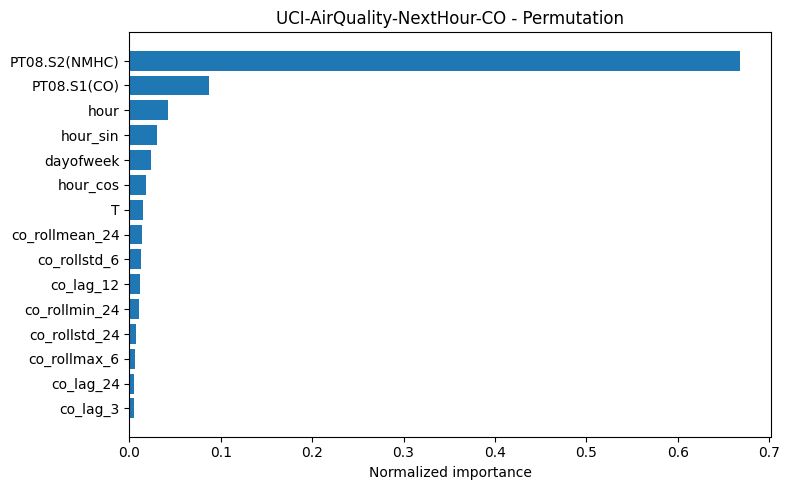

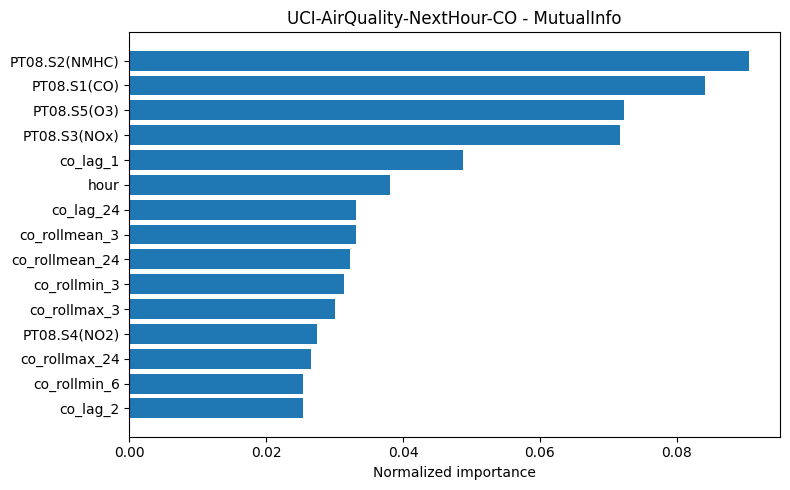

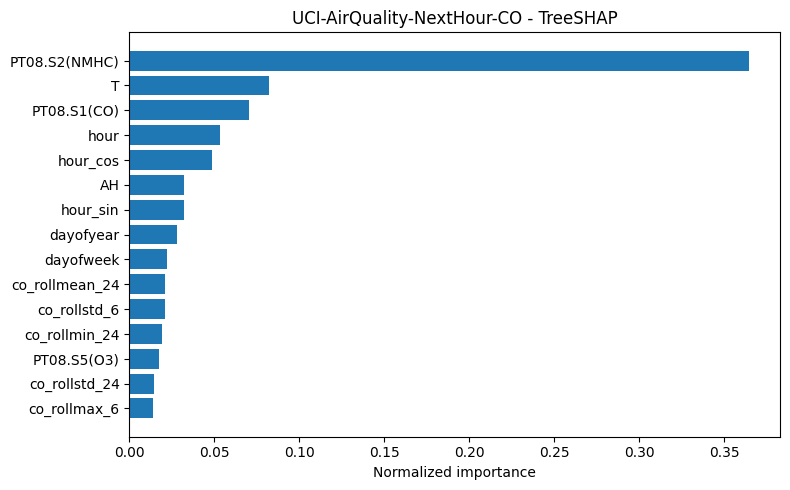

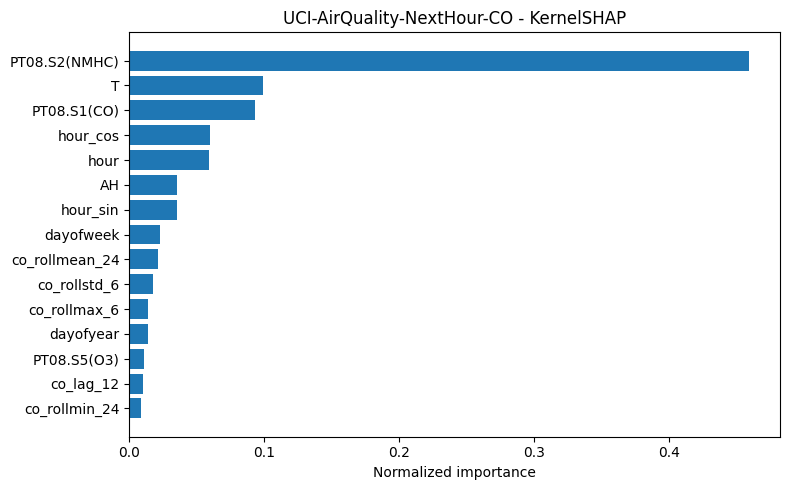

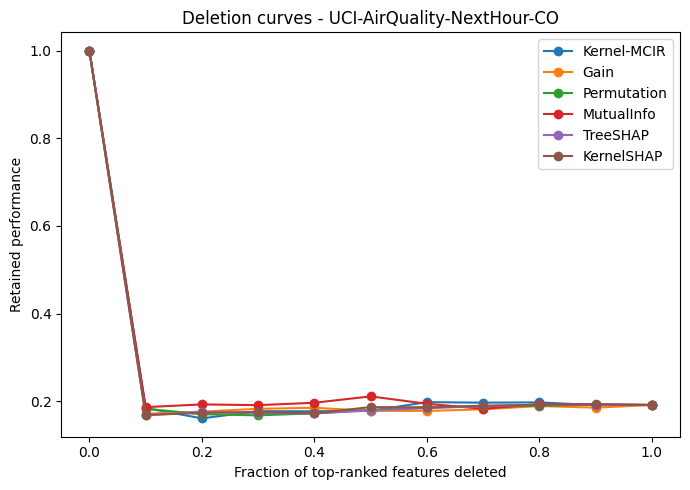

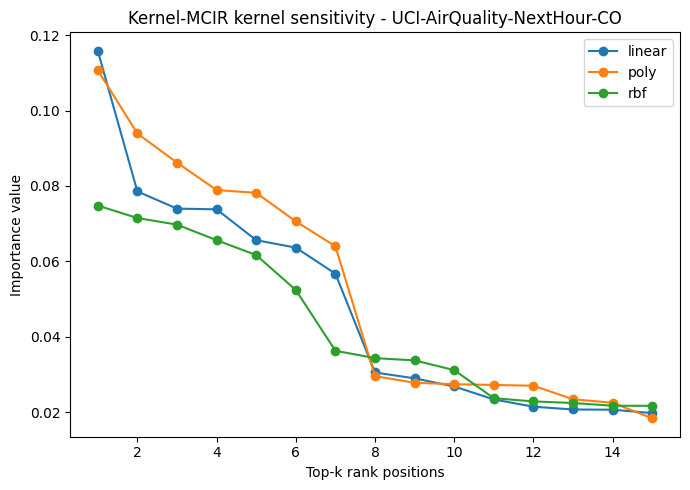


=== Synthetic redundancy stress test ===

Dataset: Synthetic-Redundancy

Predictive performance
Validation: {'RMSE': 0.12213816399457732, 'MAE': 0.09496780885422199, 'R2': 0.993336521571574}
Test      : {'RMSE': 0.13436456725181908, 'MAE': 0.10527784804782456, 'R2': 0.9909505291692604}

Running explainer: Kernel-MCIR

Running explainer: Gain

Running explainer: Permutation

Running explainer: MutualInfo

Running explainer: TreeSHAP

Running explainer: KernelSHAP


  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]


Explainer comparison summary
        method  stability_spearman  deletion_auc  runtime_sec
0  Kernel-MCIR                 0.7      0.158312     0.142246
1  Permutation                 1.0      0.159729     0.329361
2     TreeSHAP                 1.0      0.159729     0.587146
3   KernelSHAP                 1.0      0.159729     1.910287
4         Gain                 1.0      0.159772     0.001538
5   MutualInfo                 1.0      0.159772     0.079671

Kernel sensitivity (Kernel-MCIR rank agreement)
  kernel_a kernel_b  spearman_corr
0   linear     poly            0.8
1   linear      rbf           -0.1
2     poly      rbf            0.5
        method  stability_spearman  deletion_auc  runtime_sec
0  Kernel-MCIR                 0.7      0.158312     0.142246
1  Permutation                 1.0      0.159729     0.329361
2     TreeSHAP                 1.0      0.159729     0.587146
3   KernelSHAP                 1.0      0.159729     1.910287
4         Gain                 1.0   

In [ ]:
# ============================================================
# Google Colab single-script benchmark for:
#   1) Wind dataset (official OPSD / Renewables.ninja Norway wind)
#   2) UCI Air Quality dataset (official UCI ZIP download)
#
# Includes:
#   - proposed Kernel-MCIR style attribution
#   - SHAP comparison (Tree SHAP + Kernel SHAP)
#   - classical baselines (gain, permutation, MI)
#   - predictive evaluation
#   - deletion AUC
#   - stability across runs
#   - runtime
#   - kernel sensitivity study
#   - synthetic redundancy stress test
# ============================================================

# -----------------------------
# 0. Install dependencies
# -----------------------------
!pip -q install shap xgboost tqdm openpyxl

# -----------------------------
# 1. Imports
# -----------------------------
import os
import io
import time
import math
import random
import zipfile
import urllib.request
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from scipy.spatial.distance import pdist, squareform

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import mutual_info_regression

from xgboost import XGBRegressor
import shap

# -----------------------------
# 2. Reproducibility
# -----------------------------
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# -----------------------------
# 3. Global settings
# -----------------------------
N_STABILITY_RUNS = 5
EXPLAIN_SAMPLE = 256
KERNEL_SHAP_BG = 64
KERNEL_SHAP_EVAL = 64
PERM_REPEATS = 10
DELETION_STEPS = 11
TOPK_PLOT = 15

# Official sources
WIND_URL = "https://data.open-power-system-data.org/ninja_pv_wind_profiles/2020-09-16/ninja_pv_wind_profiles_singleindex.csv"
AIR_QUALITY_ZIP_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip"

# -----------------------------
# 4. Utilities
# -----------------------------
def set_seed(seed=SEED):
    np.random.seed(seed)
    random.seed(seed)

def clean_numeric_series(s):
    if pd.api.types.is_numeric_dtype(s):
        return pd.to_numeric(s, errors="coerce")
    return pd.to_numeric(
        s.astype(str).str.replace(",", ".", regex=False).str.strip(),
        errors="coerce"
    )

def chronological_split(df, train_frac=0.7, val_frac=0.15):
    n = len(df)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)
    train_df = df.iloc[:n_train].copy()
    val_df = df.iloc[n_train:n_train+n_val].copy()
    test_df = df.iloc[n_train+n_val:].copy()
    return train_df, val_df, test_df

def rmse(y_true, y_pred):
    return math.sqrt(mean_squared_error(y_true, y_pred))

def regression_metrics(y_true, y_pred):
    return {
        "RMSE": rmse(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

def add_calendar_features(df, time_col):
    df["hour"] = df[time_col].dt.hour
    df["dayofweek"] = df[time_col].dt.dayofweek
    df["dayofyear"] = df[time_col].dt.dayofyear
    df["month"] = df[time_col].dt.month

    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    return df

def make_lag_features(df, target_col, lags, prefix=None):
    prefix = prefix or target_col
    for lag in lags:
        df[f"{prefix}_lag_{lag}"] = df[target_col].shift(lag)
    return df

def make_rolling_features(df, target_col, windows, shift_first=True, prefix=None):
    prefix = prefix or target_col
    base = df[target_col].shift(1) if shift_first else df[target_col]
    for w in windows:
        df[f"{prefix}_rollmean_{w}"] = base.rolling(w).mean()
        df[f"{prefix}_rollstd_{w}"] = base.rolling(w).std()
        df[f"{prefix}_rollmin_{w}"] = base.rolling(w).min()
        df[f"{prefix}_rollmax_{w}"] = base.rolling(w).max()
    return df

def sample_rows(X, y=None, n=EXPLAIN_SAMPLE, seed=SEED):
    n = min(n, len(X))
    idx = np.random.default_rng(seed).choice(len(X), size=n, replace=False)
    if y is None:
        return X[idx], idx
    return X[idx], y[idx], idx

def normalize_importance(scores):
    scores = np.asarray(scores, dtype=float)
    scores = np.nan_to_num(scores, nan=0.0, posinf=0.0, neginf=0.0)
    scores = np.abs(scores)
    s = scores.sum()
    if s <= 0:
        return np.ones_like(scores) / len(scores)
    return scores / s

def pairwise_mean_spearman(vectors):
    vals = []
    for i in range(len(vectors)):
        for j in range(i + 1, len(vectors)):
            rho = spearmanr(vectors[i], vectors[j]).correlation
            if np.isnan(rho):
                rho = 0.0
            vals.append(rho)
    return float(np.mean(vals)) if vals else np.nan

def auc_trapz(y, x):
    return np.trapz(y, x)

# -----------------------------
# 5. Dataset loaders
# -----------------------------
def load_wind_dataset():
    print("Loading wind dataset from OPSD / Renewables.ninja ...")
    usecols = ["time", "NO_wind_national_current"]
    df = pd.read_csv(WIND_URL, usecols=usecols, parse_dates=["time"])
    df = df.rename(columns={"NO_wind_national_current": "wind_cf"})
    df = df.sort_values("time").dropna().reset_index(drop=True)

    if len(df) > 50000:
        df = df.iloc[-50000:].reset_index(drop=True)

    df = add_calendar_features(df, "time")
    df = make_lag_features(df, "wind_cf", lags=[1, 2, 3, 6, 12, 24, 48, 72, 168], prefix="wind")
    df = make_rolling_features(df, "wind_cf", windows=[3, 6, 12, 24, 168], shift_first=True, prefix="wind")

    df["target"] = df["wind_cf"].shift(-1)
    df = df.dropna().reset_index(drop=True)

    feature_cols = [c for c in df.columns if c not in ["time", "target"]]
    train_df, val_df, test_df = chronological_split(df)

    return {
        "name": "Wind-Norway-NextHour",
        "task": "regression",
        "feature_cols": feature_cols,
        "train_df": train_df,
        "val_df": val_df,
        "test_df": test_df,
    }

def load_air_quality_dataset():
    print("Loading UCI Air Quality dataset from official ZIP ...")
    response = urllib.request.urlopen(AIR_QUALITY_ZIP_URL)
    zip_bytes = io.BytesIO(response.read())

    with zipfile.ZipFile(zip_bytes) as zf:
        file_names = zf.namelist()
        csv_name = None
        for name in file_names:
            if "AirQualityUCI.csv" in name:
                csv_name = name
                break
        if csv_name is None:
            raise FileNotFoundError(f"AirQualityUCI.csv not found inside ZIP. Files: {file_names}")

        with zf.open(csv_name) as f:
            # This file is semicolon-separated and often has two empty trailing columns
            df = pd.read_csv(f, sep=";", decimal=",", encoding="latin1")

    # Drop fully empty columns and unnamed garbage columns
    df = df.dropna(axis=1, how="all")
    df.columns = [str(c).strip() for c in df.columns]
    df = df.loc[:, ~df.columns.str.contains("^Unnamed", case=False, na=False)]

    # Standardize likely column names
    rename_map = {}
    for c in df.columns:
        c_clean = c.strip()
        if c_clean.lower() == "date":
            rename_map[c] = "Date"
        elif c_clean.lower() == "time":
            rename_map[c] = "Time"
        else:
            rename_map[c] = c_clean
    df = df.rename(columns=rename_map)

    # Replace missing code -200 with NaN and clean numerics
    for c in df.columns:
        if c not in ["Date", "Time"]:
            df[c] = clean_numeric_series(df[c])
            df[c] = df[c].replace(-200, np.nan)

    # Parse datetime
    df["datetime"] = pd.to_datetime(
        df["Date"].astype(str) + " " + df["Time"].astype(str).str.replace(".", ":", regex=False),
        format="%d/%m/%Y %H.%M.%S",
        errors="coerce"
    )

    # Fallback parser if needed
    bad = df["datetime"].isna().sum()
    if bad > 0:
        df["datetime"] = pd.to_datetime(
            df["Date"].astype(str) + " " + df["Time"].astype(str).str.replace(".", ":", regex=False),
            dayfirst=True,
            errors="coerce"
        )

    df = df.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)

    # UCI target
    target_col = "CO(GT)"
    if target_col not in df.columns:
        candidates = [c for c in df.columns if "CO" in c and "GT" in c]
        if not candidates:
            raise ValueError(f"Could not locate CO(GT) column. Available columns: {df.columns.tolist()}")
        target_col = candidates[0]

    df = add_calendar_features(df, "datetime")
    df = make_lag_features(df, target_col, lags=[1, 2, 3, 6, 12, 24], prefix="co")
    df = make_rolling_features(df, target_col, windows=[3, 6, 12, 24], shift_first=True, prefix="co")

    df["target"] = df[target_col].shift(-1)

    sensor_cols = [c for c in df.columns if "PT08" in c.upper()]
    weather_cols = [c for c in df.columns if c in ["T", "RH", "AH"]]

    feature_cols = []
    feature_cols += sensor_cols
    feature_cols += weather_cols
    feature_cols += [c for c in df.columns if c.startswith("co_lag_") or c.startswith("co_roll")]
    feature_cols += [
        "hour", "dayofweek", "dayofyear", "month",
        "hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos"
    ]
    feature_cols = list(dict.fromkeys([c for c in feature_cols if c in df.columns]))

    df = df[["datetime"] + feature_cols + ["target"]].dropna().reset_index(drop=True)

    train_df, val_df, test_df = chronological_split(df)

    return {
        "name": "UCI-AirQuality-NextHour-CO",
        "task": "regression",
        "feature_cols": feature_cols,
        "train_df": train_df,
        "val_df": val_df,
        "test_df": test_df,
    }

# -----------------------------
# 6. Modeling
# -----------------------------
def prepare_xy(dataset):
    feature_cols = dataset["feature_cols"]
    train_df = dataset["train_df"]
    val_df = dataset["val_df"]
    test_df = dataset["test_df"]

    X_train = train_df[feature_cols].copy()
    y_train = train_df["target"].values.astype(float)

    X_val = val_df[feature_cols].copy()
    y_val = val_df["target"].values.astype(float)

    X_test = test_df[feature_cols].copy()
    y_test = test_df["target"].values.astype(float)

    prep = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    X_train_p = prep.fit_transform(X_train)
    X_val_p = prep.transform(X_val)
    X_test_p = prep.transform(X_test)

    return feature_cols, prep, X_train_p, y_train, X_val_p, y_val, X_test_p, y_test

def train_xgb_regressor(X_train, y_train, X_val, y_val, seed=SEED):
    model = XGBRegressor(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=seed,
        tree_method="hist",
        eval_metric="rmse",
    )
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    return model

# -----------------------------
# 7. Kernel-MCIR style importance
# -----------------------------
def center_kernel(K):
    n = K.shape[0]
    H = np.eye(n) - np.ones((n, n)) / n
    return H @ K @ H

def linear_kernel_1d(x):
    x = x.reshape(-1, 1)
    return x @ x.T

def poly_kernel_1d(x, degree=2, coef0=1.0):
    x = x.reshape(-1, 1)
    return (x @ x.T + coef0) ** degree

def rbf_kernel_1d(x, gamma=None):
    x = x.reshape(-1, 1)
    D = squareform(pdist(x, metric="sqeuclidean"))
    if gamma is None:
        med = np.median(D[D > 0]) if np.any(D > 0) else 1.0
        gamma = 1.0 / (2.0 * med + 1e-12)
    return np.exp(-gamma * D)

def hsic_alignment(K1, K2):
    K1c = center_kernel(K1)
    K2c = center_kernel(K2)
    num = np.sum(K1c * K2c)
    den = np.sqrt(np.sum(K1c * K1c) * np.sum(K2c * K2c)) + 1e-12
    return float(num / den)

def build_output_kernel(y, kernel="rbf"):
    if kernel == "linear":
        return linear_kernel_1d(y)
    elif kernel == "poly":
        return poly_kernel_1d(y)
    return rbf_kernel_1d(y)

def build_feature_kernel(x, kernel="rbf"):
    if kernel == "linear":
        return linear_kernel_1d(x)
    elif kernel == "poly":
        return poly_kernel_1d(x)
    return rbf_kernel_1d(x)

def kernel_mcir_importance(X, y_signal, kernel="rbf"):
    n, p = X.shape
    Ky = build_output_kernel(y_signal, kernel=kernel)

    K_features = [build_feature_kernel(X[:, j], kernel=kernel) for j in range(p)]
    relevance = np.array([hsic_alignment(Kj, Ky) for Kj in K_features])

    redundancy = np.zeros(p)
    for j in range(p):
        vals = []
        for k in range(p):
            if k == j:
                continue
            vals.append(abs(hsic_alignment(K_features[j], K_features[k])))
        redundancy[j] = np.mean(vals) if vals else 0.0

    scores = relevance / (1e-6 + redundancy)
    return normalize_importance(scores)

# -----------------------------
# 8. Explanation methods
# -----------------------------
def get_tree_gain_importance(model, p):
    imp = model.feature_importances_
    if len(imp) != p:
        out = np.zeros(p)
        out[:len(imp)] = imp
        imp = out
    return normalize_importance(imp)

def get_mutual_info_importance(X_train, y_train):
    imp = mutual_info_regression(X_train, y_train, random_state=SEED)
    return normalize_importance(imp)

def get_permutation_importance(model, X_val, y_val):
    r = permutation_importance(
        model, X_val, y_val,
        n_repeats=PERM_REPEATS,
        random_state=SEED,
        scoring="neg_root_mean_squared_error"
    )
    return normalize_importance(r.importances_mean)

def get_tree_shap_importance(model, X_bg):
    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(X_bg)
    if isinstance(sv, list):
        sv = sv[0]
    imp = np.mean(np.abs(sv), axis=0)
    return normalize_importance(imp)

def get_kernel_shap_importance(model, X_bg, X_eval):
    bg = shap.sample(X_bg, min(KERNEL_SHAP_BG, len(X_bg)), random_state=SEED)
    X_eval = shap.sample(X_eval, min(KERNEL_SHAP_EVAL, len(X_eval)), random_state=SEED)

    f = lambda x: model.predict(x)
    explainer = shap.KernelExplainer(f, bg)
    sv = explainer.shap_values(X_eval, nsamples="auto")
    if isinstance(sv, list):
        sv = sv[0]
    imp = np.mean(np.abs(sv), axis=0)
    return normalize_importance(imp)

# -----------------------------
# 9. Deletion AUC
# -----------------------------
def masked_copy(X, feature_indices, baseline):
    Xm = X.copy()
    Xm[:, feature_indices] = baseline[feature_indices]
    return Xm

def deletion_auc_regression(model, X_test, y_test, importance, baseline):
    ranking = np.argsort(-importance)
    fractions = np.linspace(0, 1, DELETION_STEPS)

    base_pred = model.predict(X_test)
    base_loss = mean_squared_error(y_test, base_pred) + 1e-12

    retained_scores = []
    p = X_test.shape[1]

    for frac in fractions:
        k = int(round(frac * p))
        idx = ranking[:k]
        X_mask = masked_copy(X_test, idx, baseline)
        pred = model.predict(X_mask)
        loss = mean_squared_error(y_test, pred) + 1e-12

        retained = base_loss / loss
        retained = float(np.clip(retained, 0.0, 1.0))
        retained_scores.append(retained)

    auc = auc_trapz(retained_scores, fractions)
    return auc, fractions, retained_scores

# -----------------------------
# 10. Stability
# -----------------------------
def bootstrap_indices(n, rng):
    return rng.choice(n, size=n, replace=True)

def compute_method_importance(method_name, model, X_train, y_train, X_val, y_val, subset_seed=SEED, kernel="rbf"):
    rng = np.random.default_rng(subset_seed)
    idx = bootstrap_indices(len(X_val), rng)
    X_sub = X_val[idx]
    y_sub = y_val[idx]

    X_small, _, small_idx = sample_rows(X_sub, y_sub, n=EXPLAIN_SAMPLE, seed=subset_seed)
    y_small = y_sub[small_idx]

    if method_name == "Kernel-MCIR":
        y_signal = model.predict(X_small)
        return kernel_mcir_importance(X_small, y_signal, kernel=kernel)
    elif method_name == "Gain":
        return get_tree_gain_importance(model, X_train.shape[1])
    elif method_name == "Permutation":
        return get_permutation_importance(model, X_sub, y_sub)
    elif method_name == "MutualInfo":
        return get_mutual_info_importance(X_train, y_train)
    elif method_name == "TreeSHAP":
        return get_tree_shap_importance(model, X_small)
    elif method_name == "KernelSHAP":
        X_bg_small, _ = sample_rows(X_train, n=min(EXPLAIN_SAMPLE, len(X_train)), seed=subset_seed)
        return get_kernel_shap_importance(model, X_bg_small, X_small)
    else:
        raise ValueError(f"Unknown method: {method_name}")

def evaluate_explainer(method_name, model, X_train, y_train, X_val, y_val, X_test, y_test, feature_names, kernel="rbf"):
    start = time.perf_counter()
    importance = compute_method_importance(
        method_name, model, X_train, y_train, X_val, y_val, subset_seed=SEED, kernel=kernel
    )
    runtime = time.perf_counter() - start

    stability_vectors = []
    for run in range(N_STABILITY_RUNS):
        imp_r = compute_method_importance(
            method_name, model, X_train, y_train, X_val, y_val,
            subset_seed=SEED + 100 + run, kernel=kernel
        )
        stability_vectors.append(imp_r)
    stability = pairwise_mean_spearman(stability_vectors)

    baseline = np.nanmedian(X_train, axis=0)
    deletion_auc, fractions, retained = deletion_auc_regression(
        model, X_test, y_test, importance, baseline
    )

    top_idx = np.argsort(-importance)[:TOPK_PLOT]
    top_features = [(feature_names[i], float(importance[i])) for i in top_idx]

    return {
        "method": method_name if method_name != "Kernel-MCIR" or kernel == "rbf" else f"Kernel-MCIR-{kernel}",
        "importance": importance,
        "runtime_sec": runtime,
        "stability_spearman": stability,
        "deletion_auc": deletion_auc,
        "fractions": fractions,
        "retained_curve": retained,
        "top_features": top_features,
    }

# -----------------------------
# 11. Synthetic redundancy benchmark
# -----------------------------
def synthetic_redundancy_benchmark():
    print("\n=== Synthetic redundancy stress test ===")
    rng = np.random.default_rng(SEED)
    n = 4000

    x1 = rng.normal(size=n)
    x2 = x1 + 0.08 * rng.normal(size=n)
    x3 = rng.uniform(-2, 2, size=n)
    x4 = rng.normal(size=n)
    x5 = rng.normal(size=n)

    y = np.sin(1.5 * x1) + 0.8 * np.sin(1.2 * x2) + 0.6 * (x3 ** 2) + 0.2 * x4 + 0.1 * rng.normal(size=n)

    df = pd.DataFrame({
        "x1_main": x1,
        "x2_redundant": x2,
        "x3_nonlinear": x3,
        "x4_weak": x4,
        "x5_noise": x5,
        "target": y
    })

    train_df, val_df, test_df = chronological_split(df)
    feature_cols = [c for c in df.columns if c != "target"]

    dataset = {
        "name": "Synthetic-Redundancy",
        "feature_cols": feature_cols,
        "train_df": train_df,
        "val_df": val_df,
        "test_df": test_df,
        "task": "regression"
    }

    results = run_full_benchmark(dataset, show_plots=False)

    print(results["summary"][["method", "stability_spearman", "deletion_auc", "runtime_sec"]].sort_values(
        by=["deletion_auc", "stability_spearman"], ascending=[True, False]
    ))

    return results

# -----------------------------
# 12. Plotting
# -----------------------------
def plot_top_features(feature_names, importance, title, topk=TOPK_PLOT):
    idx = np.argsort(-importance)[:topk]
    names = [feature_names[i] for i in idx][::-1]
    vals = importance[idx][::-1]

    plt.figure(figsize=(8, 5))
    plt.barh(names, vals)
    plt.title(title)
    plt.xlabel("Normalized importance")
    plt.tight_layout()
    plt.show()

def plot_deletion_curves(results, dataset_name):
    plt.figure(figsize=(7, 5))
    for r in results:
        plt.plot(r["fractions"], r["retained_curve"], marker="o", label=r["method"])
    plt.xlabel("Fraction of top-ranked features deleted")
    plt.ylabel("Retained performance")
    plt.title(f"Deletion curves - {dataset_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_kernel_sensitivity(kernel_results, dataset_name):
    methods = [k for k in kernel_results.keys()]
    plt.figure(figsize=(7, 5))
    for m in methods:
        idx = np.argsort(-kernel_results[m])[:TOPK_PLOT]
        plt.plot(np.arange(1, len(idx)+1), kernel_results[m][idx], marker="o", label=m)
    plt.xlabel("Top-k rank positions")
    plt.ylabel("Importance value")
    plt.title(f"Kernel-MCIR kernel sensitivity - {dataset_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# -----------------------------
# 13. Main benchmark runner
# -----------------------------
def run_full_benchmark(dataset, show_plots=True):
    print(f"\n==============================")
    print(f"Dataset: {dataset['name']}")
    print(f"==============================")

    feature_names, prep, X_train, y_train, X_val, y_val, X_test, y_test = prepare_xy(dataset)

    model = train_xgb_regressor(X_train, y_train, X_val, y_val)

    pred_val = model.predict(X_val)
    pred_test = model.predict(X_test)

    val_metrics = regression_metrics(y_val, pred_val)
    test_metrics = regression_metrics(y_test, pred_test)

    print("\nPredictive performance")
    print("Validation:", val_metrics)
    print("Test      :", test_metrics)

    methods = ["Kernel-MCIR", "Gain", "Permutation", "MutualInfo", "TreeSHAP", "KernelSHAP"]
    results = []

    for method in methods:
        print(f"\nRunning explainer: {method}")
        r = evaluate_explainer(method, model, X_train, y_train, X_val, y_val, X_test, y_test, feature_names, kernel="rbf")
        results.append(r)

    summary = pd.DataFrame([{
        "method": r["method"],
        "stability_spearman": r["stability_spearman"],
        "deletion_auc": r["deletion_auc"],
        "runtime_sec": r["runtime_sec"],
    } for r in results])

    summary = summary.sort_values(by=["deletion_auc", "stability_spearman"], ascending=[True, False]).reset_index(drop=True)

    print("\nExplainer comparison summary")
    print(summary)

    kernel_results = {}
    kernel_corr = []
    for kernel_name in ["linear", "poly", "rbf"]:
        r = evaluate_explainer("Kernel-MCIR", model, X_train, y_train, X_val, y_val, X_test, y_test, feature_names, kernel=kernel_name)
        kernel_results[kernel_name] = r["importance"]

    kernels = list(kernel_results.keys())
    for i in range(len(kernels)):
        for j in range(i + 1, len(kernels)):
            rho = spearmanr(kernel_results[kernels[i]], kernel_results[kernels[j]]).correlation
            kernel_corr.append({
                "kernel_a": kernels[i],
                "kernel_b": kernels[j],
                "spearman_corr": rho
            })
    kernel_corr_df = pd.DataFrame(kernel_corr)

    print("\nKernel sensitivity (Kernel-MCIR rank agreement)")
    print(kernel_corr_df)

    if show_plots:
        for r in results:
            plot_top_features(feature_names, r["importance"], f"{dataset['name']} - {r['method']}")
        plot_deletion_curves(results, dataset["name"])
        plot_kernel_sensitivity(kernel_results, dataset["name"])

    return {
        "dataset_name": dataset["name"],
        "feature_names": feature_names,
        "model": model,
        "preprocessor": prep,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "results": results,
        "summary": summary,
        "kernel_corr": kernel_corr_df,
        "kernel_results": kernel_results,
    }

# -----------------------------
# 14. Run everything
# -----------------------------
set_seed(SEED)

wind_ds = load_wind_dataset()
aq_ds = load_air_quality_dataset()

wind_results = run_full_benchmark(wind_ds, show_plots=True)
aq_results = run_full_benchmark(aq_ds, show_plots=True)
synthetic_results = synthetic_redundancy_benchmark()

# -----------------------------
# 15. Final combined tables
# -----------------------------
def add_dataset_name(summary_df, name):
    out = summary_df.copy()
    out.insert(0, "dataset", name)
    return out

final_summary = pd.concat([
    add_dataset_name(wind_results["summary"], wind_results["dataset_name"]),
    add_dataset_name(aq_results["summary"], aq_results["dataset_name"]),
    add_dataset_name(synthetic_results["summary"], synthetic_results["dataset_name"]),
], axis=0).reset_index(drop=True)

print("\n==============================")
print("FINAL COMBINED SUMMARY")
print("==============================")
print(final_summary)

final_summary.to_csv("final_explainer_summary.csv", index=False)
wind_results["kernel_corr"].to_csv("wind_kernel_sensitivity.csv", index=False)
aq_results["kernel_corr"].to_csv("air_quality_kernel_sensitivity.csv", index=False)
synthetic_results["kernel_corr"].to_csv("synthetic_kernel_sensitivity.csv", index=False)

print("\nSaved:")
print(" - final_explainer_summary.csv")
print(" - wind_kernel_sensitivity.csv")
print(" - air_quality_kernel_sensitivity.csv")
print(" - synthetic_kernel_sensitivity.csv")

print("\nSuggested definitions for the paper:")
print("""
1) Stability:
   Mean pairwise Spearman correlation of importance vectors across repeated runs
   on bootstrap-resampled validation subsets.

2) Deletion AUC:
   Progressively remove top-ranked features and measure retained predictive
   performance. Lower AUC means performance collapses faster, indicating more
   faithful feature ranking.

3) Runtime:
   Wall-clock seconds for one explainer pass on the explanation subset.

4) Kernel sensitivity:
   Rank agreement of Kernel-MCIR under linear, polynomial, and RBF kernels.
""")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Loading wind dataset...
Loading UCI Air Quality...
Loading synthetic dataset...

DATASET: Wind-Norway-NextHour
Training MLP...
Training XGBoost...

MLP predictive performance
Validation: {'RMSE': 0.013654696622921562, 'MAE': 0.010028455214075204, 'R2': 0.9931350748920794}
Test      : {'RMSE': 0.011437124831509304, 'MAE': 0.008425846562292597, 'R2': 0.9941394247157801}

XGBoost predictive performance
Validation: {'RMSE': 0.01284224039140155, 'MAE': 0.008996068924061549, 'R2': 0.9939276991144352}
Test      : {'RMSE': 0.010909089917469316, 'MAE': 0.007918639794952368, 'R2': 0.9946680806773558}
Running: Kernel-MCIR
Running: UniqueOnly
Running: RedundantOnly
Running: HSIC
Running: CKA
Running: MutualInfo
Running: Permutation
Failed: Permutation -> The 'estimator' parameter of permutation_importance must be an object implementing 'fit'. Got <__main__.get_permutation_impor

  0%|          | 0/48 [00:00<?, ?it/s]

  0%|          | 0/48 [00:00<?, ?it/s]

  0%|          | 0/48 [00:00<?, ?it/s]

  0%|          | 0/48 [00:00<?, ?it/s]

...

Running: LIME
Running: IntegratedGradients
Running: DeepSHAP
Running: XGBGain
Running: TreeSHAP

Explainer summary
                 method model_type  stability_spearman  stability_kendall  \
0               XGBGain        xgb            1.000000           1.000000   
1              TreeSHAP        xgb            0.971126           0.888205   
2              DeepSHAP        mlp            0.945422           0.822051   
3                  LIME        mlp            0.997373           0.976923   
4   IntegratedGradients        mlp            0.917917           0.789231   
5            UniqueOnly        mlp            0.975891           0.889744   
6                   CKA        mlp            0.975891           0.889744   
7                  HSIC        mlp            0.975460           0.890256   
8            KernelSHAP        mlp            0.870718           0.733788   
9           Kernel-MCIR        mlp            0.927767           0.804615   
10           MutualInfo        mlp    

  0%|          | 0/48 [00:00<?, ?it/s]

  0%|          | 0/48 [00:00<?, ?it/s]

  0%|          | 0/48 [00:00<?, ?it/s]


Noise robustness summary
                method  spearman_clean_gaussian  spearman_clean_adversarial
0          Kernel-MCIR                 0.962289                    0.948030
1                 HSIC                 0.980300                    0.962289
2                  CKA                 0.981801                    0.966792
3           KernelSHAP                 0.926604                    0.899761
4  IntegratedGradients                 0.969043                    0.929644
5                 LIME                 0.999062                    0.996811
6             DeepSHAP                 0.973734                    0.972983


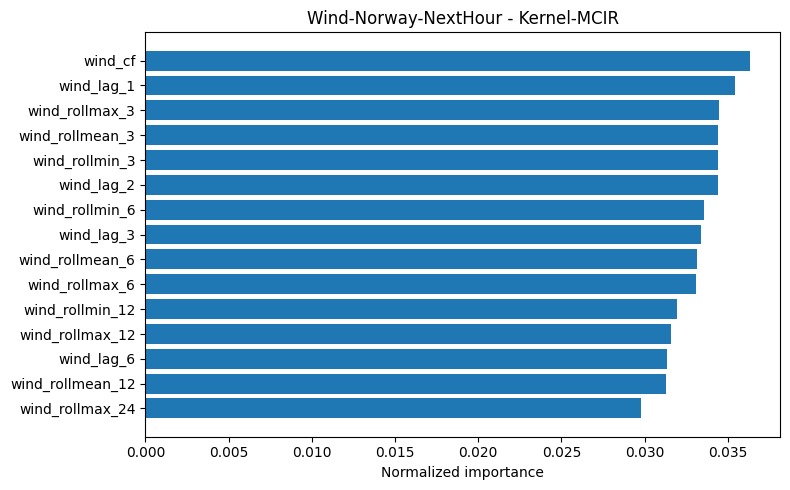

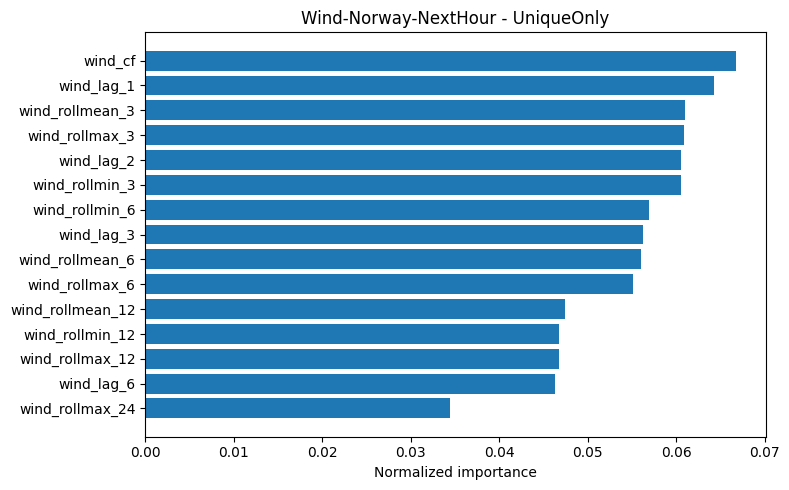

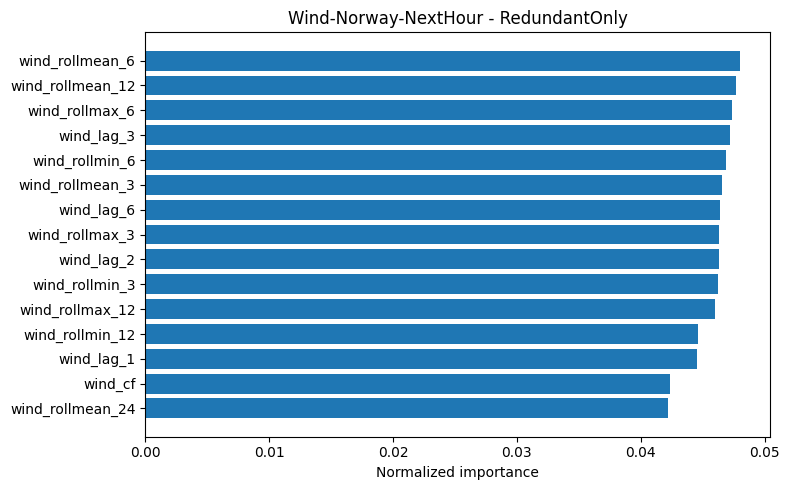

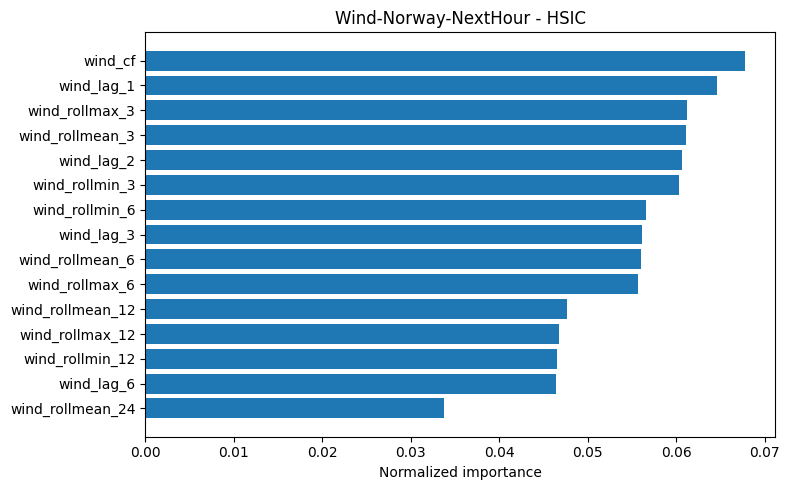

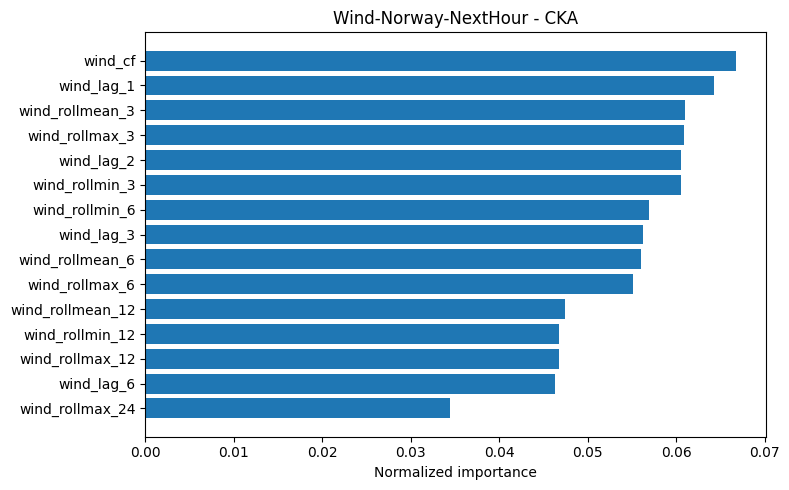

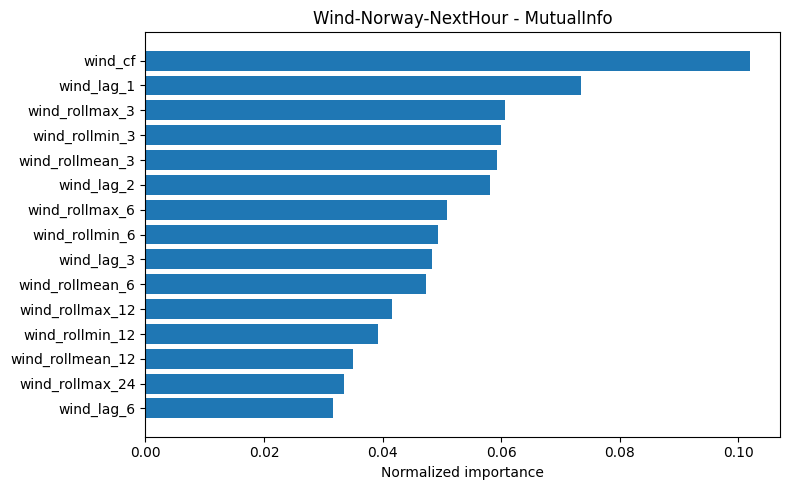

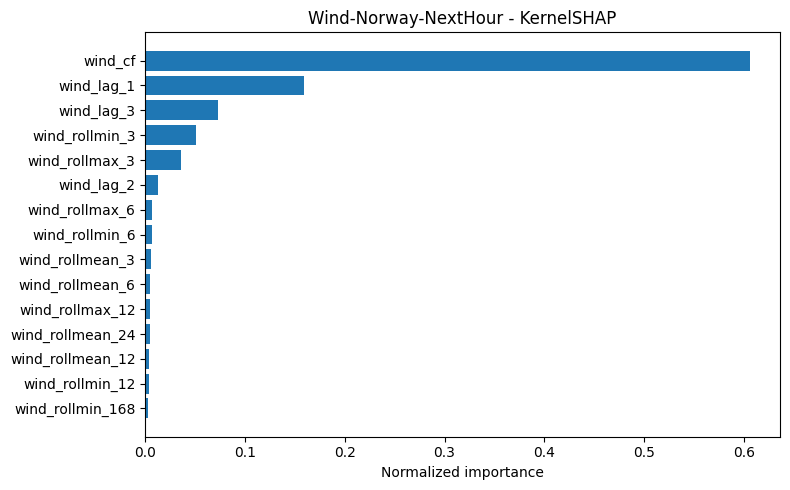

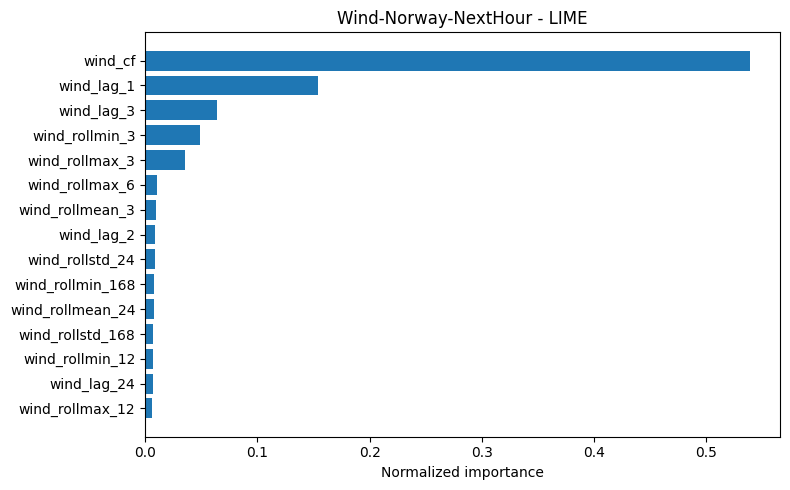

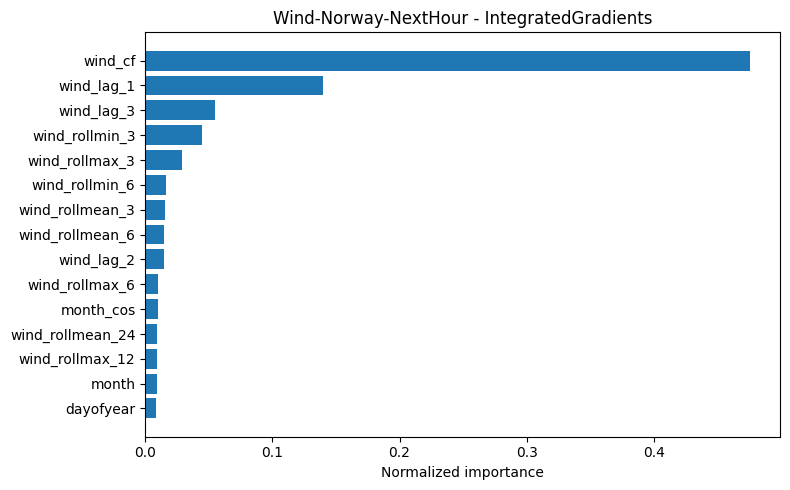

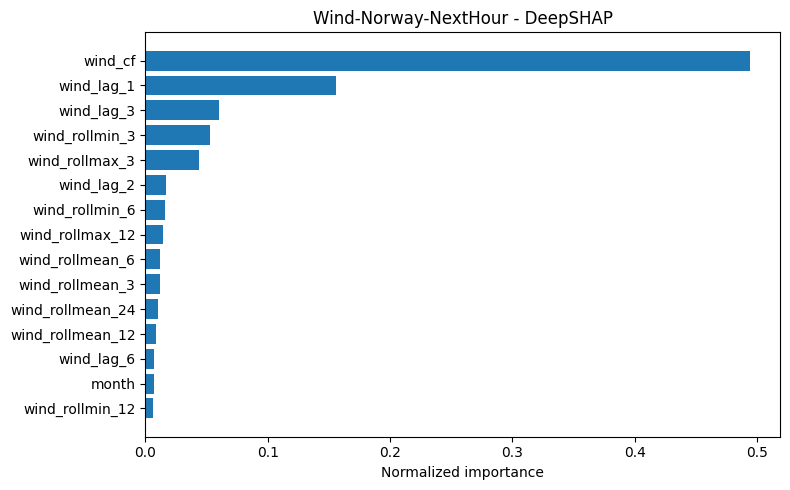

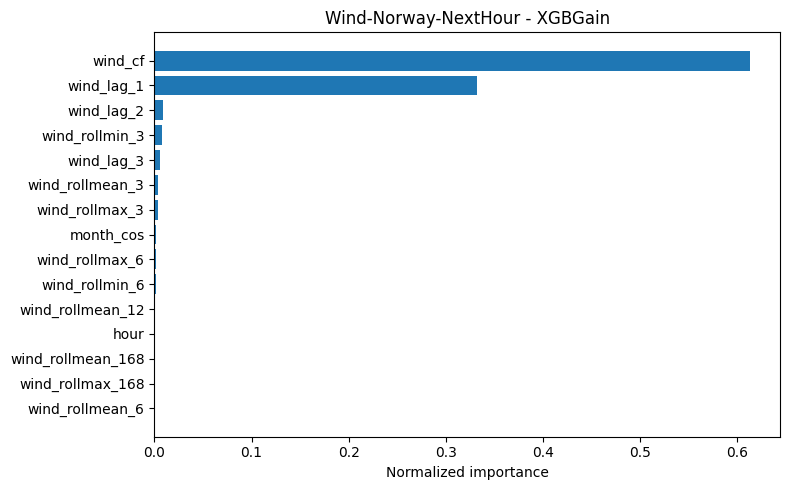

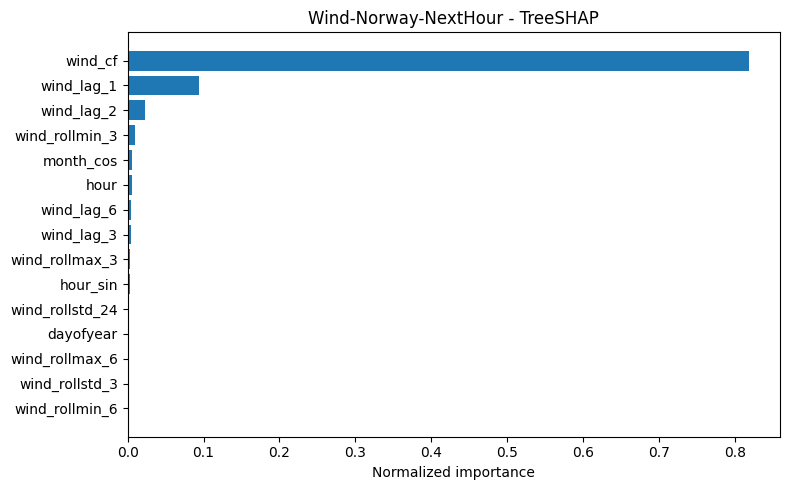

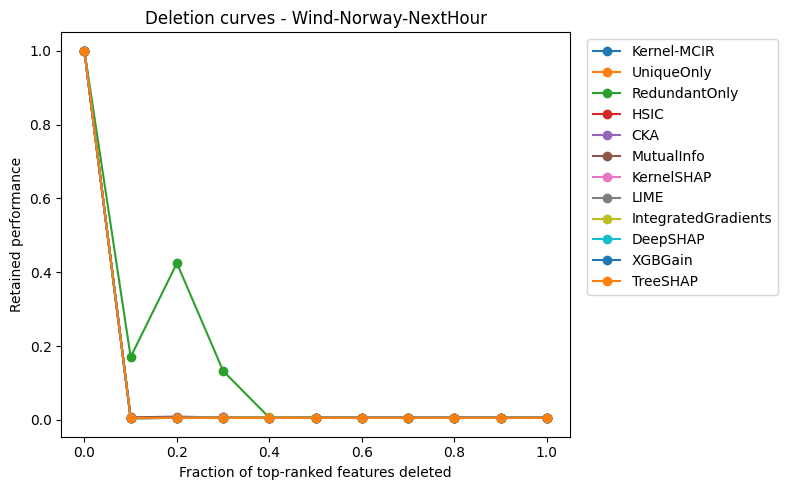


DATASET: UCI-AirQuality-NextHour-CO
Training MLP...
Training XGBoost...

MLP predictive performance
Validation: {'RMSE': 0.7470826950813876, 'MAE': 0.5159116862464971, 'R2': 0.6454668607285297}
Test      : {'RMSE': 0.600178610011804, 'MAE': 0.4284902446722799, 'R2': 0.8043600704212692}

XGBoost predictive performance
Validation: {'RMSE': 0.7712658056841096, 'MAE': 0.5128818923513249, 'R2': 0.6221428565966396}
Test      : {'RMSE': 0.5947083371572439, 'MAE': 0.4090180687259796, 'R2': 0.8079101024988388}
Running: Kernel-MCIR
Running: UniqueOnly
Running: RedundantOnly
Running: HSIC
Running: CKA
Running: MutualInfo
Running: Permutation
Failed: Permutation -> The 'estimator' parameter of permutation_importance must be an object implementing 'fit'. Got <__main__.get_permutation_importance.<locals>.Wrapper object at 0x780b560ea6c0> instead.
Running: KernelSHAP


  0%|          | 0/48 [00:00<?, ?it/s]

  0%|          | 0/48 [00:00<?, ?it/s]

  0%|          | 0/48 [00:00<?, ?it/s]

  0%|          | 0/48 [00:00<?, ?it/s]

...

Running: LIME
Running: IntegratedGradients
Running: DeepSHAP
Running: XGBGain
Running: TreeSHAP

Explainer summary
                 method model_type  stability_spearman  stability_kendall  \
0              DeepSHAP        mlp            0.958330           0.842051   
1            KernelSHAP        mlp            0.935660           0.833883   
2                  LIME        mlp            0.999662           0.995385   
3           Kernel-MCIR        mlp            0.824058           0.680936   
4                  HSIC        mlp            0.874053           0.713333   
5               XGBGain        xgb            1.000000           1.000000   
6              TreeSHAP        xgb            0.992176           0.947692   
7            UniqueOnly        mlp            0.864165           0.698565   
8                   CKA        mlp            0.864165           0.698565   
9   IntegratedGradients        mlp            0.963977           0.854872   
10           MutualInfo        mlp    

  0%|          | 0/48 [00:00<?, ?it/s]

  0%|          | 0/48 [00:00<?, ?it/s]

  0%|          | 0/48 [00:00<?, ?it/s]


Noise robustness summary
                method  spearman_clean_gaussian  spearman_clean_adversarial
0          Kernel-MCIR                 0.806942                    0.729268
1                 HSIC                 0.971482                    0.902814
2                  CKA                 0.966604                    0.901689
3           KernelSHAP                 0.972998                    0.970957
4  IntegratedGradients                 0.976923                    0.958724
5                 LIME                 1.000000                    0.999625
6             DeepSHAP                 0.978612                    0.964353


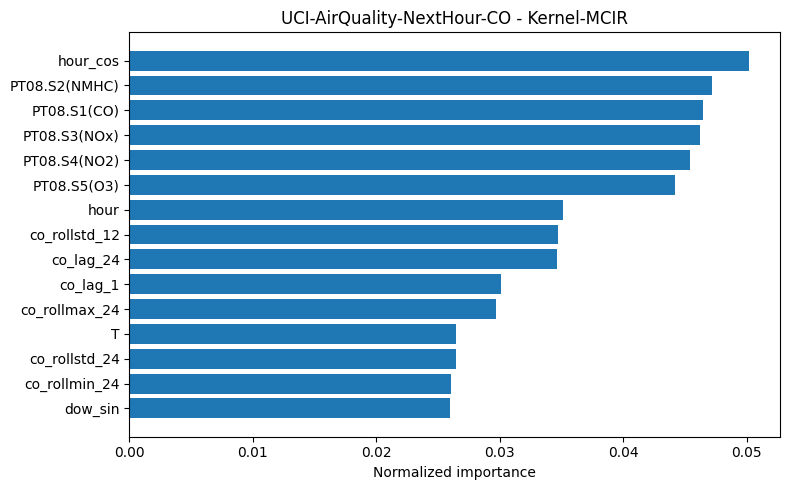

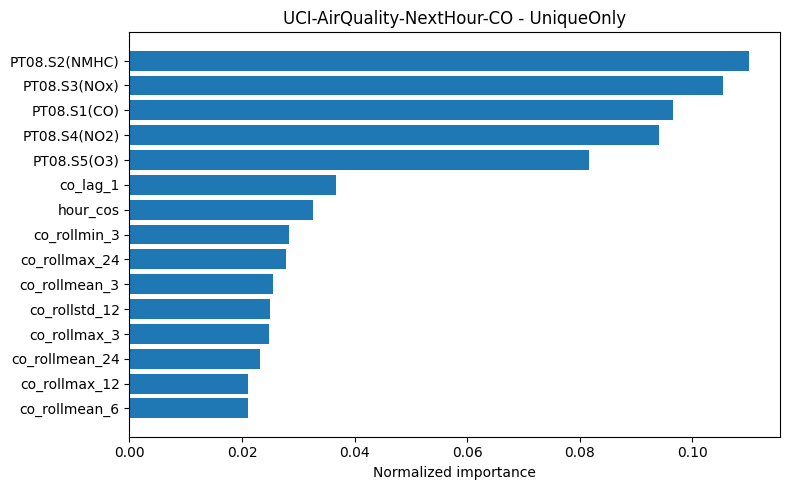

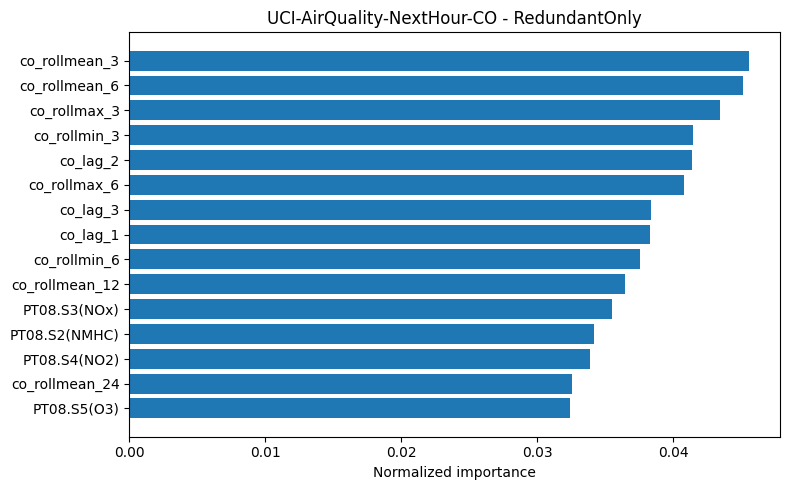

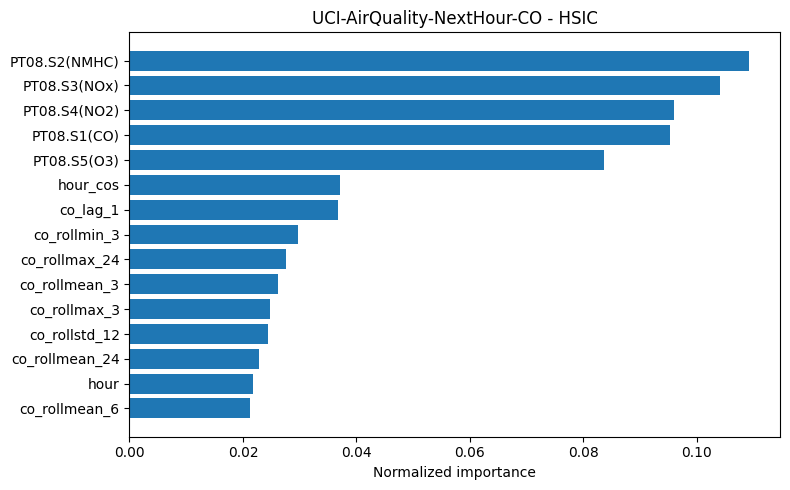

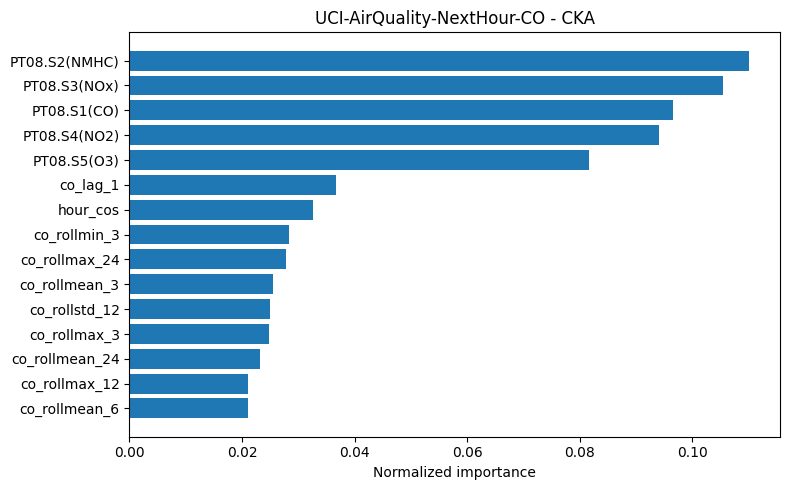

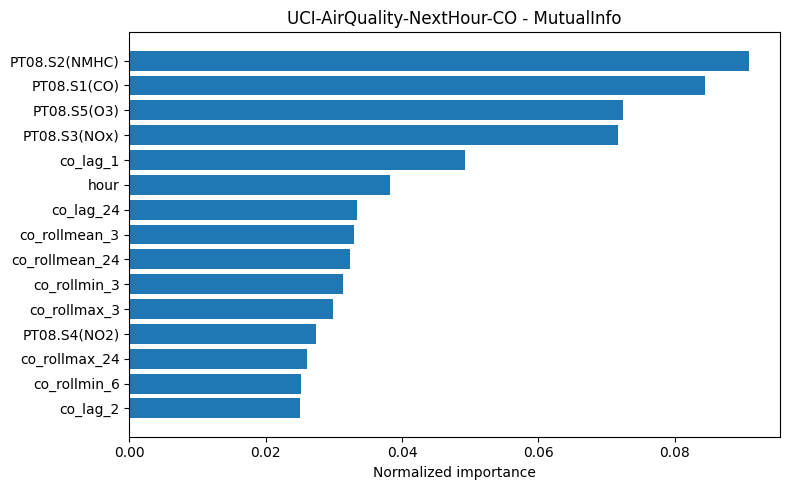

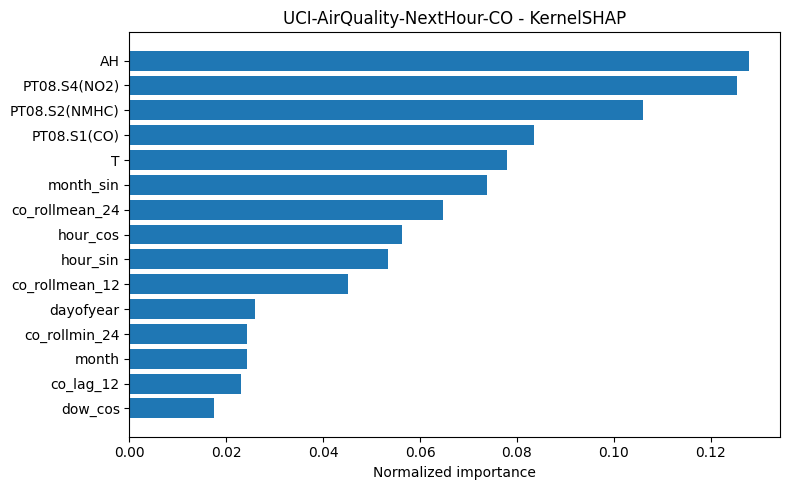

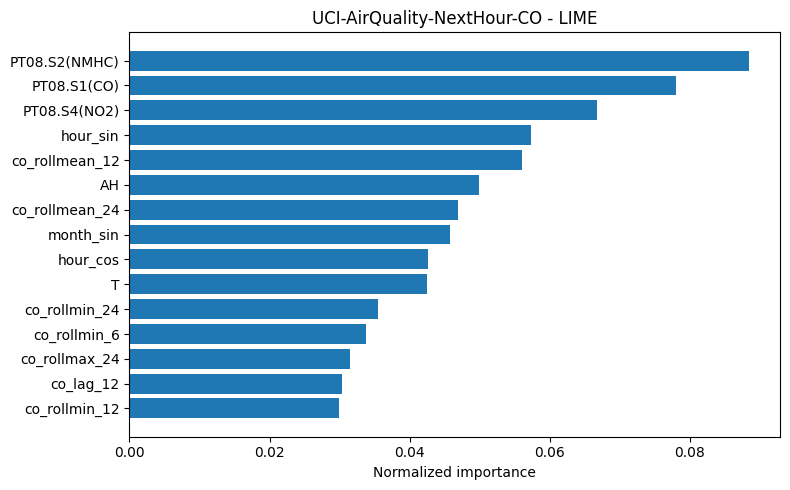

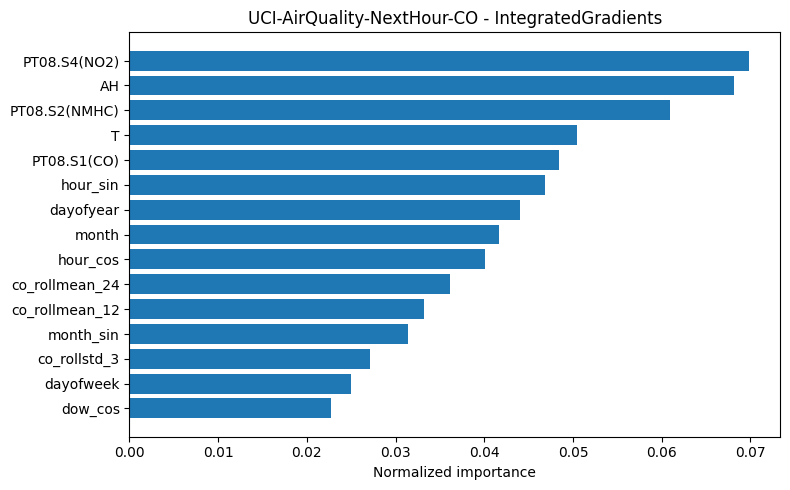

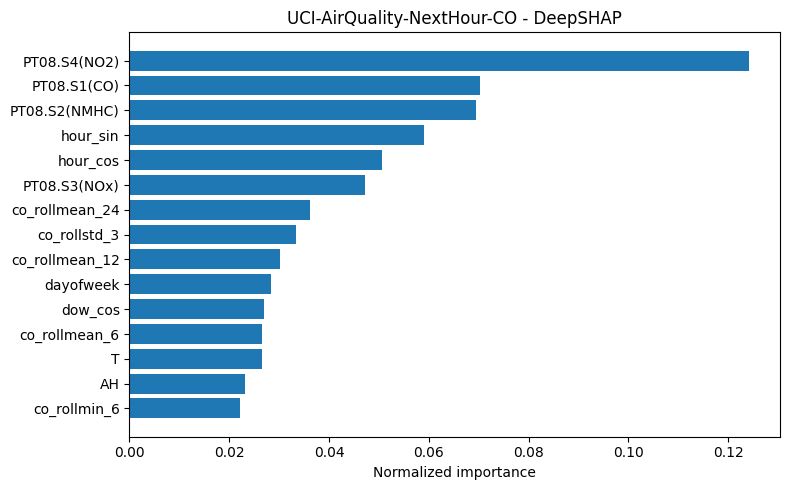

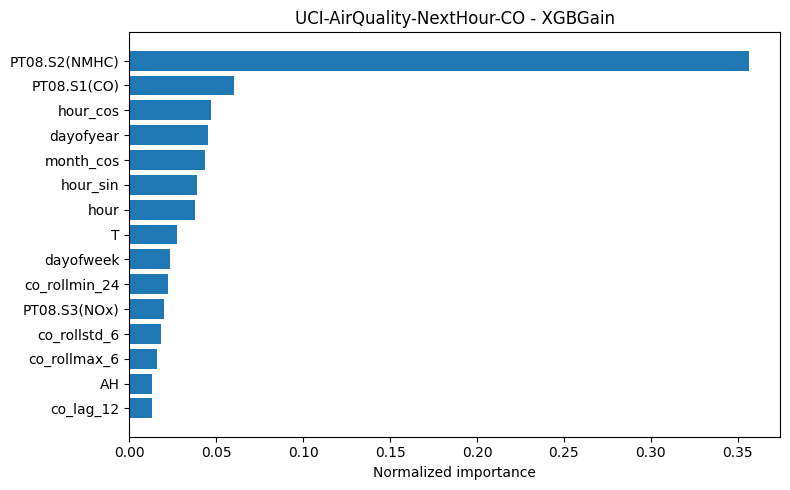

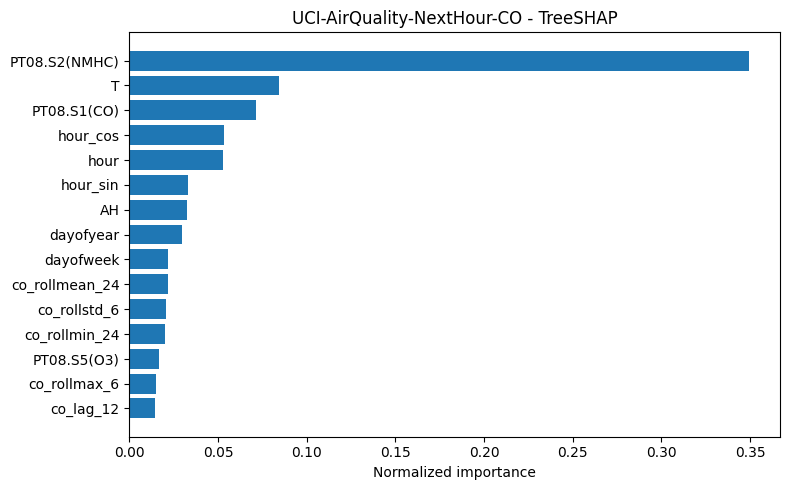

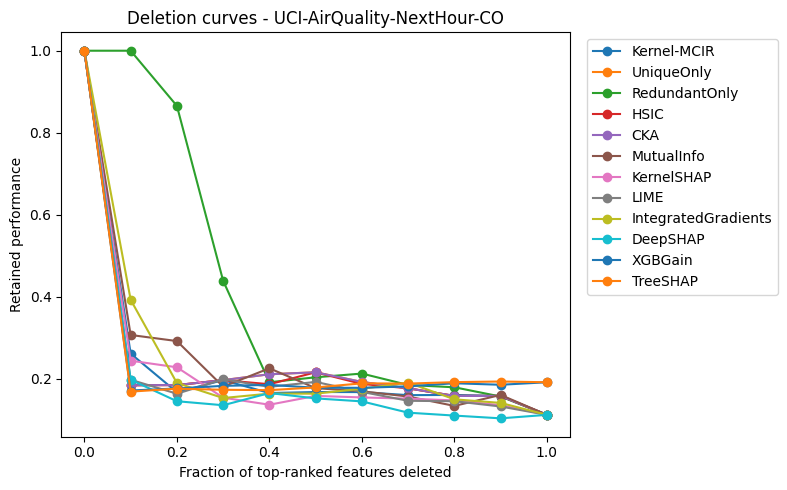


DATASET: Synthetic-Redundancy
Training MLP...
Training XGBoost...

MLP predictive performance
Validation: {'RMSE': 0.12091502531905896, 'MAE': 0.09692741617767195, 'R2': 0.9930238980756254}
Test      : {'RMSE': 0.12759700257545575, 'MAE': 0.09983375399517358, 'R2': 0.9922645956091789}

XGBoost predictive performance
Validation: {'RMSE': 0.12460534311569008, 'MAE': 0.09950993376835023, 'R2': 0.9925915798252799}
Test      : {'RMSE': 0.13171478917380017, 'MAE': 0.10380557690133396, 'R2': 0.9917572683712886}
Running: Kernel-MCIR
Running: UniqueOnly
Running: RedundantOnly
Running: HSIC
Running: CKA
Running: MutualInfo
Running: Permutation
Failed: Permutation -> The 'estimator' parameter of permutation_importance must be an object implementing 'fit'. Got <__main__.get_permutation_importance.<locals>.Wrapper object at 0x780b56c663f0> instead.
Running: KernelSHAP


  0%|          | 0/48 [00:00<?, ?it/s]

  0%|          | 0/48 [00:00<?, ?it/s]

  0%|          | 0/48 [00:00<?, ?it/s]

  0%|          | 0/48 [00:00<?, ?it/s]

...

Running: LIME
Running: IntegratedGradients
Running: DeepSHAP
Running: XGBGain
Running: TreeSHAP

Explainer summary
                 method model_type  stability_spearman  stability_kendall  \
0   IntegratedGradients        mlp                1.00               1.00   
1              DeepSHAP        mlp                0.96               0.92   
2           Kernel-MCIR        mlp                0.62               0.56   
3            KernelSHAP        mlp                0.96               0.92   
4            MutualInfo        mlp                1.00               1.00   
5                  LIME        mlp                1.00               1.00   
6              TreeSHAP        xgb                0.84               0.76   
7            UniqueOnly        mlp                0.85               0.72   
8                  HSIC        mlp                0.85               0.72   
9                   CKA        mlp                0.85               0.72   
10              XGBGain        xgb    

  0%|          | 0/48 [00:00<?, ?it/s]

  0%|          | 0/48 [00:00<?, ?it/s]

  0%|          | 0/48 [00:00<?, ?it/s]


Noise robustness summary
                method  spearman_clean_gaussian  spearman_clean_adversarial
0          Kernel-MCIR                      1.0                         0.9
1                 HSIC                      0.9                         1.0
2                  CKA                      1.0                         0.9
3           KernelSHAP                      1.0                         1.0
4  IntegratedGradients                      1.0                         1.0
5                 LIME                      1.0                         1.0
6             DeepSHAP                      1.0                         1.0


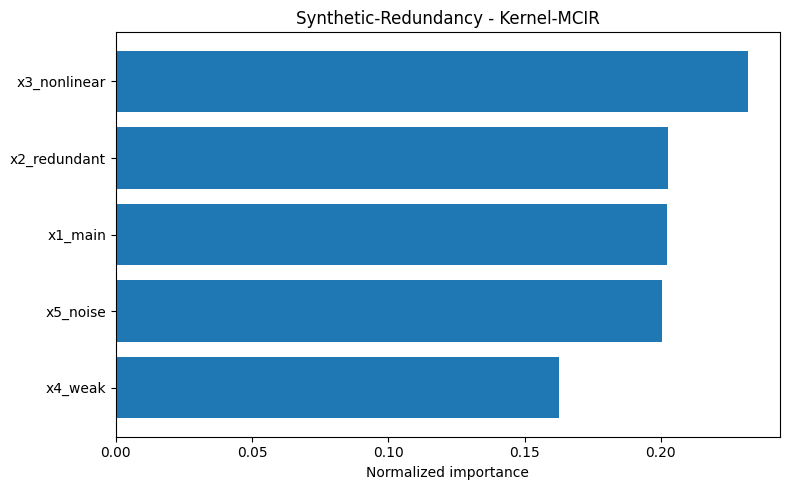

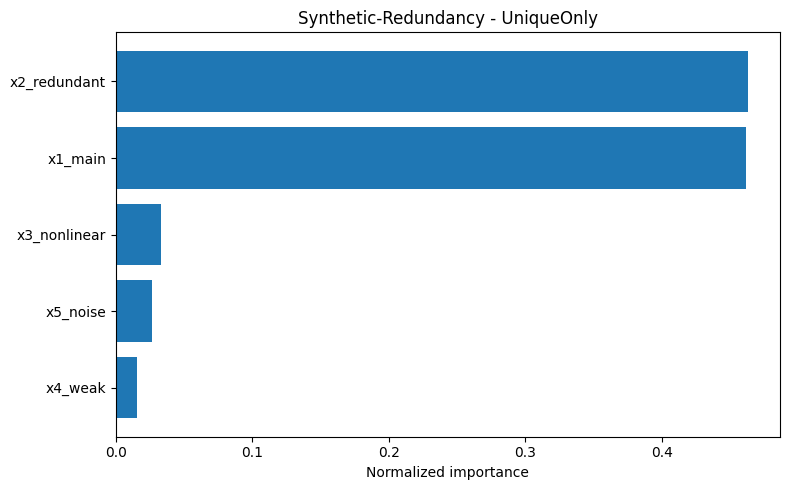

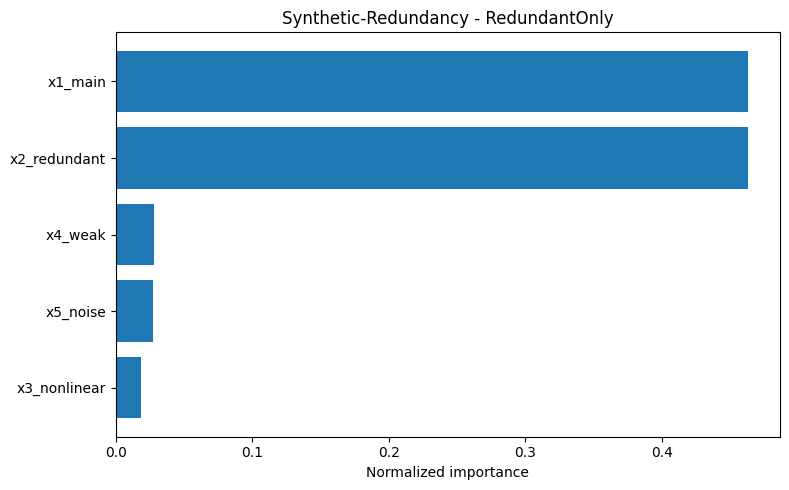

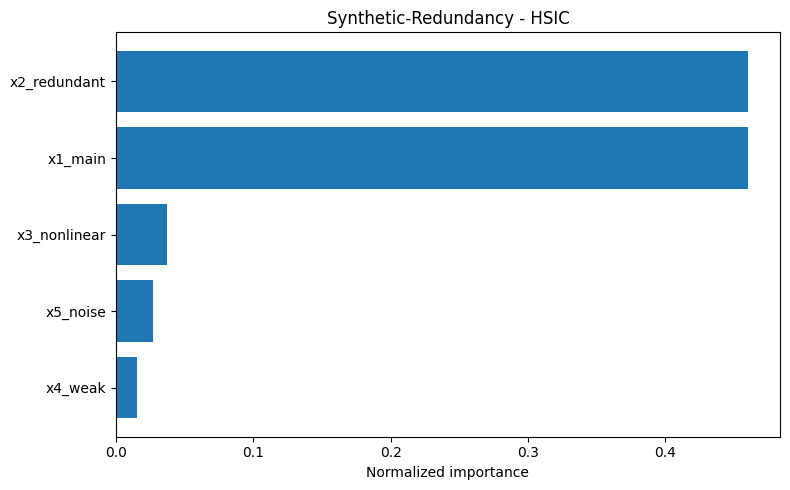

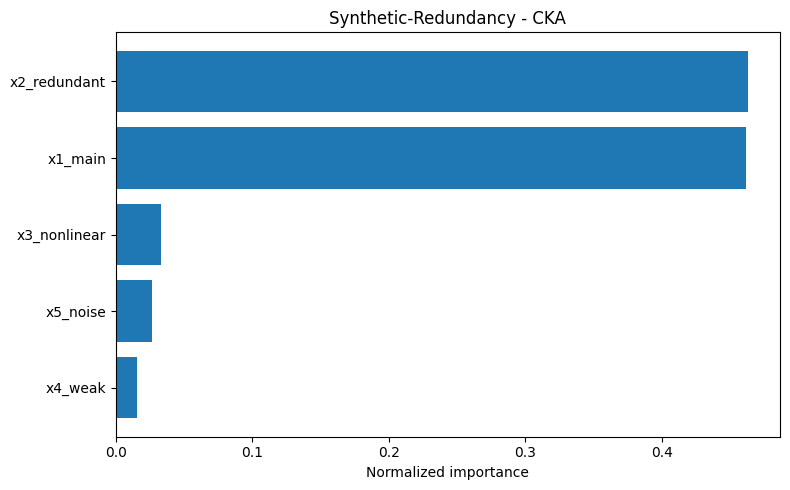

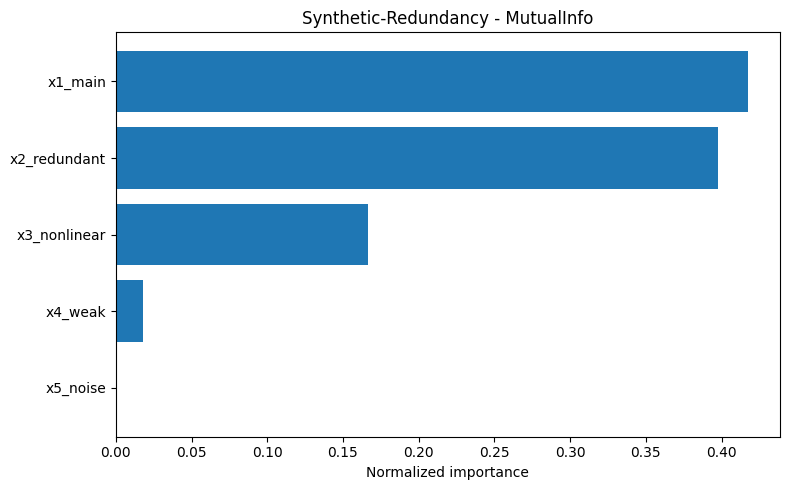

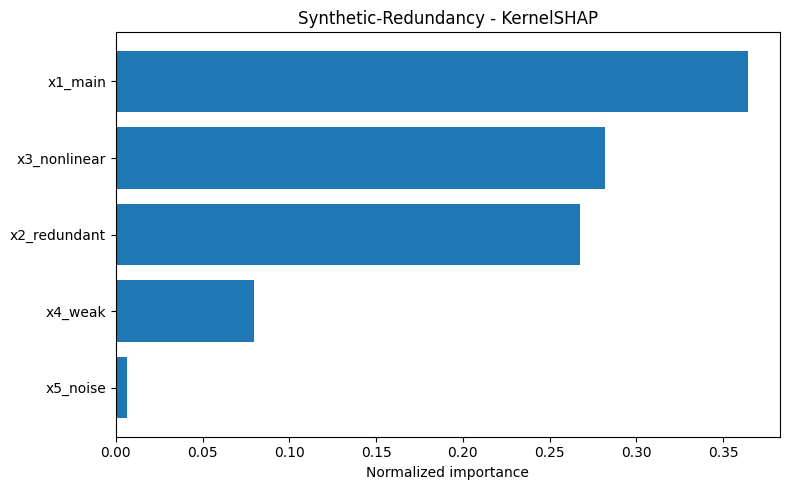

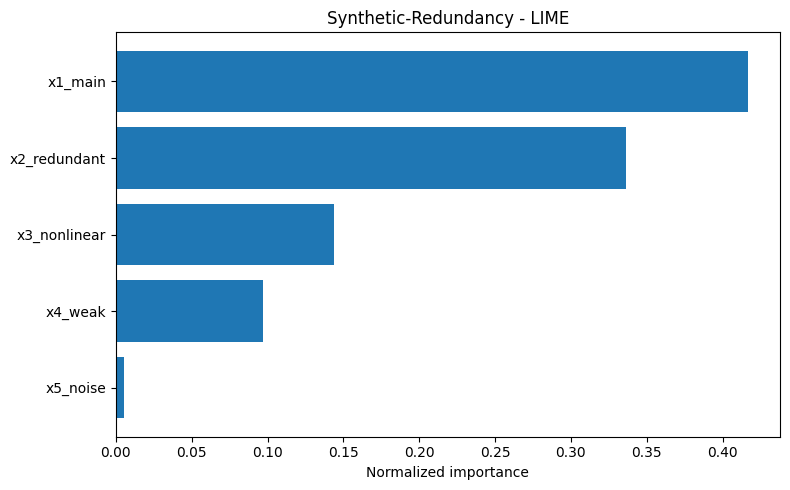

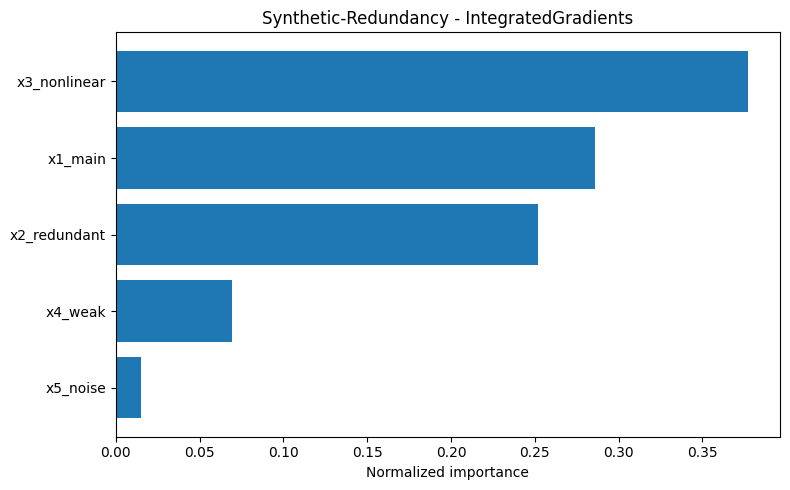

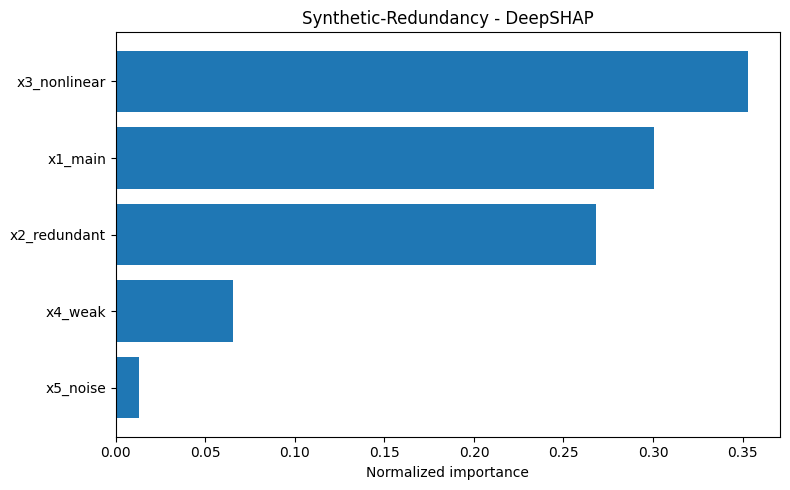

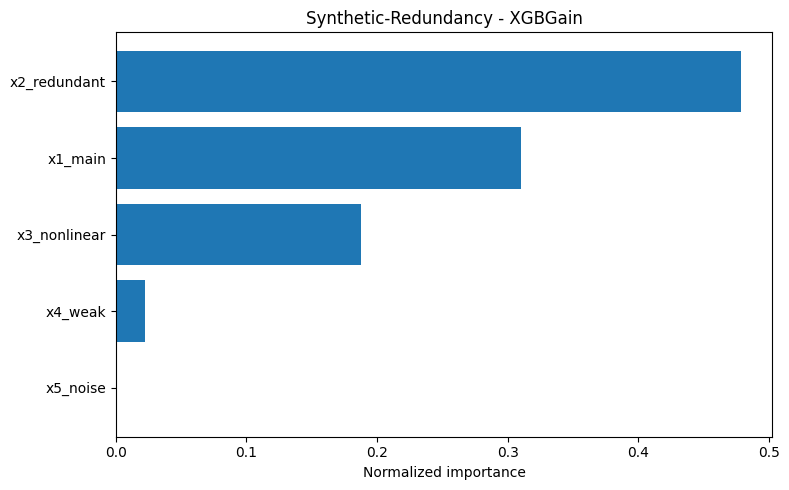

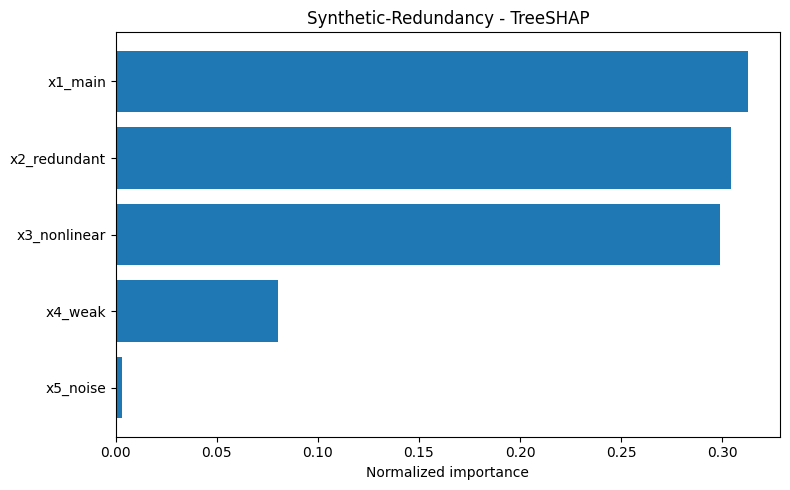

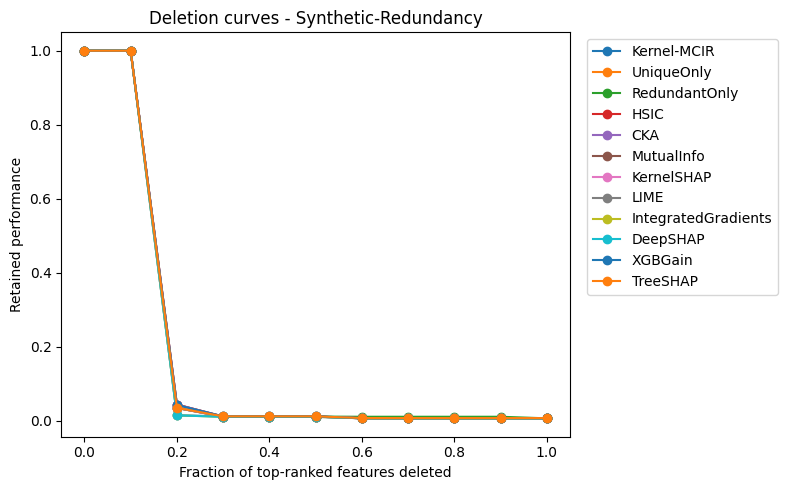


FINAL COMBINED SUMMARY
                       dataset               method model_type  \
0         Wind-Norway-NextHour              XGBGain        xgb   
1         Wind-Norway-NextHour             TreeSHAP        xgb   
2         Wind-Norway-NextHour             DeepSHAP        mlp   
3         Wind-Norway-NextHour                 LIME        mlp   
4         Wind-Norway-NextHour  IntegratedGradients        mlp   
5         Wind-Norway-NextHour           UniqueOnly        mlp   
6         Wind-Norway-NextHour                  CKA        mlp   
7         Wind-Norway-NextHour                 HSIC        mlp   
8         Wind-Norway-NextHour           KernelSHAP        mlp   
9         Wind-Norway-NextHour          Kernel-MCIR        mlp   
10        Wind-Norway-NextHour           MutualInfo        mlp   
11        Wind-Norway-NextHour        RedundantOnly        mlp   
12  UCI-AirQuality-NextHour-CO             DeepSHAP        mlp   
13  UCI-AirQuality-NextHour-CO           KernelSHAP 

In [ ]:
# ============================================================
# FULL GOOGLE COLAB SCRIPT
# Kernel-MCIR + modern XAI baseline comparison
#
# Datasets:
#   1) Wind (OPSD / Renewables.ninja Norway)
#   2) UCI Air Quality
#   3) Synthetic controlled ground-truth
#
# Models:
#   - Tabular MLP regressor (main unified explainer target)
#   - XGBoost regressor (for TreeSHAP / Gain supplement)
#
# Methods compared:
#   - Kernel-MCIR
#   - UniqueOnly
#   - RedundantOnly
#   - HSIC
#   - CKA
#   - MutualInfo
#   - Permutation
#   - KernelSHAP
#   - LIME
#   - IntegratedGradients
#   - DeepSHAP
#   - XGB Gain
#   - TreeSHAP
#
# Evaluation:
#   - Predictive performance
#   - Deletion AUC
#   - Runtime
#   - Stability across seeds
#   - Noise robustness
#   - Kernel sensitivity
# ============================================================

# =========================
# 0. INSTALLS
# =========================
!pip -q install shap lime xgboost tqdm openpyxl tensorflow

# =========================
# 1. IMPORTS
# =========================
import os
import io
import gc
import time
import math
import random
import zipfile
import urllib.request
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, kendalltau
from scipy.spatial.distance import pdist, squareform

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import mutual_info_regression

from xgboost import XGBRegressor
import shap
from lime.lime_tabular import LimeTabularExplainer

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# =========================
# 2. REPRODUCIBILITY
# =========================
SEED = 42

def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)

set_seed(SEED)

# =========================
# 3. SETTINGS
# =========================
N_STABILITY_RUNS = 5
EXPLAIN_SAMPLE = 192
KERNEL_SHAP_BG = 48
KERNEL_SHAP_EVAL = 48
DEEPSHAP_BG = 64
LIME_EVAL = 40
IG_EVAL = 96
IG_STEPS = 32
PERM_REPEATS = 10
DELETION_STEPS = 11
TOPK_PLOT = 15
NOISE_STD = 0.20

WIND_URL = "https://data.open-power-system-data.org/ninja_pv_wind_profiles/2020-09-16/ninja_pv_wind_profiles_singleindex.csv"
AIR_QUALITY_ZIP_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip"

# =========================
# 4. UTILITIES
# =========================
def rmse(y_true, y_pred):
    return math.sqrt(mean_squared_error(y_true, y_pred))

def regression_metrics(y_true, y_pred):
    return {
        "RMSE": rmse(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

def clean_numeric_series(s):
    if pd.api.types.is_numeric_dtype(s):
        return pd.to_numeric(s, errors="coerce")
    return pd.to_numeric(
        s.astype(str).str.replace(",", ".", regex=False).str.strip(),
        errors="coerce"
    )

def chronological_split(df, train_frac=0.7, val_frac=0.15):
    n = len(df)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)
    train_df = df.iloc[:n_train].copy()
    val_df = df.iloc[n_train:n_train+n_val].copy()
    test_df = df.iloc[n_train+n_val:].copy()
    return train_df, val_df, test_df

def add_calendar_features(df, time_col):
    df["hour"] = df[time_col].dt.hour
    df["dayofweek"] = df[time_col].dt.dayofweek
    df["dayofyear"] = df[time_col].dt.dayofyear
    df["month"] = df[time_col].dt.month

    df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
    df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)
    df["dow_sin"] = np.sin(2*np.pi*df["dayofweek"]/7)
    df["dow_cos"] = np.cos(2*np.pi*df["dayofweek"]/7)
    df["month_sin"] = np.sin(2*np.pi*df["month"]/12)
    df["month_cos"] = np.cos(2*np.pi*df["month"]/12)
    return df

def make_lag_features(df, target_col, lags, prefix):
    for lag in lags:
        df[f"{prefix}_lag_{lag}"] = df[target_col].shift(lag)
    return df

def make_rolling_features(df, target_col, windows, prefix, shift_first=True):
    base = df[target_col].shift(1) if shift_first else df[target_col]
    for w in windows:
        df[f"{prefix}_rollmean_{w}"] = base.rolling(w).mean()
        df[f"{prefix}_rollstd_{w}"] = base.rolling(w).std()
        df[f"{prefix}_rollmin_{w}"] = base.rolling(w).min()
        df[f"{prefix}_rollmax_{w}"] = base.rolling(w).max()
    return df

def normalize_importance(scores):
    scores = np.asarray(scores, dtype=float)
    scores = np.nan_to_num(scores, nan=0.0, posinf=0.0, neginf=0.0)
    scores = np.abs(scores)
    s = scores.sum()
    if s <= 0:
        return np.ones_like(scores) / len(scores)
    return scores / s

def sample_rows(X, y=None, n=128, seed=42):
    n = min(n, len(X))
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), size=n, replace=False)
    if y is None:
        return X[idx], idx
    return X[idx], y[idx], idx

def pairwise_mean_spearman(vectors):
    vals = []
    for i in range(len(vectors)):
        for j in range(i+1, len(vectors)):
            rho = spearmanr(vectors[i], vectors[j]).correlation
            if np.isnan(rho):
                rho = 0.0
            vals.append(rho)
    return float(np.mean(vals)) if vals else np.nan

def mean_kendall_tau(vectors):
    vals = []
    for i in range(len(vectors)):
        for j in range(i+1, len(vectors)):
            tau = kendalltau(vectors[i], vectors[j]).correlation
            if np.isnan(tau):
                tau = 0.0
            vals.append(tau)
    return float(np.mean(vals)) if vals else np.nan

def auc_trapz(y, x):
    return np.trapz(y, x)

# =========================
# 5. DATA LOADERS
# =========================
def load_wind_dataset():
    print("Loading wind dataset...")
    usecols = ["time", "NO_wind_national_current"]
    df = pd.read_csv(WIND_URL, usecols=usecols, parse_dates=["time"])
    df = df.rename(columns={"NO_wind_national_current": "wind_cf"})
    df = df.sort_values("time").dropna().reset_index(drop=True)

    if len(df) > 50000:
        df = df.iloc[-50000:].reset_index(drop=True)

    df = add_calendar_features(df, "time")
    df = make_lag_features(df, "wind_cf", [1,2,3,6,12,24,48,72,168], "wind")
    df = make_rolling_features(df, "wind_cf", [3,6,12,24,168], "wind")

    df["target"] = df["wind_cf"].shift(-1)
    df = df.dropna().reset_index(drop=True)

    feature_cols = [c for c in df.columns if c not in ["time", "target"]]
    train_df, val_df, test_df = chronological_split(df)

    return {
        "name": "Wind-Norway-NextHour",
        "feature_cols": feature_cols,
        "train_df": train_df,
        "val_df": val_df,
        "test_df": test_df
    }

def load_air_quality_dataset():
    print("Loading UCI Air Quality...")
    response = urllib.request.urlopen(AIR_QUALITY_ZIP_URL)
    zip_bytes = io.BytesIO(response.read())

    with zipfile.ZipFile(zip_bytes) as zf:
        csv_name = None
        for name in zf.namelist():
            if "AirQualityUCI.csv" in name:
                csv_name = name
                break
        if csv_name is None:
            raise FileNotFoundError("AirQualityUCI.csv not found inside ZIP.")

        with zf.open(csv_name) as f:
            df = pd.read_csv(f, sep=";", decimal=",", encoding="latin1")

    df = df.dropna(axis=1, how="all")
    df.columns = [str(c).strip() for c in df.columns]
    df = df.loc[:, ~df.columns.str.contains("^Unnamed", case=False, na=False)]

    for c in df.columns:
        if c not in ["Date", "Time"]:
            df[c] = clean_numeric_series(df[c])
            df[c] = df[c].replace(-200, np.nan)

    df["datetime"] = pd.to_datetime(
        df["Date"].astype(str) + " " + df["Time"].astype(str).str.replace(".", ":", regex=False),
        dayfirst=True,
        errors="coerce"
    )
    df = df.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)

    target_col = "CO(GT)"
    if target_col not in df.columns:
        candidates = [c for c in df.columns if "CO" in c and "GT" in c]
        if len(candidates) == 0:
            raise ValueError("Could not find CO(GT) column.")
        target_col = candidates[0]

    df = add_calendar_features(df, "datetime")
    df = make_lag_features(df, target_col, [1,2,3,6,12,24], "co")
    df = make_rolling_features(df, target_col, [3,6,12,24], "co")

    df["target"] = df[target_col].shift(-1)

    sensor_cols = [c for c in df.columns if "PT08" in c.upper()]
    weather_cols = [c for c in df.columns if c in ["T", "RH", "AH"]]

    feature_cols = []
    feature_cols += sensor_cols
    feature_cols += weather_cols
    feature_cols += [c for c in df.columns if c.startswith("co_lag_") or c.startswith("co_roll")]
    feature_cols += [
        "hour", "dayofweek", "dayofyear", "month",
        "hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos"
    ]
    feature_cols = list(dict.fromkeys([c for c in feature_cols if c in df.columns]))

    df = df[["datetime"] + feature_cols + ["target"]].dropna().reset_index(drop=True)
    train_df, val_df, test_df = chronological_split(df)

    return {
        "name": "UCI-AirQuality-NextHour-CO",
        "feature_cols": feature_cols,
        "train_df": train_df,
        "val_df": val_df,
        "test_df": test_df
    }

def load_synthetic_dataset():
    print("Loading synthetic dataset...")
    rng = np.random.default_rng(SEED)
    n = 5000

    x1 = rng.normal(size=n)
    x2 = x1 + 0.08 * rng.normal(size=n)
    x3 = rng.uniform(-2, 2, size=n)
    x4 = rng.normal(size=n)
    x5 = rng.normal(size=n)

    y = np.sin(1.5*x1) + 0.8*np.sin(1.2*x2) + 0.6*(x3**2) + 0.2*x4 + 0.1*rng.normal(size=n)

    df = pd.DataFrame({
        "x1_main": x1,
        "x2_redundant": x2,
        "x3_nonlinear": x3,
        "x4_weak": x4,
        "x5_noise": x5,
        "target": y
    })

    train_df, val_df, test_df = chronological_split(df)
    feature_cols = [c for c in df.columns if c != "target"]

    return {
        "name": "Synthetic-Redundancy",
        "feature_cols": feature_cols,
        "train_df": train_df,
        "val_df": val_df,
        "test_df": test_df
    }

# =========================
# 6. PREP
# =========================
def prepare_xy(dataset):
    feature_cols = dataset["feature_cols"]
    train_df = dataset["train_df"]
    val_df = dataset["val_df"]
    test_df = dataset["test_df"]

    X_train = train_df[feature_cols].copy()
    y_train = train_df["target"].values.astype(float)

    X_val = val_df[feature_cols].copy()
    y_val = val_df["target"].values.astype(float)

    X_test = test_df[feature_cols].copy()
    y_test = test_df["target"].values.astype(float)

    prep = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    X_train_p = prep.fit_transform(X_train).astype(np.float32)
    X_val_p = prep.transform(X_val).astype(np.float32)
    X_test_p = prep.transform(X_test).astype(np.float32)

    return feature_cols, prep, X_train_p, y_train, X_val_p, y_val, X_test_p, y_test

# =========================
# 7. MODELS
# =========================
def train_xgb_regressor(X_train, y_train, X_val, y_val, seed=42):
    model = XGBRegressor(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=seed,
        tree_method="hist",
        eval_metric="rmse"
    )
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    return model

def build_mlp(input_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="linear")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse"
    )
    return model

def train_mlp_regressor(X_train, y_train, X_val, y_val, seed=42):
    set_seed(seed)
    model = build_mlp(X_train.shape[1])

    es = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=80,
        batch_size=128,
        verbose=0,
        callbacks=[es]
    )
    return model

def mlp_predict(model, X):
    return model.predict(X, verbose=0).reshape(-1)

# =========================
# 8. KERNEL TOOLS
# =========================
def center_kernel(K):
    n = K.shape[0]
    H = np.eye(n) - np.ones((n, n))/n
    return H @ K @ H

def linear_kernel_1d(x):
    x = x.reshape(-1, 1)
    return x @ x.T

def poly_kernel_1d(x, degree=2, coef0=1.0):
    x = x.reshape(-1, 1)
    return (x @ x.T + coef0)**degree

def rbf_kernel_1d(x, gamma=None):
    x = x.reshape(-1, 1)
    D = squareform(pdist(x, metric="sqeuclidean"))
    if gamma is None:
        nz = D[D > 0]
        med = np.median(nz) if len(nz) > 0 else 1.0
        gamma = 1.0 / (2.0 * med + 1e-12)
    return np.exp(-gamma * D)

def build_feature_kernel(x, kernel="rbf"):
    if kernel == "linear":
        return linear_kernel_1d(x)
    elif kernel == "poly":
        return poly_kernel_1d(x)
    else:
        return rbf_kernel_1d(x)

def build_output_kernel(y, kernel="rbf"):
    if kernel == "linear":
        return linear_kernel_1d(y)
    elif kernel == "poly":
        return poly_kernel_1d(y)
    else:
        return rbf_kernel_1d(y)

def hsic_raw(K1, K2):
    n = K1.shape[0]
    H = np.eye(n) - np.ones((n, n))/n
    return np.trace(K1 @ H @ K2 @ H) / ((n - 1)**2 + 1e-12)

def cka_alignment(K1, K2):
    K1c = center_kernel(K1)
    K2c = center_kernel(K2)
    num = np.sum(K1c * K2c)
    den = np.sqrt(np.sum(K1c*K1c) * np.sum(K2c*K2c)) + 1e-12
    return float(num / den)

# =========================
# 9. KERNEL-MCIR / HSIC / CKA
# =========================
def kernel_mcir_decompose(X, y_signal, kernel="rbf"):
    n, p = X.shape
    Ky = build_output_kernel(y_signal, kernel=kernel)
    K_features = [build_feature_kernel(X[:, j], kernel=kernel) for j in range(p)]

    relevance = np.array([max(cka_alignment(Kj, Ky), 0.0) for Kj in K_features])

    redundancy = np.zeros(p)
    for j in range(p):
        vals = []
        for k in range(p):
            if j == k:
                continue
            vals.append(abs(cka_alignment(K_features[j], K_features[k])))
        redundancy[j] = np.mean(vals) if len(vals) else 0.0

    mcir = relevance / (relevance + redundancy + 1e-12)
    mcir = np.clip(mcir, 0.0, 1.0)

    return {
        "mcir_raw": mcir,
        "mcir_norm": normalize_importance(mcir),
        "unique_raw": relevance,
        "unique_norm": normalize_importance(relevance),
        "redundant_raw": redundancy,
        "redundant_norm": normalize_importance(redundancy),
    }

def hsic_feature_scores(X, y_signal, kernel="rbf"):
    Ky = build_output_kernel(y_signal, kernel=kernel)
    vals = []
    for j in range(X.shape[1]):
        Kj = build_feature_kernel(X[:, j], kernel=kernel)
        vals.append(max(hsic_raw(Kj, Ky), 0.0))
    return normalize_importance(np.array(vals))

def cka_feature_scores(X, y_signal, kernel="rbf"):
    Ky = build_output_kernel(y_signal, kernel=kernel)
    vals = []
    for j in range(X.shape[1]):
        Kj = build_feature_kernel(X[:, j], kernel=kernel)
        vals.append(max(cka_alignment(Kj, Ky), 0.0))
    return normalize_importance(np.array(vals))

# =========================
# 10. CLASSICAL METHODS
# =========================
def get_mutual_info_importance(X_train, y_train):
    imp = mutual_info_regression(X_train, y_train, random_state=SEED)
    return normalize_importance(imp)

def get_permutation_importance(model, X_val, y_val, model_type="mlp"):
    if model_type == "mlp":
        scorer_model = lambda X: mlp_predict(model, X)
        class Wrapper:
            def predict(self, X):
                return scorer_model(X)
        r = permutation_importance(
            Wrapper(), X_val, y_val,
            n_repeats=PERM_REPEATS,
            random_state=SEED,
            scoring="neg_root_mean_squared_error"
        )
    else:
        r = permutation_importance(
            model, X_val, y_val,
            n_repeats=PERM_REPEATS,
            random_state=SEED,
            scoring="neg_root_mean_squared_error"
        )
    return normalize_importance(r.importances_mean)

def get_xgb_gain_importance(model, p):
    imp = model.feature_importances_
    if len(imp) != p:
        out = np.zeros(p)
        out[:len(imp)] = imp
        imp = out
    return normalize_importance(imp)

# =========================
# 11. SHAP
# =========================
def get_kernel_shap_importance_mlp(model, X_bg, X_eval):
    bg = shap.sample(X_bg, min(KERNEL_SHAP_BG, len(X_bg)), random_state=SEED)
    ev = shap.sample(X_eval, min(KERNEL_SHAP_EVAL, len(X_eval)), random_state=SEED)

    f = lambda x: mlp_predict(model, x)
    explainer = shap.KernelExplainer(f, bg)
    sv = explainer.shap_values(ev, nsamples="auto")
    if isinstance(sv, list):
        sv = sv[0]
    imp = np.mean(np.abs(sv), axis=0)
    return normalize_importance(imp)

def get_deepshap_importance_mlp(model, X_bg, X_eval):
    bg = X_bg[:min(DEEPSHAP_BG, len(X_bg))]
    ev = X_eval[:min(KERNEL_SHAP_EVAL, len(X_eval))]
    explainer = shap.DeepExplainer(model, bg)
    sv = explainer.shap_values(ev)
    if isinstance(sv, list):
        sv = sv[0]
    sv = np.array(sv)
    if sv.ndim == 3:
        sv = sv[:, :, 0]
    imp = np.mean(np.abs(sv), axis=0)
    return normalize_importance(imp)

def get_tree_shap_importance_xgb(model, X_eval):
    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(X_eval)
    if isinstance(sv, list):
        sv = sv[0]
    imp = np.mean(np.abs(sv), axis=0)
    return normalize_importance(imp)

# =========================
# 12. LIME
# =========================
def get_lime_importance_mlp(model, X_train, X_eval, feature_names):
    explainer = LimeTabularExplainer(
        training_data=X_train,
        feature_names=feature_names,
        mode="regression",
        discretize_continuous=False,
        random_state=SEED
    )

    X_eval_small = X_eval[:min(LIME_EVAL, len(X_eval))]
    p = X_train.shape[1]
    scores = np.zeros(p)

    for x in X_eval_small:
        exp = explainer.explain_instance(
            data_row=x,
            predict_fn=lambda z: mlp_predict(model, z),
            num_features=p
        )
        local_map = exp.local_exp
        key = list(local_map.keys())[0]
        for feat_idx, weight in local_map[key]:
            scores[feat_idx] += abs(weight)

    scores = scores / max(len(X_eval_small), 1)
    return normalize_importance(scores)

# =========================
# 13. INTEGRATED GRADIENTS
# =========================
def integrated_gradients_single(model, x, baseline, steps=32):
    x_tf = tf.convert_to_tensor(x.reshape(1, -1), dtype=tf.float32)
    baseline_tf = tf.convert_to_tensor(baseline.reshape(1, -1), dtype=tf.float32)

    alphas = tf.linspace(0.0, 1.0, steps + 1)
    grads_list = []

    for alpha in alphas:
        x_interp = baseline_tf + alpha * (x_tf - baseline_tf)
        with tf.GradientTape() as tape:
            tape.watch(x_interp)
            pred = model(x_interp, training=False)
        grads = tape.gradient(pred, x_interp)
        grads_list.append(grads.numpy()[0])

    avg_grads = np.mean(np.array(grads_list), axis=0)
    ig = (x - baseline) * avg_grads
    return ig

def get_integrated_gradients_importance_mlp(model, X_train, X_eval, steps=32):
    baseline = np.mean(X_train, axis=0)
    X_eval_small = X_eval[:min(IG_EVAL, len(X_eval))]
    vals = []

    for x in X_eval_small:
        ig = integrated_gradients_single(model, x, baseline, steps=steps)
        vals.append(np.abs(ig))

    vals = np.array(vals)
    imp = np.mean(vals, axis=0)
    return normalize_importance(imp)

# =========================
# 14. DELETION AUC
# =========================
def masked_copy(X, feature_indices, baseline):
    Xm = X.copy()
    Xm[:, feature_indices] = baseline[feature_indices]
    return Xm

def deletion_auc_regression(model, X_test, y_test, importance, baseline, model_type="mlp"):
    ranking = np.argsort(-importance)
    fractions = np.linspace(0, 1, DELETION_STEPS)

    if model_type == "mlp":
        base_pred = mlp_predict(model, X_test)
    else:
        base_pred = model.predict(X_test)

    base_loss = mean_squared_error(y_test, base_pred) + 1e-12

    retained_scores = []
    p = X_test.shape[1]

    for frac in fractions:
        k = int(round(frac * p))
        idx = ranking[:k]
        X_mask = masked_copy(X_test, idx, baseline)

        if model_type == "mlp":
            pred = mlp_predict(model, X_mask)
        else:
            pred = model.predict(X_mask)

        loss = mean_squared_error(y_test, pred) + 1e-12
        retained = base_loss / loss
        retained = float(np.clip(retained, 0.0, 1.0))
        retained_scores.append(retained)

    auc = auc_trapz(retained_scores, fractions)
    return auc, fractions, retained_scores

# =========================
# 15. METHOD DISPATCH
# =========================
def compute_method_importance(
    method_name,
    mlp_model,
    xgb_model,
    X_train,
    y_train,
    X_val,
    y_val,
    feature_names,
    subset_seed=42,
    kernel="rbf"
):
    rng = np.random.default_rng(subset_seed)
    idx = rng.choice(len(X_val), size=len(X_val), replace=True)
    X_sub = X_val[idx]
    y_sub = y_val[idx]

    X_small, y_small, _ = sample_rows(X_sub, y_sub, n=EXPLAIN_SAMPLE, seed=subset_seed)

    if method_name == "Kernel-MCIR":
        y_signal = mlp_predict(mlp_model, X_small)
        return kernel_mcir_decompose(X_small, y_signal, kernel=kernel)["mcir_norm"], "mlp"

    elif method_name == "UniqueOnly":
        y_signal = mlp_predict(mlp_model, X_small)
        return kernel_mcir_decompose(X_small, y_signal, kernel=kernel)["unique_norm"], "mlp"

    elif method_name == "RedundantOnly":
        y_signal = mlp_predict(mlp_model, X_small)
        return kernel_mcir_decompose(X_small, y_signal, kernel=kernel)["redundant_norm"], "mlp"

    elif method_name == "HSIC":
        y_signal = mlp_predict(mlp_model, X_small)
        return hsic_feature_scores(X_small, y_signal, kernel=kernel), "mlp"

    elif method_name == "CKA":
        y_signal = mlp_predict(mlp_model, X_small)
        return cka_feature_scores(X_small, y_signal, kernel=kernel), "mlp"

    elif method_name == "MutualInfo":
        return get_mutual_info_importance(X_train, y_train), "mlp"

    elif method_name == "Permutation":
        return get_permutation_importance(mlp_model, X_sub, y_sub, model_type="mlp"), "mlp"

    elif method_name == "KernelSHAP":
        return get_kernel_shap_importance_mlp(mlp_model, X_train, X_small), "mlp"

    elif method_name == "LIME":
        return get_lime_importance_mlp(mlp_model, X_train, X_small, feature_names), "mlp"

    elif method_name == "IntegratedGradients":
        return get_integrated_gradients_importance_mlp(mlp_model, X_train, X_small, steps=IG_STEPS), "mlp"

    elif method_name == "DeepSHAP":
        return get_deepshap_importance_mlp(mlp_model, X_train, X_small), "mlp"

    elif method_name == "XGBGain":
        return get_xgb_gain_importance(xgb_model, X_train.shape[1]), "xgb"

    elif method_name == "TreeSHAP":
        return get_tree_shap_importance_xgb(xgb_model, X_small), "xgb"

    else:
        raise ValueError(f"Unknown method: {method_name}")

def evaluate_explainer(
    method_name,
    mlp_model,
    xgb_model,
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    feature_names,
    kernel="rbf"
):
    start = time.perf_counter()
    importance, model_type = compute_method_importance(
        method_name, mlp_model, xgb_model, X_train, y_train, X_val, y_val, feature_names, subset_seed=SEED, kernel=kernel
    )
    runtime = time.perf_counter() - start

    stability_vectors = []
    for run in range(N_STABILITY_RUNS):
        imp_r, _ = compute_method_importance(
            method_name, mlp_model, xgb_model, X_train, y_train, X_val, y_val, feature_names,
            subset_seed=SEED + 100 + run, kernel=kernel
        )
        stability_vectors.append(imp_r)

    stability_spearman = pairwise_mean_spearman(stability_vectors)
    stability_kendall = mean_kendall_tau(stability_vectors)

    baseline = np.nanmedian(X_train, axis=0)
    deletion_auc, fractions, retained = deletion_auc_regression(
        mlp_model if model_type == "mlp" else xgb_model,
        X_test, y_test, importance, baseline, model_type=model_type
    )

    top_idx = np.argsort(-importance)[:TOPK_PLOT]
    top_features = [(feature_names[i], float(importance[i])) for i in top_idx]

    return {
        "method": method_name if kernel == "rbf" else f"{method_name}-{kernel}",
        "importance": importance,
        "model_type": model_type,
        "runtime_sec": runtime,
        "stability_spearman": stability_spearman,
        "stability_kendall": stability_kendall,
        "deletion_auc": deletion_auc,
        "fractions": fractions,
        "retained_curve": retained,
        "top_features": top_features
    }

# =========================
# 16. NOISE ROBUSTNESS
# =========================
def add_gaussian_noise(X, std=0.2, seed=42):
    rng = np.random.default_rng(seed)
    return X + rng.normal(0, std, size=X.shape)

def add_feature_attack_noise(X, frac=0.2, magnitude=1.0, seed=42):
    rng = np.random.default_rng(seed)
    Xn = X.copy()
    n, p = X.shape
    mask = rng.uniform(size=(n, p)) < frac
    sign = rng.choice([-1.0, 1.0], size=(n, p))
    Xn[mask] = Xn[mask] + magnitude * sign[mask]
    return Xn

def evaluate_noise_robustness(
    method_name,
    mlp_model,
    xgb_model,
    X_train,
    y_train,
    X_val,
    y_val,
    feature_names,
    kernel="rbf"
):
    clean_imp, _ = compute_method_importance(
        method_name, mlp_model, xgb_model, X_train, y_train, X_val, y_val, feature_names, subset_seed=SEED, kernel=kernel
    )

    X_val_gauss = add_gaussian_noise(X_val, std=NOISE_STD, seed=SEED)
    gauss_imp, _ = compute_method_importance(
        method_name, mlp_model, xgb_model, X_train, y_train, X_val_gauss, y_val, feature_names, subset_seed=SEED, kernel=kernel
    )

    X_val_adv = add_feature_attack_noise(X_val, frac=0.2, magnitude=1.0, seed=SEED)
    adv_imp, _ = compute_method_importance(
        method_name, mlp_model, xgb_model, X_train, y_train, X_val_adv, y_val, feature_names, subset_seed=SEED, kernel=kernel
    )

    rho_g = spearmanr(clean_imp, gauss_imp).correlation
    rho_a = spearmanr(clean_imp, adv_imp).correlation

    return {
        "clean": clean_imp,
        "gaussian": gauss_imp,
        "adversarial": adv_imp,
        "spearman_clean_gaussian": float(rho_g if not np.isnan(rho_g) else 0.0),
        "spearman_clean_adversarial": float(rho_a if not np.isnan(rho_a) else 0.0)
    }

# =========================
# 17. PLOTTING
# =========================
def plot_top_features(feature_names, importance, title, topk=15):
    idx = np.argsort(-importance)[:topk]
    names = [feature_names[i] for i in idx][::-1]
    vals = importance[idx][::-1]

    plt.figure(figsize=(8, 5))
    plt.barh(names, vals)
    plt.title(title)
    plt.xlabel("Normalized importance")
    plt.tight_layout()
    plt.show()

def plot_deletion_curves(results, dataset_name):
    plt.figure(figsize=(8, 5))
    for r in results:
        plt.plot(r["fractions"], r["retained_curve"], marker="o", label=r["method"])
    plt.xlabel("Fraction of top-ranked features deleted")
    plt.ylabel("Retained performance")
    plt.title(f"Deletion curves - {dataset_name}")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

# =========================
# 18. MAIN BENCHMARK
# =========================
def run_full_benchmark(dataset, show_plots=True):
    print("\n" + "="*80)
    print(f"DATASET: {dataset['name']}")
    print("="*80)

    feature_names, prep, X_train, y_train, X_val, y_val, X_test, y_test = prepare_xy(dataset)

    # Train models
    print("Training MLP...")
    mlp_model = train_mlp_regressor(X_train, y_train, X_val, y_val, seed=SEED)

    print("Training XGBoost...")
    xgb_model = train_xgb_regressor(X_train, y_train, X_val, y_val, seed=SEED)

    # Predictive metrics
    mlp_val_pred = mlp_predict(mlp_model, X_val)
    mlp_test_pred = mlp_predict(mlp_model, X_test)

    xgb_val_pred = xgb_model.predict(X_val)
    xgb_test_pred = xgb_model.predict(X_test)

    mlp_val_metrics = regression_metrics(y_val, mlp_val_pred)
    mlp_test_metrics = regression_metrics(y_test, mlp_test_pred)

    xgb_val_metrics = regression_metrics(y_val, xgb_val_pred)
    xgb_test_metrics = regression_metrics(y_test, xgb_test_pred)

    print("\nMLP predictive performance")
    print("Validation:", mlp_val_metrics)
    print("Test      :", mlp_test_metrics)

    print("\nXGBoost predictive performance")
    print("Validation:", xgb_val_metrics)
    print("Test      :", xgb_test_metrics)

    methods = [
        "Kernel-MCIR",
        "UniqueOnly",
        "RedundantOnly",
        "HSIC",
        "CKA",
        "MutualInfo",
        "Permutation",
        "KernelSHAP",
        "LIME",
        "IntegratedGradients",
        "DeepSHAP",
        "XGBGain",
        "TreeSHAP"
    ]

    results = []
    for method in methods:
        print(f"Running: {method}")
        try:
            r = evaluate_explainer(
                method, mlp_model, xgb_model,
                X_train, y_train, X_val, y_val, X_test, y_test,
                feature_names
            )
            results.append(r)
        except Exception as e:
            print(f"Failed: {method} -> {e}")

    summary = pd.DataFrame([{
        "method": r["method"],
        "model_type": r["model_type"],
        "stability_spearman": r["stability_spearman"],
        "stability_kendall": r["stability_kendall"],
        "deletion_auc": r["deletion_auc"],
        "runtime_sec": r["runtime_sec"]
    } for r in results]).sort_values(
        by=["deletion_auc", "stability_spearman"],
        ascending=[True, False]
    ).reset_index(drop=True)

    print("\nExplainer summary")
    print(summary)

    # Kernel sensitivity for Kernel-MCIR, HSIC, CKA
    kernel_rows = []
    for base_method in ["Kernel-MCIR", "HSIC", "CKA"]:
        kernel_results = {}
        for kernel_name in ["linear", "poly", "rbf"]:
            rr = evaluate_explainer(
                base_method, mlp_model, xgb_model,
                X_train, y_train, X_val, y_val, X_test, y_test,
                feature_names, kernel=kernel_name
            )
            kernel_results[kernel_name] = rr["importance"]

        kernels = list(kernel_results.keys())
        for i in range(len(kernels)):
            for j in range(i+1, len(kernels)):
                rho = spearmanr(kernel_results[kernels[i]], kernel_results[kernels[j]]).correlation
                tau = kendalltau(kernel_results[kernels[i]], kernel_results[kernels[j]]).correlation
                kernel_rows.append({
                    "method": base_method,
                    "kernel_a": kernels[i],
                    "kernel_b": kernels[j],
                    "spearman_corr": float(rho if not np.isnan(rho) else 0.0),
                    "kendall_tau": float(tau if not np.isnan(tau) else 0.0)
                })

    kernel_corr_df = pd.DataFrame(kernel_rows)
    print("\nKernel sensitivity")
    print(kernel_corr_df)

    # Noise robustness
    noise_rows = []
    for method in ["Kernel-MCIR", "HSIC", "CKA", "KernelSHAP", "IntegratedGradients", "LIME", "DeepSHAP"]:
        try:
            nr = evaluate_noise_robustness(
                method, mlp_model, xgb_model,
                X_train, y_train, X_val, y_val, feature_names
            )
            noise_rows.append({
                "method": method,
                "spearman_clean_gaussian": nr["spearman_clean_gaussian"],
                "spearman_clean_adversarial": nr["spearman_clean_adversarial"]
            })
        except Exception as e:
            print(f"Noise robustness failed for {method}: {e}")

    noise_summary = pd.DataFrame(noise_rows)
    print("\nNoise robustness summary")
    print(noise_summary)

    if show_plots:
        for r in results:
            plot_top_features(feature_names, r["importance"], f"{dataset['name']} - {r['method']}")
        plot_deletion_curves(results, dataset["name"])

    return {
        "dataset_name": dataset["name"],
        "feature_names": feature_names,
        "preprocessor": prep,
        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,
        "X_test": X_test,
        "y_test": y_test,
        "mlp_model": mlp_model,
        "xgb_model": xgb_model,
        "mlp_val_metrics": mlp_val_metrics,
        "mlp_test_metrics": mlp_test_metrics,
        "xgb_val_metrics": xgb_val_metrics,
        "xgb_test_metrics": xgb_test_metrics,
        "results": results,
        "summary": summary,
        "kernel_corr": kernel_corr_df,
        "noise_summary": noise_summary
    }

# =========================
# 19. RUN ALL
# =========================
set_seed(SEED)

wind_ds = load_wind_dataset()
aq_ds = load_air_quality_dataset()
syn_ds = load_synthetic_dataset()

wind_results = run_full_benchmark(wind_ds, show_plots=True)
aq_results = run_full_benchmark(aq_ds, show_plots=True)
syn_results = run_full_benchmark(syn_ds, show_plots=True)

# =========================
# 20. COMBINED TABLES
# =========================
def add_dataset_name(df, name):
    out = df.copy()
    out.insert(0, "dataset", name)
    return out

final_summary = pd.concat([
    add_dataset_name(wind_results["summary"], wind_results["dataset_name"]),
    add_dataset_name(aq_results["summary"], aq_results["dataset_name"]),
    add_dataset_name(syn_results["summary"], syn_results["dataset_name"]),
], axis=0).reset_index(drop=True)

final_kernel = pd.concat([
    add_dataset_name(wind_results["kernel_corr"], wind_results["dataset_name"]),
    add_dataset_name(aq_results["kernel_corr"], aq_results["dataset_name"]),
    add_dataset_name(syn_results["kernel_corr"], syn_results["dataset_name"]),
], axis=0).reset_index(drop=True)

final_noise = pd.concat([
    add_dataset_name(wind_results["noise_summary"], wind_results["dataset_name"]),
    add_dataset_name(aq_results["noise_summary"], aq_results["dataset_name"]),
    add_dataset_name(syn_results["noise_summary"], syn_results["dataset_name"]),
], axis=0).reset_index(drop=True)

print("\n" + "="*80)
print("FINAL COMBINED SUMMARY")
print("="*80)
print(final_summary)

print("\n" + "="*80)
print("FINAL KERNEL SENSITIVITY")
print("="*80)
print(final_kernel)

print("\n" + "="*80)
print("FINAL NOISE ROBUSTNESS")
print("="*80)
print(final_noise)

# Save CSVs
final_summary.to_csv("final_explainer_summary.csv", index=False)
final_kernel.to_csv("final_kernel_sensitivity.csv", index=False)
final_noise.to_csv("final_noise_robustness.csv", index=False)

print("\nSaved files:")
print(" - final_explainer_summary.csv")
print(" - final_kernel_sensitivity.csv")
print(" - final_noise_robustness.csv")

print("""
Suggested paper metric definitions:

1) Stability:
   Mean pairwise Spearman and Kendall rank correlation of attribution
   vectors across repeated bootstrap-resampled runs.

2) Deletion AUC:
   Progressively remove top-ranked features and measure retained predictive
   performance. Lower AUC indicates more faithful ranking.

3) Runtime:
   Wall-clock seconds required to compute one attribution vector.

4) Noise robustness:
   Rank correlation between clean attributions and attributions under
   Gaussian or adversarial-like perturbation.

5) Kernel sensitivity:
   Rank agreement across linear, polynomial, and RBF kernels.

6) Ablation:
   Compare full Kernel-MCIR with unique-only and redundant-only variants.
""")

In [ ]:
N_STABILITY_RUNS = 3
EXPLAIN_SAMPLE = 96
KERNEL_SHAP_BG = 24
KERNEL_SHAP_EVAL = 24
DEEPSHAP_BG = 32
LIME_EVAL = 20
IG_EVAL = 40
IG_STEPS = 16

In [ ]:
methods = [
    "Kernel-MCIR",
    "HSIC",
    "CKA",
    "MutualInfo",
    "Permutation",
    "KernelSHAP",
    "IntegratedGradients",
    "TreeSHAP"
]

Loading wind dataset...
Loading UCI Air Quality...
Loading synthetic dataset...

DATASET: Wind-Norway-NextHour
Training MLP...
Training XGBoost...

MLP predictive performance
Validation: {'RMSE': 0.013654696622921562, 'MAE': 0.010028455214075204, 'R2': 0.9931350748920794}
Test      : {'RMSE': 0.011437124831509304, 'MAE': 0.008425846562292597, 'R2': 0.9941394247157801}

XGBoost predictive performance
Validation: {'RMSE': 0.01284224039140155, 'MAE': 0.008996068924061549, 'R2': 0.9939276991144352}
Test      : {'RMSE': 0.010909089917469316, 'MAE': 0.007918639794952368, 'R2': 0.9946680806773558}
Running: Kernel-MCIR
Running: UniqueOnly
Running: RedundantOnly
Running: HSIC
Running: CKA
Running: MutualInfo
Running: Permutation
Running: KernelSHAP


  0%|          | 0/48 [00:00<?, ?it/s]

  0%|          | 0/48 [00:00<?, ?it/s]

  0%|          | 0/48 [00:00<?, ?it/s]

  0%|          | 0/48 [00:00<?, ?it/s]

...

Running: LIME
Running: IntegratedGradients
Running: DeepSHAP
Running: XGBGain
Running: TreeSHAP

Explainer summary
                 method model_type  stability_spearman  stability_kendall  \
0               XGBGain        xgb            1.000000           1.000000   
1              TreeSHAP        xgb            0.971126           0.888205   
2              DeepSHAP        mlp            0.945422           0.822051   
3                  LIME        mlp            0.997373           0.976923   
4           Permutation        mlp            0.989737           0.942564   
5   IntegratedGradients        mlp            0.917917           0.789231   
6            UniqueOnly        mlp            0.975891           0.889744   
7                   CKA        mlp            0.975891           0.889744   
8                  HSIC        mlp            0.975460           0.890256   
9            KernelSHAP        mlp            0.870718           0.733788   
10          Kernel-MCIR        mlp    

  0%|          | 0/48 [00:00<?, ?it/s]

  0%|          | 0/48 [00:00<?, ?it/s]

  0%|          | 0/48 [00:00<?, ?it/s]


Noise robustness summary
                method  spearman_clean_gaussian  spearman_clean_adversarial
0          Kernel-MCIR                 0.962289                    0.948030
1                 HSIC                 0.980300                    0.962289
2                  CKA                 0.981801                    0.966792
3           KernelSHAP                 0.926604                    0.899761
4  IntegratedGradients                 0.969043                    0.929644
5                 LIME                 0.999062                    0.996811
6             DeepSHAP                 0.973734                    0.972983


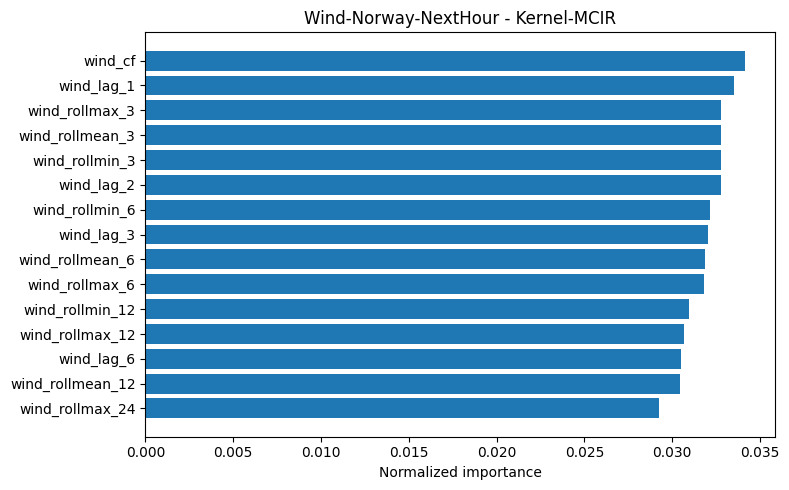

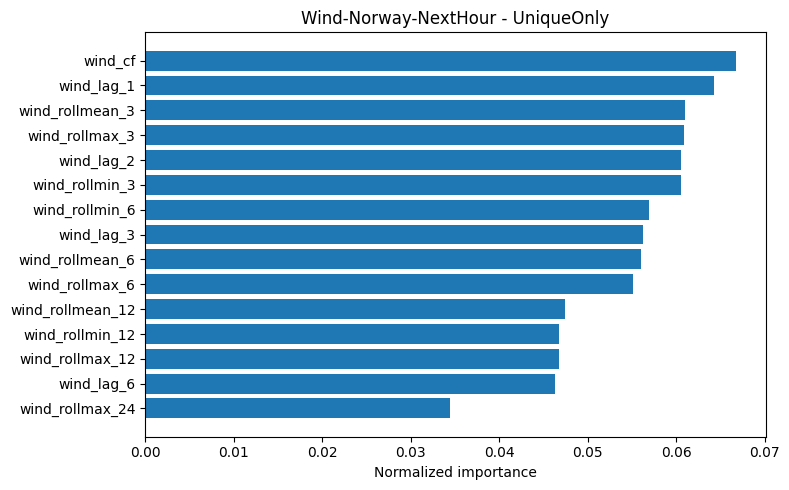

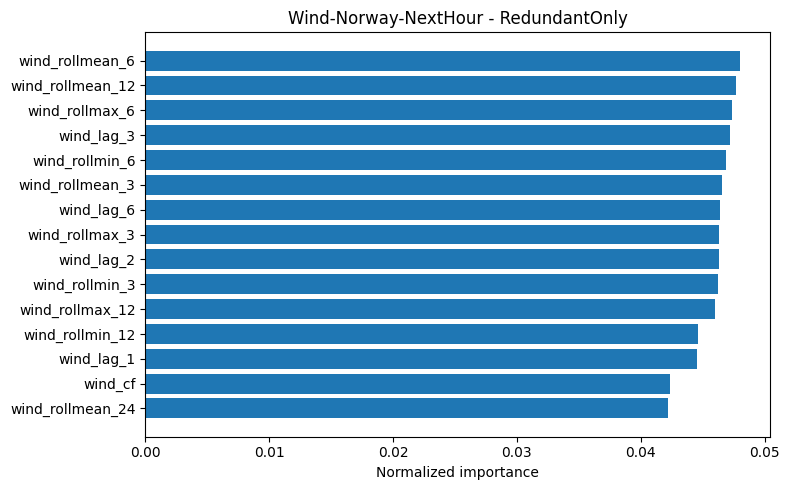

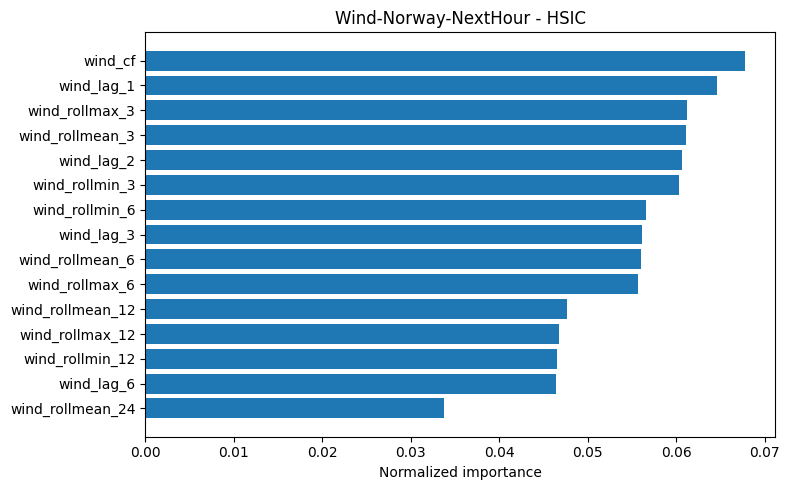

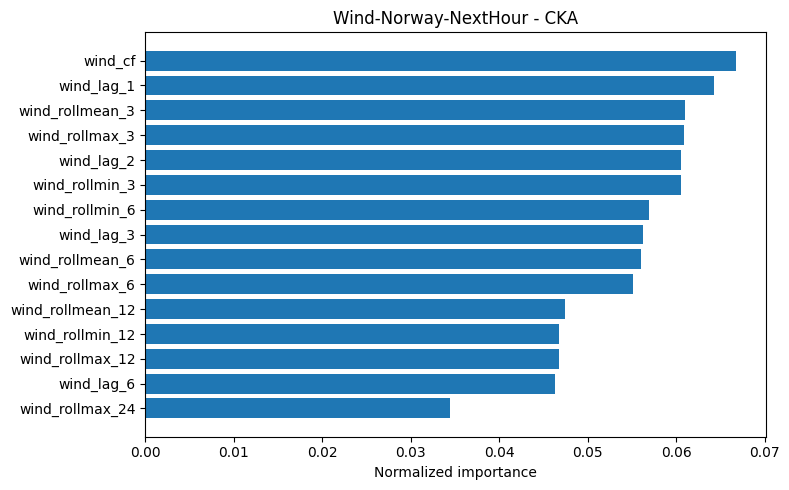

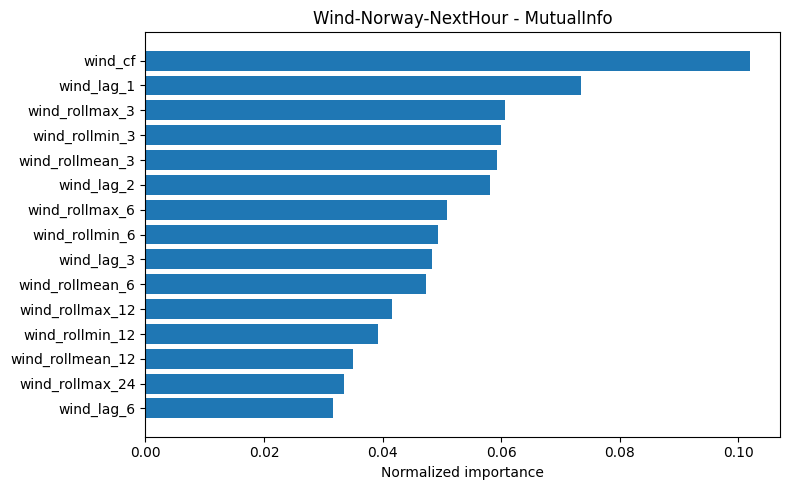

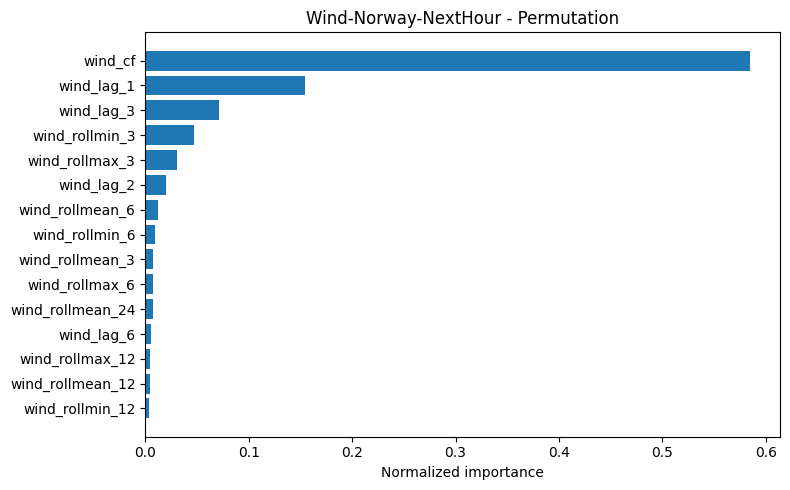

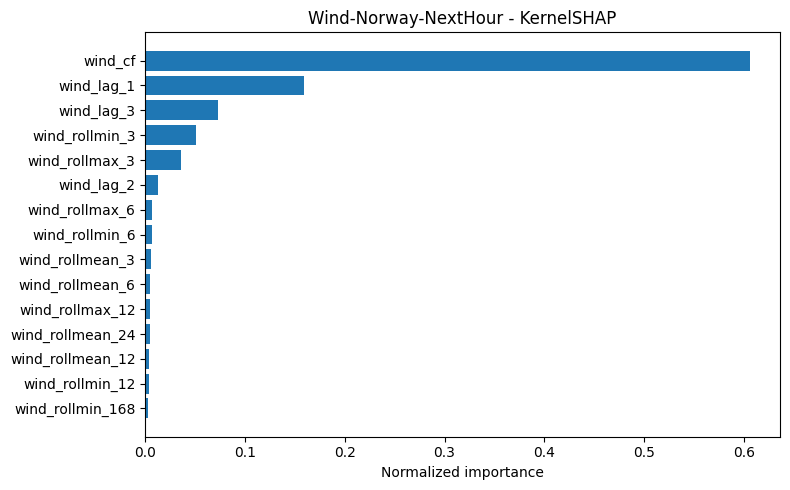

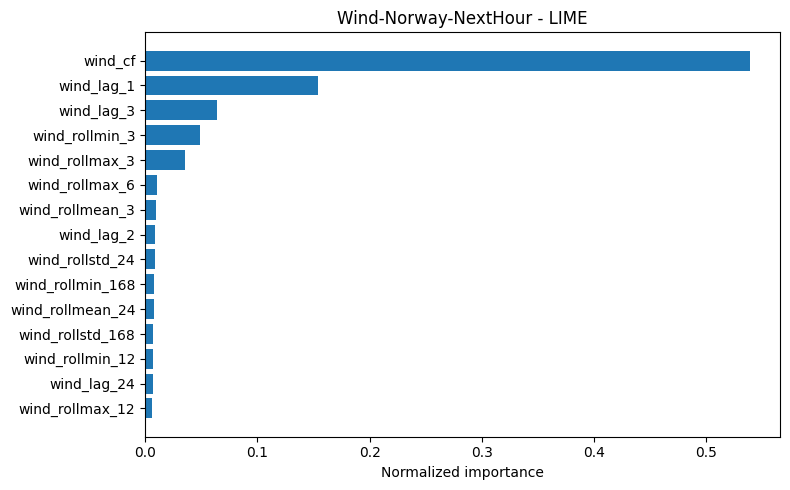

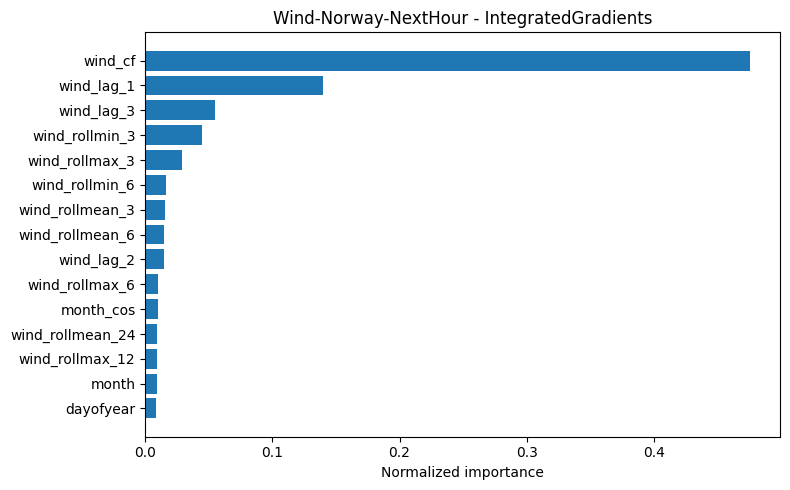

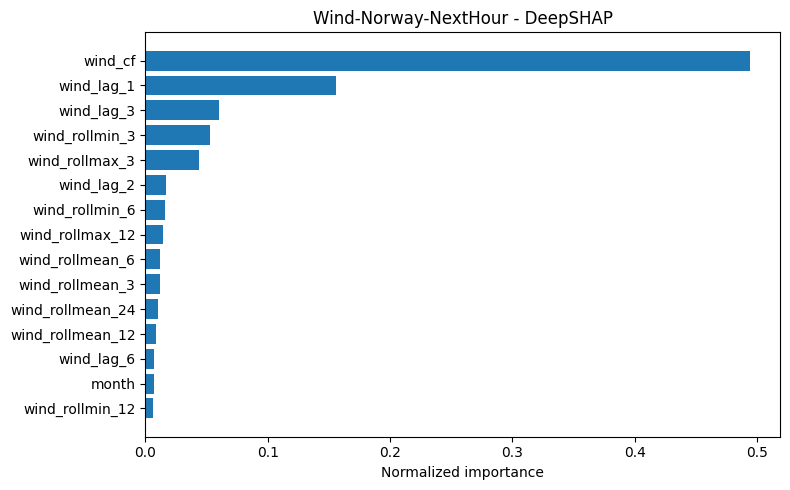

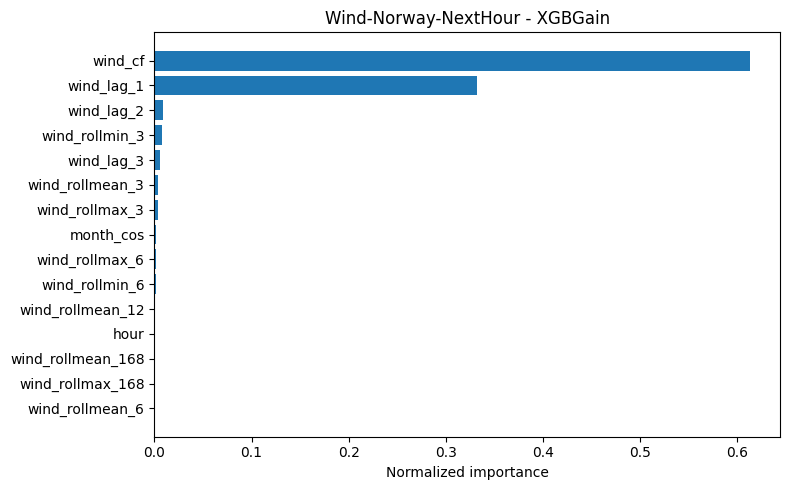

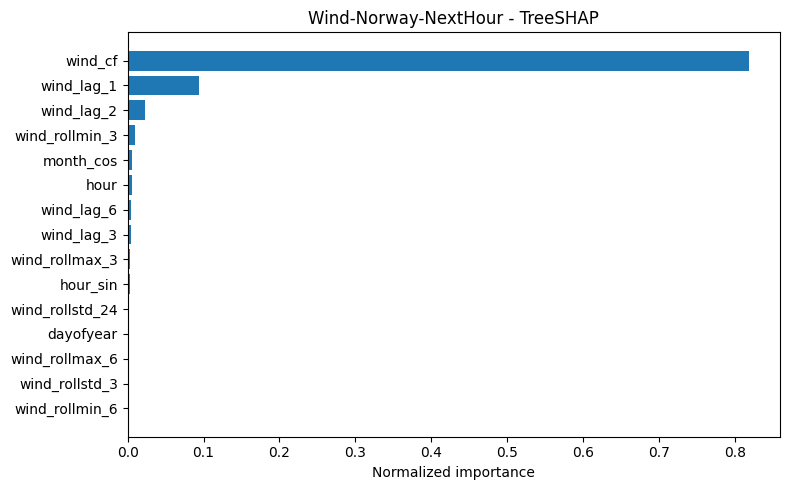

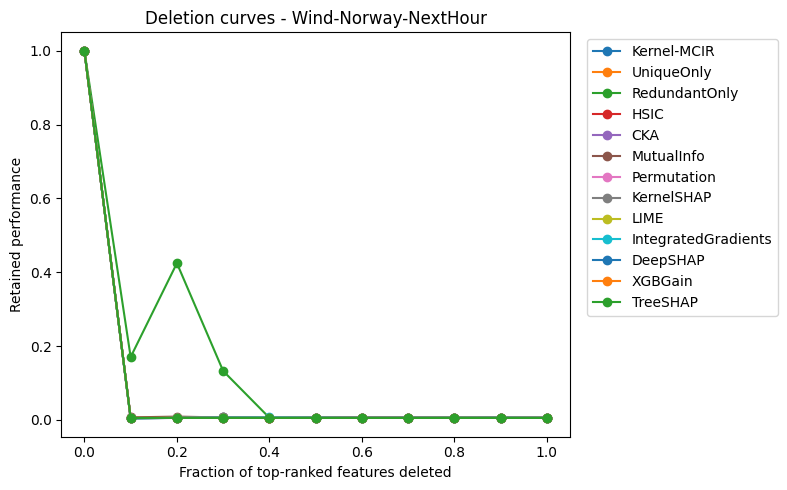


DATASET: UCI-AirQuality-NextHour-CO
Training MLP...
Training XGBoost...

MLP predictive performance
Validation: {'RMSE': 0.7470826950813876, 'MAE': 0.5159116862464971, 'R2': 0.6454668607285297}
Test      : {'RMSE': 0.600178610011804, 'MAE': 0.4284902446722799, 'R2': 0.8043600704212692}

XGBoost predictive performance
Validation: {'RMSE': 0.7712658056841096, 'MAE': 0.5128818923513249, 'R2': 0.6221428565966396}
Test      : {'RMSE': 0.5947083371572439, 'MAE': 0.4090180687259796, 'R2': 0.8079101024988388}
Running: Kernel-MCIR
Running: UniqueOnly
Running: RedundantOnly
Running: HSIC
Running: CKA
Running: MutualInfo
Running: Permutation
Running: KernelSHAP


  0%|          | 0/48 [00:00<?, ?it/s]

  0%|          | 0/48 [00:00<?, ?it/s]

  0%|          | 0/48 [00:00<?, ?it/s]

  0%|          | 0/48 [00:00<?, ?it/s]

...

Running: LIME
Running: IntegratedGradients
Running: DeepSHAP
Running: XGBGain
Running: TreeSHAP

Explainer summary
                 method model_type  stability_spearman  stability_kendall  \
0              DeepSHAP        mlp            0.958330           0.842051   
1           Permutation        mlp            0.871501           0.712821   
2            KernelSHAP        mlp            0.935660           0.833883   
3                  LIME        mlp            0.999662           0.995385   
4           Kernel-MCIR        mlp            0.824125           0.681623   
5                  HSIC        mlp            0.874053           0.713333   
6               XGBGain        xgb            1.000000           1.000000   
7              TreeSHAP        xgb            0.992176           0.947692   
8            UniqueOnly        mlp            0.864165           0.698565   
9                   CKA        mlp            0.864165           0.698565   
10  IntegratedGradients        mlp    

  0%|          | 0/48 [00:00<?, ?it/s]

  0%|          | 0/48 [00:00<?, ?it/s]

  0%|          | 0/48 [00:00<?, ?it/s]


Noise robustness summary
                method  spearman_clean_gaussian  spearman_clean_adversarial
0          Kernel-MCIR                 0.806942                    0.729268
1                 HSIC                 0.971482                    0.902814
2                  CKA                 0.966604                    0.901689
3           KernelSHAP                 0.972998                    0.970957
4  IntegratedGradients                 0.976923                    0.958724
5                 LIME                 1.000000                    0.999625
6             DeepSHAP                 0.978612                    0.964353


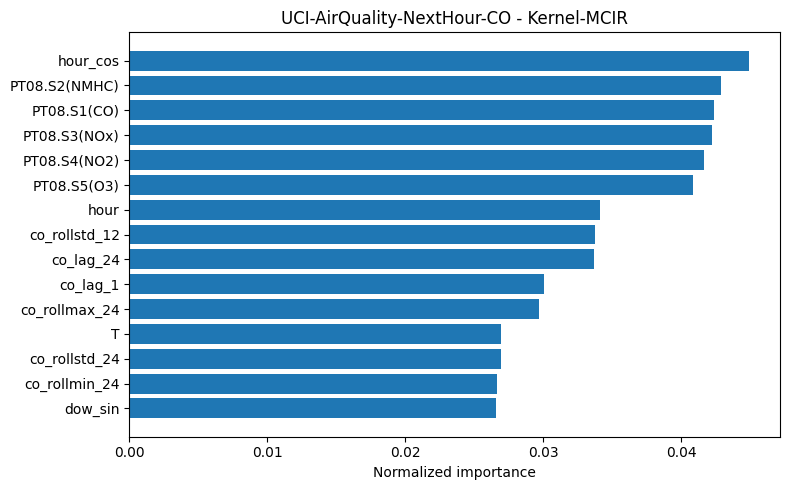

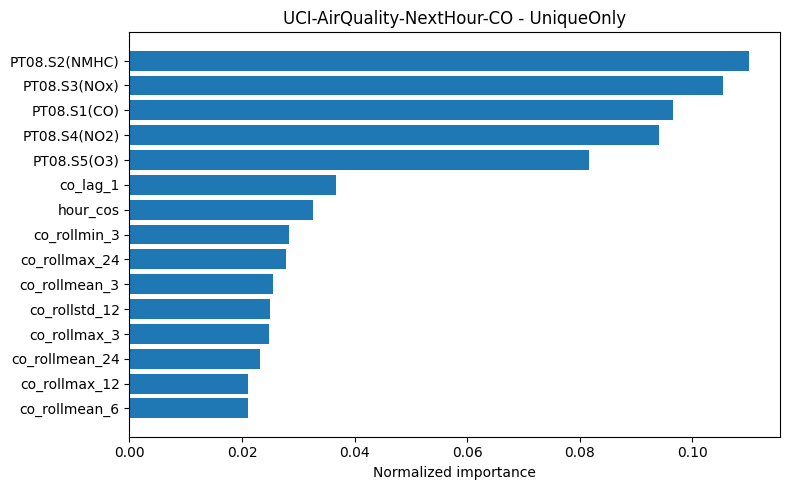

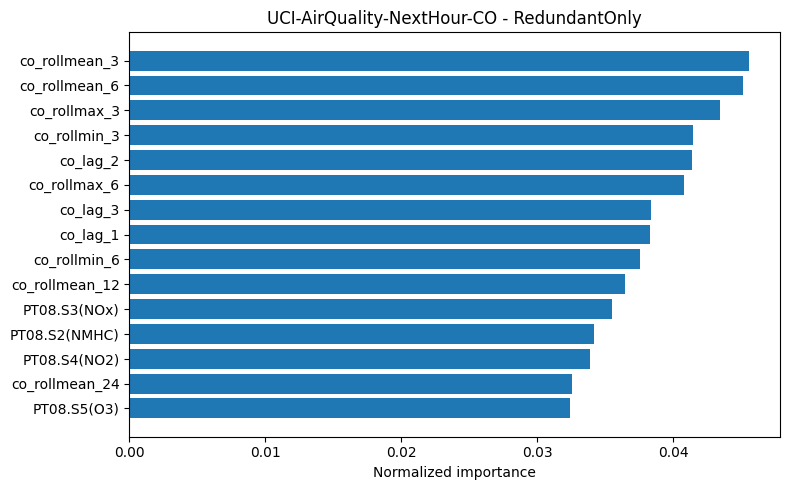

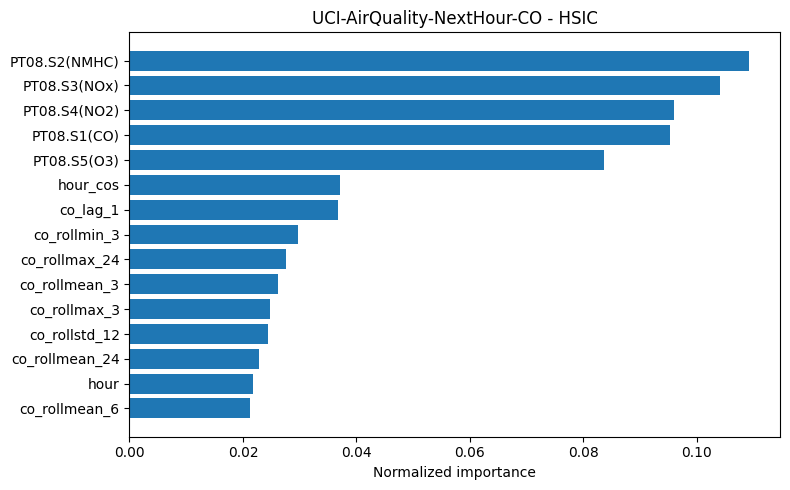

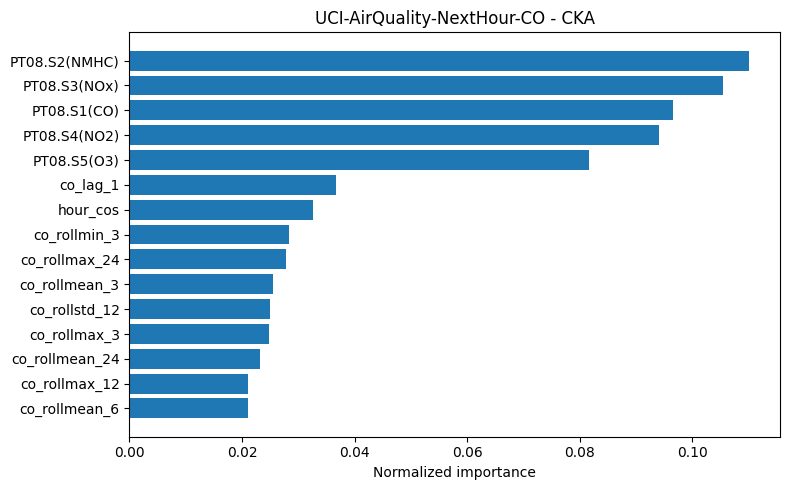

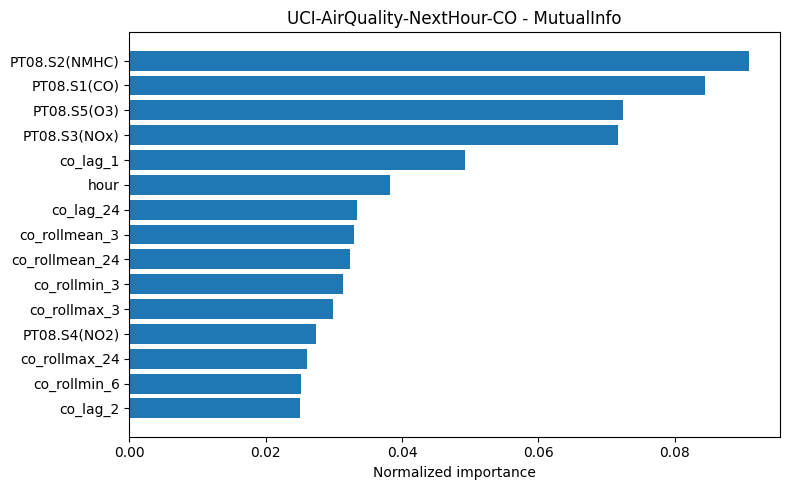

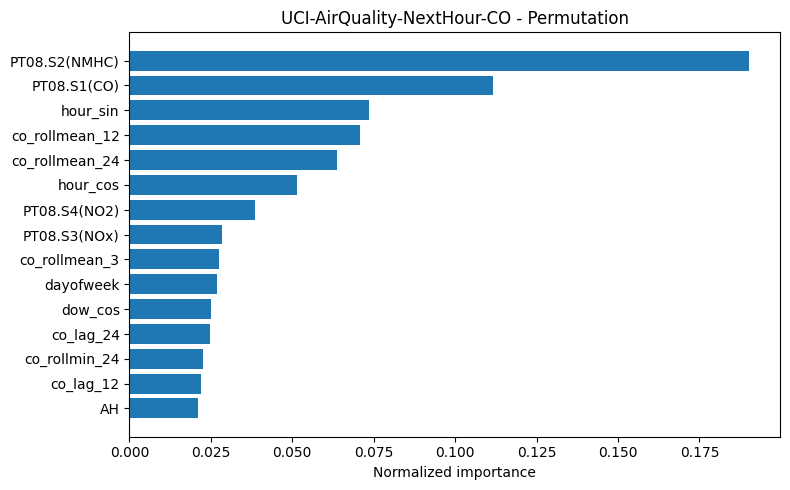

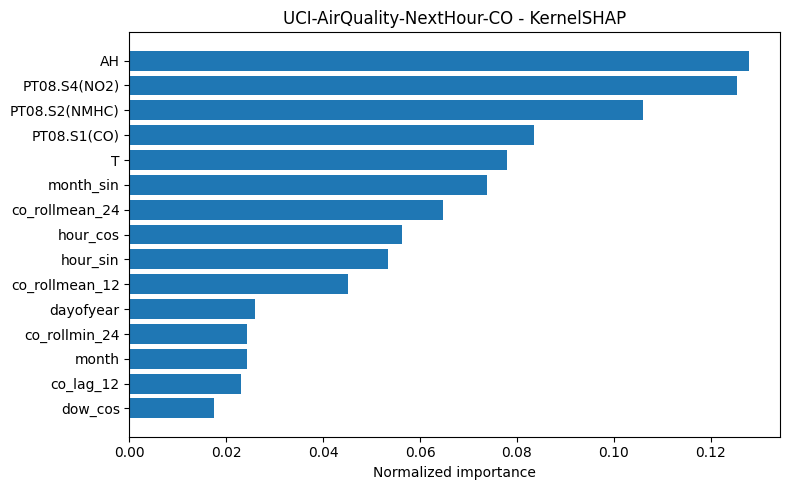

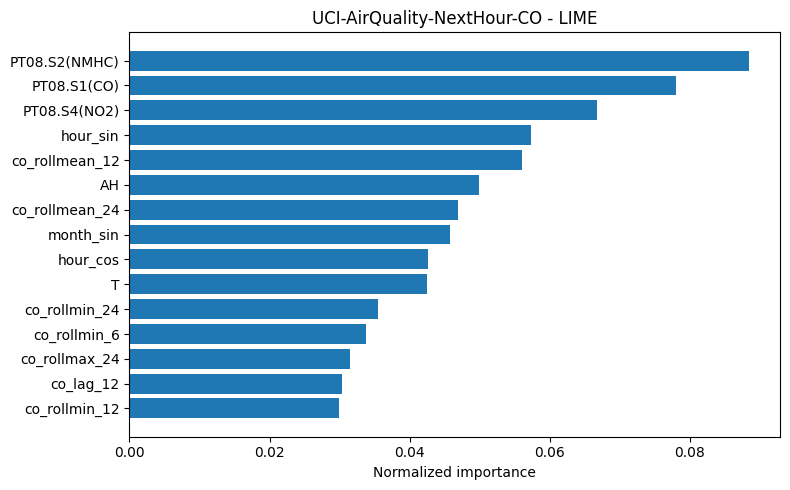

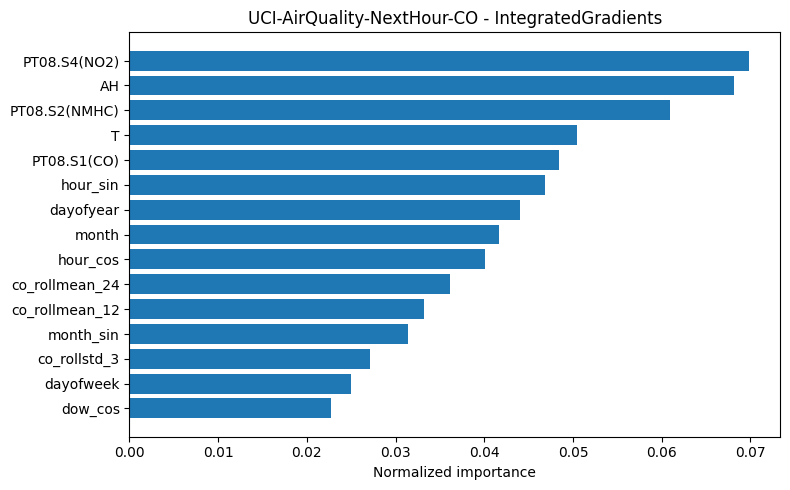

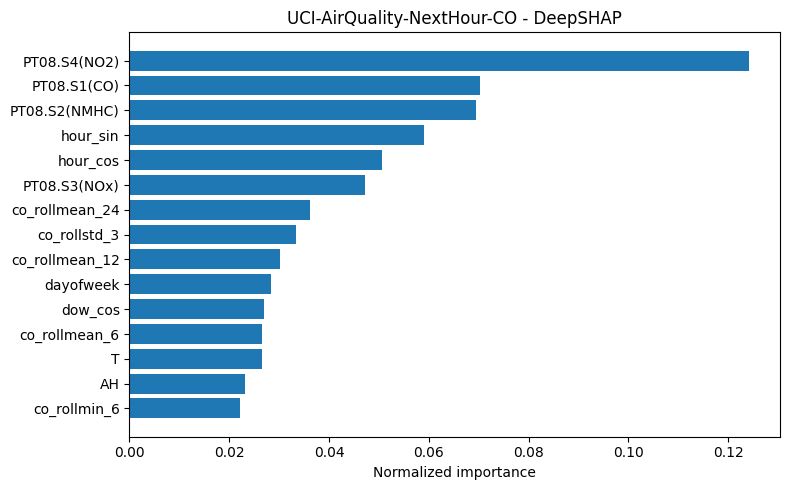

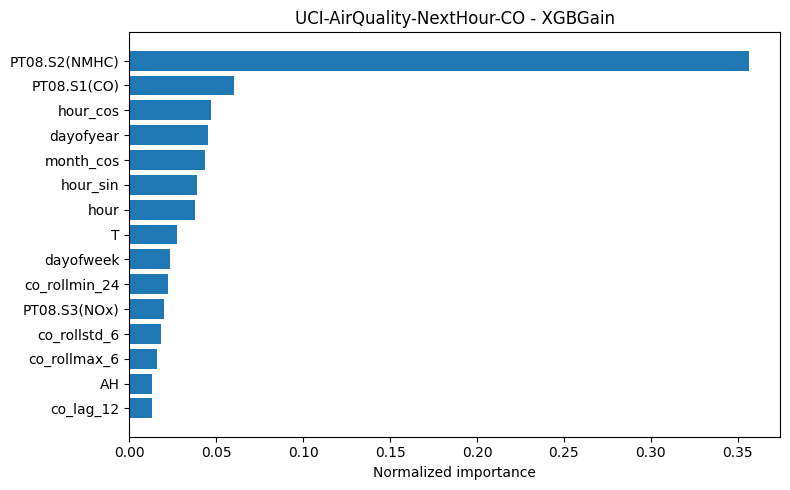

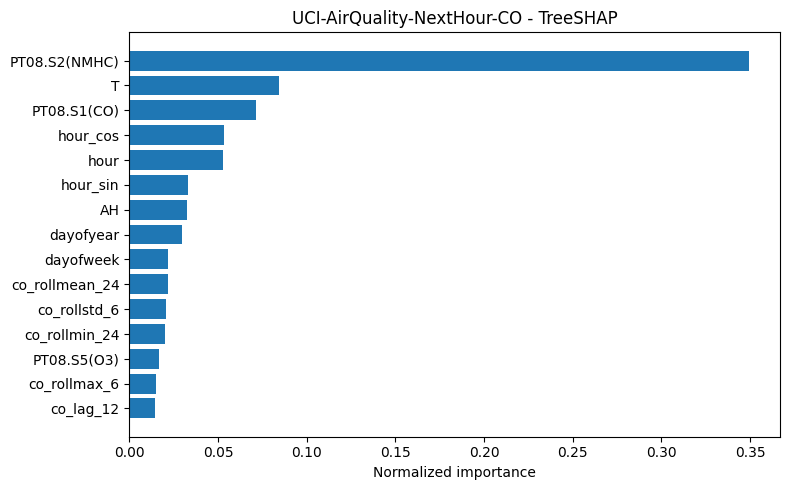

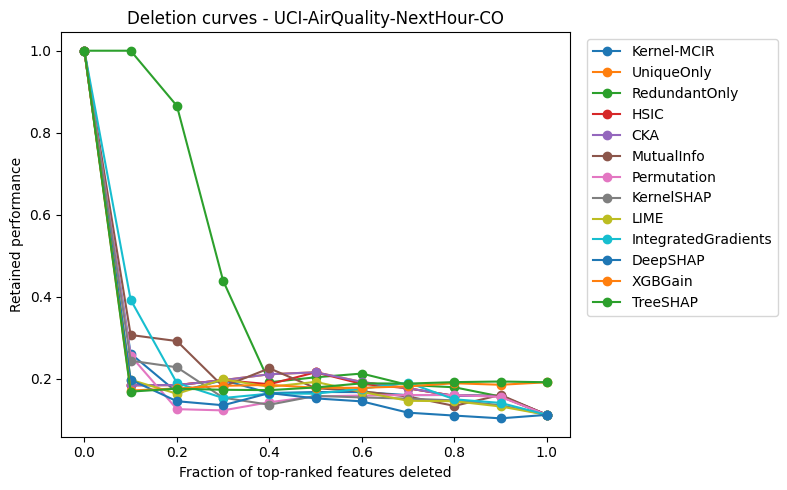


DATASET: Synthetic-Redundancy
Training MLP...
Training XGBoost...

MLP predictive performance
Validation: {'RMSE': 0.12091502531905896, 'MAE': 0.09692741617767195, 'R2': 0.9930238980756254}
Test      : {'RMSE': 0.12759700257545575, 'MAE': 0.09983375399517358, 'R2': 0.9922645956091789}

XGBoost predictive performance
Validation: {'RMSE': 0.12460534311569008, 'MAE': 0.09950993376835023, 'R2': 0.9925915798252799}
Test      : {'RMSE': 0.13171478917380017, 'MAE': 0.10380557690133396, 'R2': 0.9917572683712886}
Running: Kernel-MCIR
Running: UniqueOnly
Running: RedundantOnly
Running: HSIC
Running: CKA
Running: MutualInfo
Running: Permutation
Running: KernelSHAP


  0%|          | 0/48 [00:00<?, ?it/s]

  0%|          | 0/48 [00:00<?, ?it/s]

  0%|          | 0/48 [00:00<?, ?it/s]

  0%|          | 0/48 [00:00<?, ?it/s]

...

Running: LIME
Running: IntegratedGradients
Running: DeepSHAP
Running: XGBGain
Running: TreeSHAP

Explainer summary
                 method model_type  stability_spearman  stability_kendall  \
0   IntegratedGradients        mlp                1.00               1.00   
1              DeepSHAP        mlp                0.96               0.92   
2           Kernel-MCIR        mlp                0.62               0.56   
3           Permutation        mlp                1.00               1.00   
4            KernelSHAP        mlp                0.96               0.92   
5            MutualInfo        mlp                1.00               1.00   
6                  LIME        mlp                1.00               1.00   
7              TreeSHAP        xgb                0.84               0.76   
8            UniqueOnly        mlp                0.85               0.72   
9                  HSIC        mlp                0.85               0.72   
10                  CKA        mlp    

  0%|          | 0/48 [00:00<?, ?it/s]

  0%|          | 0/48 [00:00<?, ?it/s]

  0%|          | 0/48 [00:00<?, ?it/s]


Noise robustness summary
                method  spearman_clean_gaussian  spearman_clean_adversarial
0          Kernel-MCIR                      1.0                         0.9
1                 HSIC                      0.9                         1.0
2                  CKA                      1.0                         0.9
3           KernelSHAP                      1.0                         1.0
4  IntegratedGradients                      1.0                         1.0
5                 LIME                      1.0                         1.0
6             DeepSHAP                      1.0                         1.0


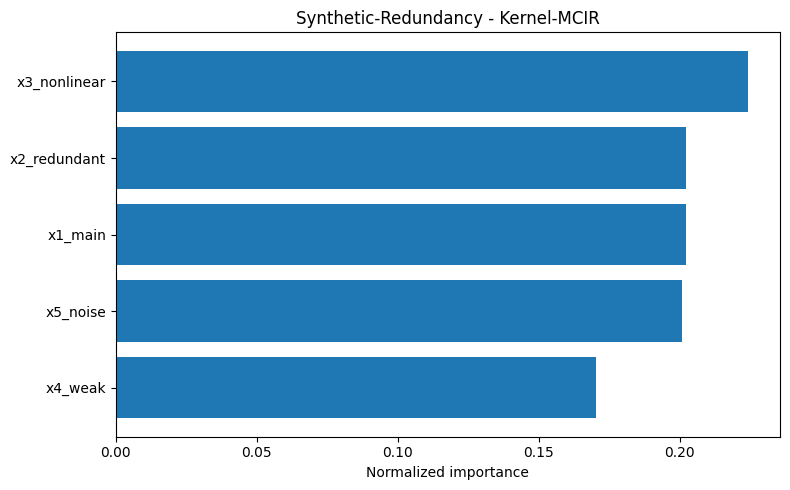

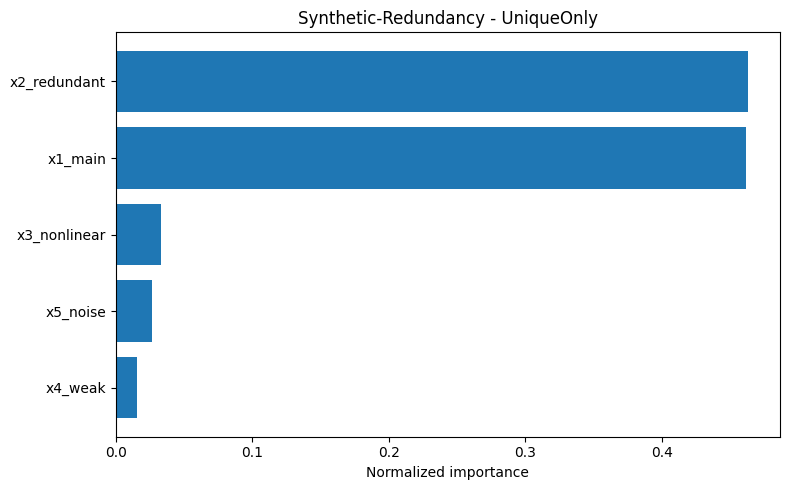

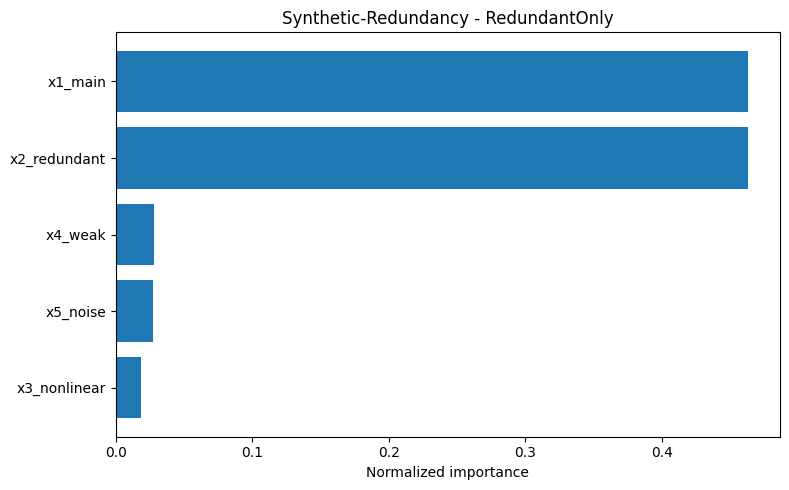

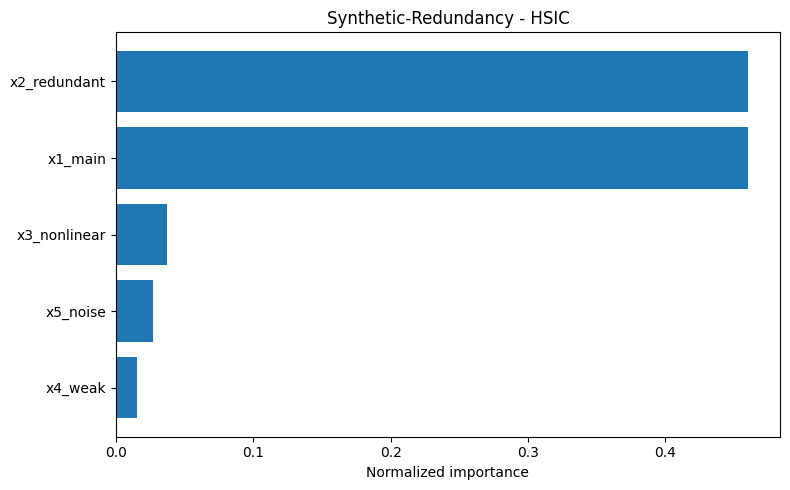

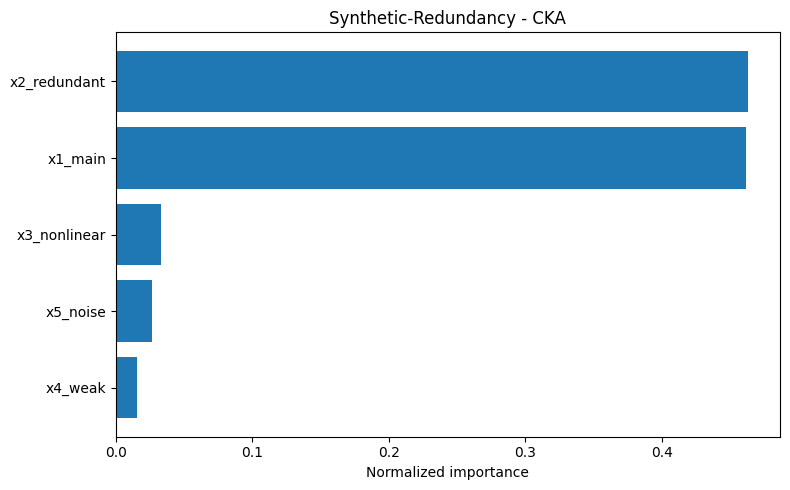

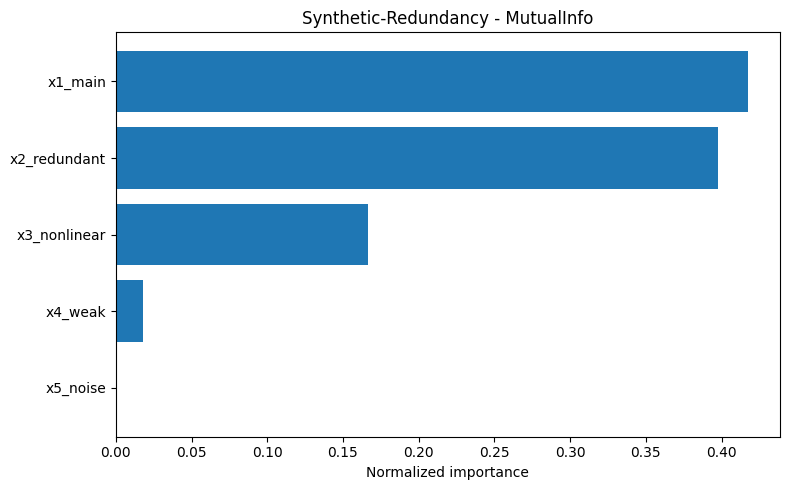

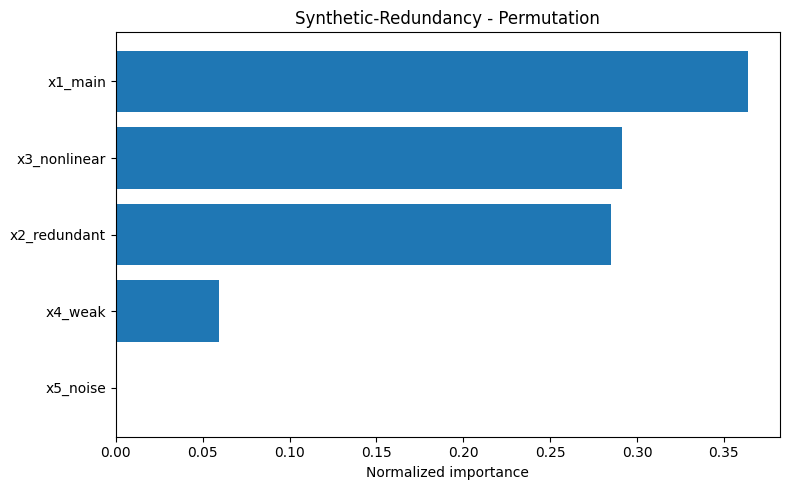

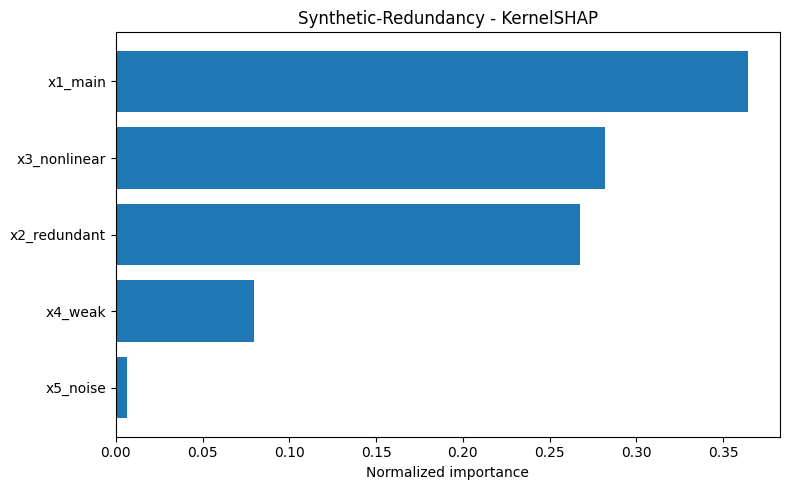

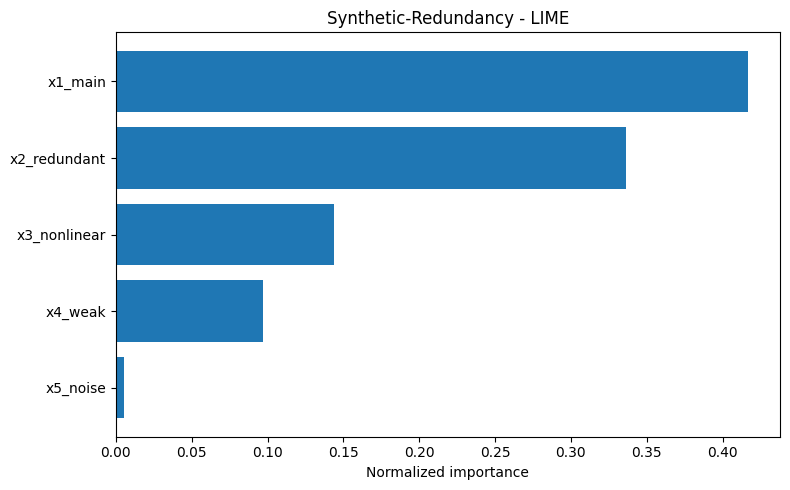

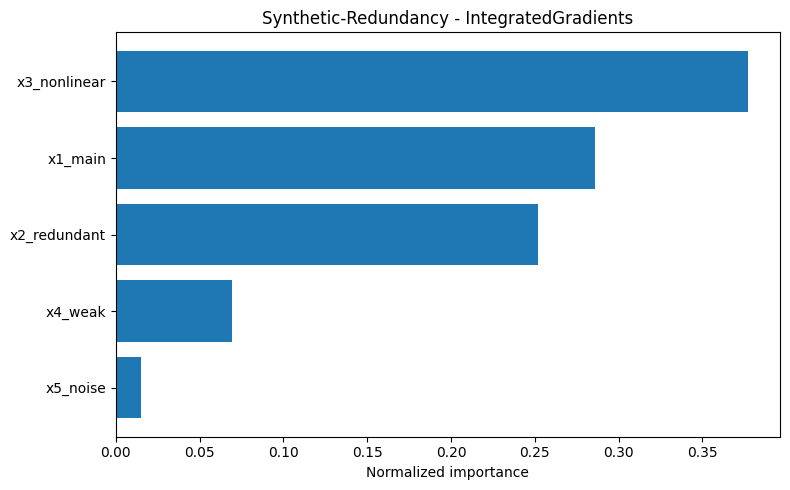

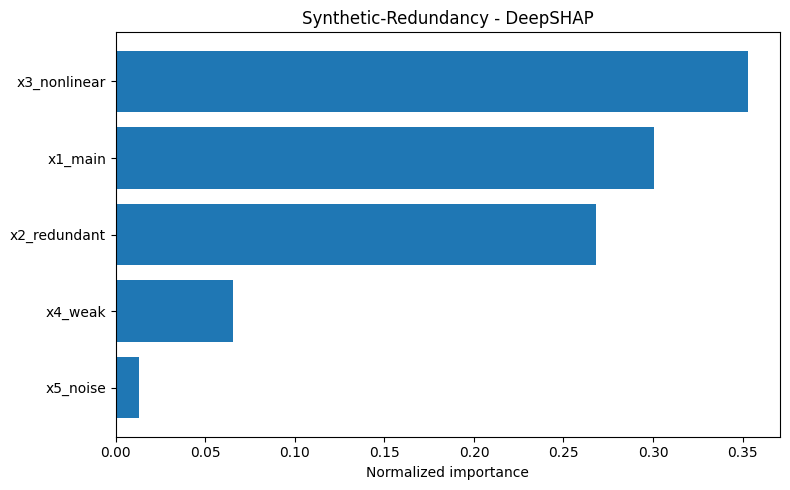

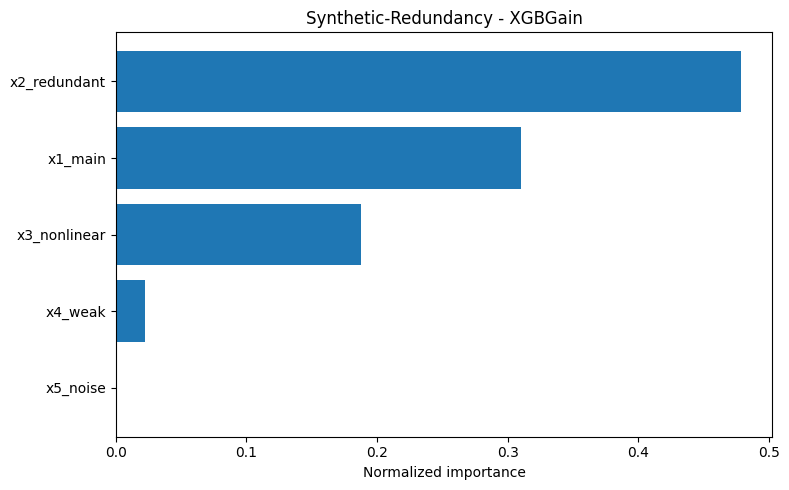

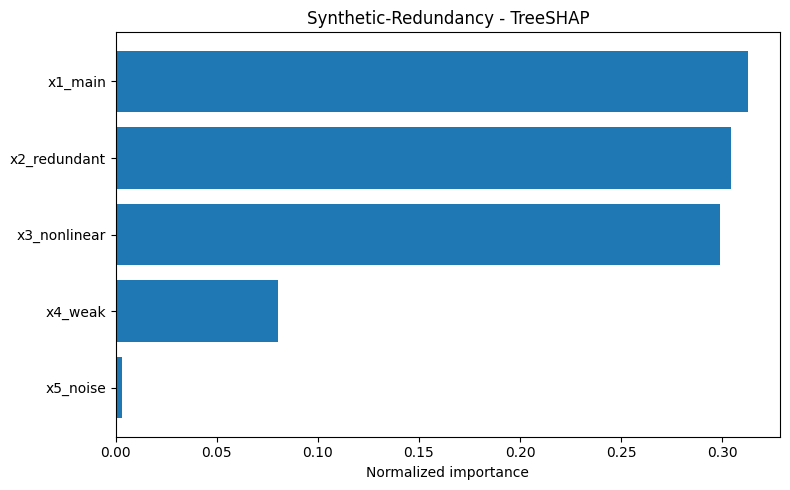

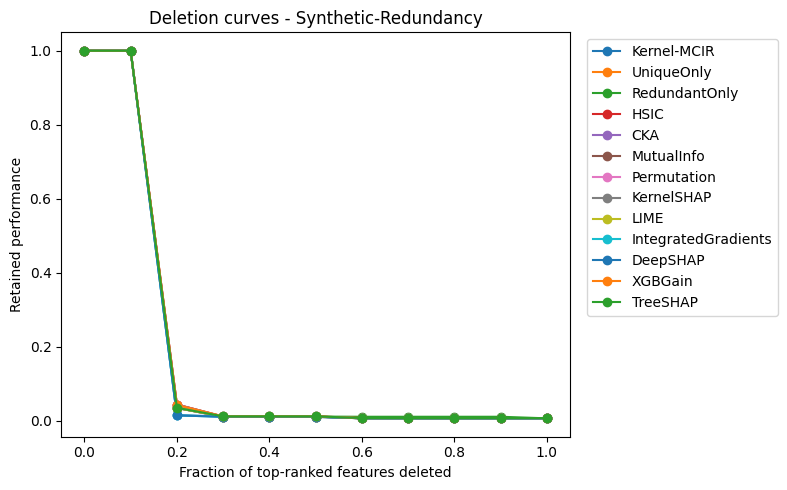


FINAL COMBINED SUMMARY
                       dataset               method model_type  \
0         Wind-Norway-NextHour              XGBGain        xgb   
1         Wind-Norway-NextHour             TreeSHAP        xgb   
2         Wind-Norway-NextHour             DeepSHAP        mlp   
3         Wind-Norway-NextHour                 LIME        mlp   
4         Wind-Norway-NextHour          Permutation        mlp   
5         Wind-Norway-NextHour  IntegratedGradients        mlp   
6         Wind-Norway-NextHour           UniqueOnly        mlp   
7         Wind-Norway-NextHour                  CKA        mlp   
8         Wind-Norway-NextHour                 HSIC        mlp   
9         Wind-Norway-NextHour           KernelSHAP        mlp   
10        Wind-Norway-NextHour          Kernel-MCIR        mlp   
11        Wind-Norway-NextHour           MutualInfo        mlp   
12        Wind-Norway-NextHour        RedundantOnly        mlp   
13  UCI-AirQuality-NextHour-CO             DeepSHAP 

In [ ]:
# ============================================================
# FIXED FULL GOOGLE COLAB SCRIPT
# Kernel-MCIR + modern XAI baseline comparison
#
# Main fixes:
#   1) Permutation importance bug fixed (manual MLP permutation)
#   2) Kernel-MCIR improved with redundancy weight alpha
#   3) Main benchmark uses RBF only
#   4) Kernel sensitivity kept as separate diagnostic
#   5) Synthetic kernel sensitivity can be skipped
# ============================================================

# =========================
# 0. INSTALLS
# =========================
!pip -q install shap lime xgboost tqdm openpyxl tensorflow

# =========================
# 1. IMPORTS
# =========================
import os
import io
import gc
import time
import math
import random
import zipfile
import urllib.request
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, kendalltau
from scipy.spatial.distance import pdist, squareform

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import mutual_info_regression

from xgboost import XGBRegressor
import shap
from lime.lime_tabular import LimeTabularExplainer

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# =========================
# 2. REPRODUCIBILITY
# =========================
SEED = 42

def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)

set_seed(SEED)

# =========================
# 3. SETTINGS
# =========================
N_STABILITY_RUNS = 5
EXPLAIN_SAMPLE = 192
KERNEL_SHAP_BG = 48
KERNEL_SHAP_EVAL = 48
DEEPSHAP_BG = 64
LIME_EVAL = 40
IG_EVAL = 96
IG_STEPS = 32
PERM_REPEATS = 10
DELETION_STEPS = 11
TOPK_PLOT = 15
NOISE_STD = 0.20

# Kernel-MCIR fix
ALPHA_REDUNDANCY = 0.7
MAIN_KERNEL = "rbf"

# Diagnostic controls
RUN_KERNEL_SENSITIVITY = True
RUN_SYNTHETIC_KERNEL_SENSITIVITY = False  # safer default
RUN_NOISE_ROBUSTNESS = True

WIND_URL = "https://data.open-power-system-data.org/ninja_pv_wind_profiles/2020-09-16/ninja_pv_wind_profiles_singleindex.csv"
AIR_QUALITY_ZIP_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip"

# =========================
# 4. UTILITIES
# =========================
def rmse(y_true, y_pred):
    return math.sqrt(mean_squared_error(y_true, y_pred))

def regression_metrics(y_true, y_pred):
    return {
        "RMSE": rmse(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

def clean_numeric_series(s):
    if pd.api.types.is_numeric_dtype(s):
        return pd.to_numeric(s, errors="coerce")
    return pd.to_numeric(
        s.astype(str).str.replace(",", ".", regex=False).str.strip(),
        errors="coerce"
    )

def chronological_split(df, train_frac=0.7, val_frac=0.15):
    n = len(df)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)
    train_df = df.iloc[:n_train].copy()
    val_df = df.iloc[n_train:n_train+n_val].copy()
    test_df = df.iloc[n_train+n_val:].copy()
    return train_df, val_df, test_df

def add_calendar_features(df, time_col):
    df["hour"] = df[time_col].dt.hour
    df["dayofweek"] = df[time_col].dt.dayofweek
    df["dayofyear"] = df[time_col].dt.dayofyear
    df["month"] = df[time_col].dt.month

    df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
    df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)
    df["dow_sin"] = np.sin(2*np.pi*df["dayofweek"]/7)
    df["dow_cos"] = np.cos(2*np.pi*df["dayofweek"]/7)
    df["month_sin"] = np.sin(2*np.pi*df["month"]/12)
    df["month_cos"] = np.cos(2*np.pi*df["month"]/12)
    return df

def make_lag_features(df, target_col, lags, prefix):
    for lag in lags:
        df[f"{prefix}_lag_{lag}"] = df[target_col].shift(lag)
    return df

def make_rolling_features(df, target_col, windows, prefix, shift_first=True):
    base = df[target_col].shift(1) if shift_first else df[target_col]
    for w in windows:
        df[f"{prefix}_rollmean_{w}"] = base.rolling(w).mean()
        df[f"{prefix}_rollstd_{w}"] = base.rolling(w).std()
        df[f"{prefix}_rollmin_{w}"] = base.rolling(w).min()
        df[f"{prefix}_rollmax_{w}"] = base.rolling(w).max()
    return df

def normalize_importance(scores):
    scores = np.asarray(scores, dtype=float)
    scores = np.nan_to_num(scores, nan=0.0, posinf=0.0, neginf=0.0)
    scores = np.abs(scores)
    total = scores.sum()
    if total <= 0:
        return np.ones_like(scores) / len(scores)
    return scores / total

def sample_rows(X, y=None, n=128, seed=42):
    n = min(n, len(X))
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), size=n, replace=False)
    if y is None:
        return X[idx], idx
    return X[idx], y[idx], idx

def pairwise_mean_spearman(vectors):
    vals = []
    for i in range(len(vectors)):
        for j in range(i+1, len(vectors)):
            rho = spearmanr(vectors[i], vectors[j]).correlation
            if np.isnan(rho):
                rho = 0.0
            vals.append(rho)
    return float(np.mean(vals)) if vals else np.nan

def mean_kendall_tau(vectors):
    vals = []
    for i in range(len(vectors)):
        for j in range(i+1, len(vectors)):
            tau = kendalltau(vectors[i], vectors[j]).correlation
            if np.isnan(tau):
                tau = 0.0
            vals.append(tau)
    return float(np.mean(vals)) if vals else np.nan

def auc_trapz(y, x):
    return np.trapz(y, x)

# =========================
# 5. DATA LOADERS
# =========================
def load_wind_dataset():
    print("Loading wind dataset...")
    usecols = ["time", "NO_wind_national_current"]
    df = pd.read_csv(WIND_URL, usecols=usecols, parse_dates=["time"])
    df = df.rename(columns={"NO_wind_national_current": "wind_cf"})
    df = df.sort_values("time").dropna().reset_index(drop=True)

    if len(df) > 50000:
        df = df.iloc[-50000:].reset_index(drop=True)

    df = add_calendar_features(df, "time")
    df = make_lag_features(df, "wind_cf", [1,2,3,6,12,24,48,72,168], "wind")
    df = make_rolling_features(df, "wind_cf", [3,6,12,24,168], "wind")

    df["target"] = df["wind_cf"].shift(-1)
    df = df.dropna().reset_index(drop=True)

    feature_cols = [c for c in df.columns if c not in ["time", "target"]]
    train_df, val_df, test_df = chronological_split(df)

    return {
        "name": "Wind-Norway-NextHour",
        "feature_cols": feature_cols,
        "train_df": train_df,
        "val_df": val_df,
        "test_df": test_df
    }

def load_air_quality_dataset():
    print("Loading UCI Air Quality...")
    response = urllib.request.urlopen(AIR_QUALITY_ZIP_URL)
    zip_bytes = io.BytesIO(response.read())

    with zipfile.ZipFile(zip_bytes) as zf:
        csv_name = None
        for name in zf.namelist():
            if "AirQualityUCI.csv" in name:
                csv_name = name
                break
        if csv_name is None:
            raise FileNotFoundError("AirQualityUCI.csv not found inside ZIP.")

        with zf.open(csv_name) as f:
            df = pd.read_csv(f, sep=";", decimal=",", encoding="latin1")

    df = df.dropna(axis=1, how="all")
    df.columns = [str(c).strip() for c in df.columns]
    df = df.loc[:, ~df.columns.str.contains("^Unnamed", case=False, na=False)]

    for c in df.columns:
        if c not in ["Date", "Time"]:
            df[c] = clean_numeric_series(df[c])
            df[c] = df[c].replace(-200, np.nan)

    df["datetime"] = pd.to_datetime(
        df["Date"].astype(str) + " " + df["Time"].astype(str).str.replace(".", ":", regex=False),
        dayfirst=True,
        errors="coerce"
    )
    df = df.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)

    target_col = "CO(GT)"
    if target_col not in df.columns:
        candidates = [c for c in df.columns if "CO" in c and "GT" in c]
        if len(candidates) == 0:
            raise ValueError("Could not find CO(GT) column.")
        target_col = candidates[0]

    df = add_calendar_features(df, "datetime")
    df = make_lag_features(df, target_col, [1,2,3,6,12,24], "co")
    df = make_rolling_features(df, target_col, [3,6,12,24], "co")

    df["target"] = df[target_col].shift(-1)

    sensor_cols = [c for c in df.columns if "PT08" in c.upper()]
    weather_cols = [c for c in df.columns if c in ["T", "RH", "AH"]]

    feature_cols = []
    feature_cols += sensor_cols
    feature_cols += weather_cols
    feature_cols += [c for c in df.columns if c.startswith("co_lag_") or c.startswith("co_roll")]
    feature_cols += [
        "hour", "dayofweek", "dayofyear", "month",
        "hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos"
    ]
    feature_cols = list(dict.fromkeys([c for c in feature_cols if c in df.columns]))

    df = df[["datetime"] + feature_cols + ["target"]].dropna().reset_index(drop=True)
    train_df, val_df, test_df = chronological_split(df)

    return {
        "name": "UCI-AirQuality-NextHour-CO",
        "feature_cols": feature_cols,
        "train_df": train_df,
        "val_df": val_df,
        "test_df": test_df
    }

def load_synthetic_dataset():
    print("Loading synthetic dataset...")
    rng = np.random.default_rng(SEED)
    n = 5000

    x1 = rng.normal(size=n)
    x2 = x1 + 0.08 * rng.normal(size=n)
    x3 = rng.uniform(-2, 2, size=n)
    x4 = rng.normal(size=n)
    x5 = rng.normal(size=n)

    y = np.sin(1.5*x1) + 0.8*np.sin(1.2*x2) + 0.6*(x3**2) + 0.2*x4 + 0.1*rng.normal(size=n)

    df = pd.DataFrame({
        "x1_main": x1,
        "x2_redundant": x2,
        "x3_nonlinear": x3,
        "x4_weak": x4,
        "x5_noise": x5,
        "target": y
    })

    train_df, val_df, test_df = chronological_split(df)
    feature_cols = [c for c in df.columns if c != "target"]

    return {
        "name": "Synthetic-Redundancy",
        "feature_cols": feature_cols,
        "train_df": train_df,
        "val_df": val_df,
        "test_df": test_df
    }

# =========================
# 6. PREP
# =========================
def prepare_xy(dataset):
    feature_cols = dataset["feature_cols"]
    train_df = dataset["train_df"]
    val_df = dataset["val_df"]
    test_df = dataset["test_df"]

    X_train = train_df[feature_cols].copy()
    y_train = train_df["target"].values.astype(float)

    X_val = val_df[feature_cols].copy()
    y_val = val_df["target"].values.astype(float)

    X_test = test_df[feature_cols].copy()
    y_test = test_df["target"].values.astype(float)

    prep = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    X_train_p = prep.fit_transform(X_train).astype(np.float32)
    X_val_p = prep.transform(X_val).astype(np.float32)
    X_test_p = prep.transform(X_test).astype(np.float32)

    return feature_cols, prep, X_train_p, y_train, X_val_p, y_val, X_test_p, y_test

# =========================
# 7. MODELS
# =========================
def train_xgb_regressor(X_train, y_train, X_val, y_val, seed=42):
    model = XGBRegressor(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=seed,
        tree_method="hist",
        eval_metric="rmse"
    )
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    return model

def build_mlp(input_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="linear")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse"
    )
    return model

def train_mlp_regressor(X_train, y_train, X_val, y_val, seed=42):
    set_seed(seed)
    model = build_mlp(X_train.shape[1])

    es = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=80,
        batch_size=128,
        verbose=0,
        callbacks=[es]
    )
    return model

def mlp_predict(model, X):
    return model.predict(X, verbose=0).reshape(-1)

# =========================
# 8. KERNEL TOOLS
# =========================
def center_kernel(K):
    n = K.shape[0]
    H = np.eye(n) - np.ones((n, n))/n
    return H @ K @ H

def linear_kernel_1d(x):
    x = x.reshape(-1, 1)
    return x @ x.T

def poly_kernel_1d(x, degree=2, coef0=1.0):
    x = x.reshape(-1, 1)
    return (x @ x.T + coef0)**degree

def rbf_kernel_1d(x, gamma=None):
    x = x.reshape(-1, 1)
    D = squareform(pdist(x, metric="sqeuclidean"))
    if gamma is None:
        nz = D[D > 0]
        med = np.median(nz) if len(nz) > 0 else 1.0
        gamma = 1.0 / (2.0 * med + 1e-12)
    return np.exp(-gamma * D)

def build_feature_kernel(x, kernel="rbf"):
    if kernel == "linear":
        return linear_kernel_1d(x)
    elif kernel == "poly":
        return poly_kernel_1d(x)
    else:
        return rbf_kernel_1d(x)

def build_output_kernel(y, kernel="rbf"):
    if kernel == "linear":
        return linear_kernel_1d(y)
    elif kernel == "poly":
        return poly_kernel_1d(y)
    else:
        return rbf_kernel_1d(y)

def hsic_raw(K1, K2):
    n = K1.shape[0]
    H = np.eye(n) - np.ones((n, n))/n
    return np.trace(K1 @ H @ K2 @ H) / ((n - 1)**2 + 1e-12)

def cka_alignment(K1, K2):
    K1c = center_kernel(K1)
    K2c = center_kernel(K2)
    num = np.sum(K1c * K2c)
    den = np.sqrt(np.sum(K1c*K1c) * np.sum(K2c*K2c)) + 1e-12
    return float(num / den)

# =========================
# 9. KERNEL-MCIR / HSIC / CKA
# =========================
def kernel_mcir_decompose(X, y_signal, kernel="rbf", alpha=0.7):
    """
    Fixed version:
      score_j = relevance_j / (relevance_j + alpha * redundancy_j + eps)
    """
    n, p = X.shape
    Ky = build_output_kernel(y_signal, kernel=kernel)
    K_features = [build_feature_kernel(X[:, j], kernel=kernel) for j in range(p)]

    relevance = np.array([max(cka_alignment(Kj, Ky), 0.0) for Kj in K_features])

    redundancy = np.zeros(p)
    for j in range(p):
        vals = []
        for k in range(p):
            if j == k:
                continue
            vals.append(abs(cka_alignment(K_features[j], K_features[k])))
        redundancy[j] = np.mean(vals) if len(vals) else 0.0

    mcir = relevance / (relevance + alpha * redundancy + 1e-12)
    mcir = np.clip(mcir, 0.0, 1.0)

    return {
        "mcir_raw": mcir,
        "mcir_norm": normalize_importance(mcir),
        "unique_raw": relevance,
        "unique_norm": normalize_importance(relevance),
        "redundant_raw": redundancy,
        "redundant_norm": normalize_importance(redundancy),
    }

def hsic_feature_scores(X, y_signal, kernel="rbf"):
    Ky = build_output_kernel(y_signal, kernel=kernel)
    vals = []
    for j in range(X.shape[1]):
        Kj = build_feature_kernel(X[:, j], kernel=kernel)
        vals.append(max(hsic_raw(Kj, Ky), 0.0))
    return normalize_importance(np.array(vals))

def cka_feature_scores(X, y_signal, kernel="rbf"):
    Ky = build_output_kernel(y_signal, kernel=kernel)
    vals = []
    for j in range(X.shape[1]):
        Kj = build_feature_kernel(X[:, j], kernel=kernel)
        vals.append(max(cka_alignment(Kj, Ky), 0.0))
    return normalize_importance(np.array(vals))

# =========================
# 10. CLASSICAL METHODS
# =========================
def get_mutual_info_importance(X_train, y_train):
    imp = mutual_info_regression(X_train, y_train, random_state=SEED)
    return normalize_importance(imp)

def get_permutation_importance_manual(model, X_val, y_val, model_type="mlp", n_repeats=10, seed=42):
    """
    Fixed permutation importance for both MLP and XGB without sklearn estimator requirement.
    Importance is measured as average RMSE increase after shuffling each feature.
    """
    rng = np.random.default_rng(seed)

    if model_type == "mlp":
        base_pred = mlp_predict(model, X_val)
    else:
        base_pred = model.predict(X_val)

    base_rmse = rmse(y_val, base_pred)
    p = X_val.shape[1]
    importances = np.zeros(p)

    for j in range(p):
        deltas = []
        for _ in range(n_repeats):
            Xp = X_val.copy()
            shuffled = Xp[:, j].copy()
            rng.shuffle(shuffled)
            Xp[:, j] = shuffled

            if model_type == "mlp":
                pred = mlp_predict(model, Xp)
            else:
                pred = model.predict(Xp)

            score = rmse(y_val, pred)
            deltas.append(score - base_rmse)

        importances[j] = np.mean(deltas)

    return normalize_importance(importances)

def get_xgb_gain_importance(model, p):
    imp = model.feature_importances_
    if len(imp) != p:
        out = np.zeros(p)
        out[:len(imp)] = imp
        imp = out
    return normalize_importance(imp)

# =========================
# 11. SHAP
# =========================
def get_kernel_shap_importance_mlp(model, X_bg, X_eval):
    bg = shap.sample(X_bg, min(KERNEL_SHAP_BG, len(X_bg)), random_state=SEED)
    ev = shap.sample(X_eval, min(KERNEL_SHAP_EVAL, len(X_eval)), random_state=SEED)

    f = lambda x: mlp_predict(model, x)
    explainer = shap.KernelExplainer(f, bg)
    sv = explainer.shap_values(ev, nsamples="auto")
    if isinstance(sv, list):
        sv = sv[0]
    imp = np.mean(np.abs(sv), axis=0)
    return normalize_importance(imp)

def get_deepshap_importance_mlp(model, X_bg, X_eval):
    bg = X_bg[:min(DEEPSHAP_BG, len(X_bg))]
    ev = X_eval[:min(KERNEL_SHAP_EVAL, len(X_eval))]
    explainer = shap.DeepExplainer(model, bg)
    sv = explainer.shap_values(ev)
    if isinstance(sv, list):
        sv = sv[0]
    sv = np.array(sv)
    if sv.ndim == 3:
        sv = sv[:, :, 0]
    imp = np.mean(np.abs(sv), axis=0)
    return normalize_importance(imp)

def get_tree_shap_importance_xgb(model, X_eval):
    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(X_eval)
    if isinstance(sv, list):
        sv = sv[0]
    imp = np.mean(np.abs(sv), axis=0)
    return normalize_importance(imp)

# =========================
# 12. LIME
# =========================
def get_lime_importance_mlp(model, X_train, X_eval, feature_names):
    explainer = LimeTabularExplainer(
        training_data=X_train,
        feature_names=feature_names,
        mode="regression",
        discretize_continuous=False,
        random_state=SEED
    )

    X_eval_small = X_eval[:min(LIME_EVAL, len(X_eval))]
    p = X_train.shape[1]
    scores = np.zeros(p)

    for x in X_eval_small:
        exp = explainer.explain_instance(
            data_row=x,
            predict_fn=lambda z: mlp_predict(model, z),
            num_features=p
        )
        local_map = exp.local_exp
        key = list(local_map.keys())[0]
        for feat_idx, weight in local_map[key]:
            scores[feat_idx] += abs(weight)

    scores = scores / max(len(X_eval_small), 1)
    return normalize_importance(scores)

# =========================
# 13. INTEGRATED GRADIENTS
# =========================
def integrated_gradients_single(model, x, baseline, steps=32):
    x_tf = tf.convert_to_tensor(x.reshape(1, -1), dtype=tf.float32)
    baseline_tf = tf.convert_to_tensor(baseline.reshape(1, -1), dtype=tf.float32)

    alphas = tf.linspace(0.0, 1.0, steps + 1)
    grads_list = []

    for alpha in alphas:
        x_interp = baseline_tf + alpha * (x_tf - baseline_tf)
        with tf.GradientTape() as tape:
            tape.watch(x_interp)
            pred = model(x_interp, training=False)
        grads = tape.gradient(pred, x_interp)
        grads_list.append(grads.numpy()[0])

    avg_grads = np.mean(np.array(grads_list), axis=0)
    ig = (x - baseline) * avg_grads
    return ig

def get_integrated_gradients_importance_mlp(model, X_train, X_eval, steps=32):
    baseline = np.mean(X_train, axis=0)
    X_eval_small = X_eval[:min(IG_EVAL, len(X_eval))]
    vals = []

    for x in X_eval_small:
        ig = integrated_gradients_single(model, x, baseline, steps=steps)
        vals.append(np.abs(ig))

    vals = np.array(vals)
    imp = np.mean(vals, axis=0)
    return normalize_importance(imp)

# =========================
# 14. DELETION AUC
# =========================
def masked_copy(X, feature_indices, baseline):
    Xm = X.copy()
    Xm[:, feature_indices] = baseline[feature_indices]
    return Xm

def deletion_auc_regression(model, X_test, y_test, importance, baseline, model_type="mlp"):
    ranking = np.argsort(-importance)
    fractions = np.linspace(0, 1, DELETION_STEPS)

    if model_type == "mlp":
        base_pred = mlp_predict(model, X_test)
    else:
        base_pred = model.predict(X_test)

    base_loss = mean_squared_error(y_test, base_pred) + 1e-12
    retained_scores = []
    p = X_test.shape[1]

    for frac in fractions:
        k = int(round(frac * p))
        idx = ranking[:k]
        X_mask = masked_copy(X_test, idx, baseline)

        if model_type == "mlp":
            pred = mlp_predict(model, X_mask)
        else:
            pred = model.predict(X_mask)

        loss = mean_squared_error(y_test, pred) + 1e-12
        retained = base_loss / loss
        retained = float(np.clip(retained, 0.0, 1.0))
        retained_scores.append(retained)

    auc = auc_trapz(retained_scores, fractions)
    return auc, fractions, retained_scores

# =========================
# 15. METHOD DISPATCH
# =========================
def compute_method_importance(
    method_name,
    mlp_model,
    xgb_model,
    X_train,
    y_train,
    X_val,
    y_val,
    feature_names,
    subset_seed=42,
    kernel="rbf"
):
    rng = np.random.default_rng(subset_seed)
    idx = rng.choice(len(X_val), size=len(X_val), replace=True)
    X_sub = X_val[idx]
    y_sub = y_val[idx]

    X_small, y_small, _ = sample_rows(X_sub, y_sub, n=EXPLAIN_SAMPLE, seed=subset_seed)

    if method_name == "Kernel-MCIR":
        y_signal = mlp_predict(mlp_model, X_small)
        return kernel_mcir_decompose(X_small, y_signal, kernel=kernel, alpha=ALPHA_REDUNDANCY)["mcir_norm"], "mlp"

    elif method_name == "UniqueOnly":
        y_signal = mlp_predict(mlp_model, X_small)
        return kernel_mcir_decompose(X_small, y_signal, kernel=kernel, alpha=ALPHA_REDUNDANCY)["unique_norm"], "mlp"

    elif method_name == "RedundantOnly":
        y_signal = mlp_predict(mlp_model, X_small)
        return kernel_mcir_decompose(X_small, y_signal, kernel=kernel, alpha=ALPHA_REDUNDANCY)["redundant_norm"], "mlp"

    elif method_name == "HSIC":
        y_signal = mlp_predict(mlp_model, X_small)
        return hsic_feature_scores(X_small, y_signal, kernel=kernel), "mlp"

    elif method_name == "CKA":
        y_signal = mlp_predict(mlp_model, X_small)
        return cka_feature_scores(X_small, y_signal, kernel=kernel), "mlp"

    elif method_name == "MutualInfo":
        return get_mutual_info_importance(X_train, y_train), "mlp"

    elif method_name == "Permutation":
        return get_permutation_importance_manual(mlp_model, X_sub, y_sub, model_type="mlp", n_repeats=PERM_REPEATS, seed=subset_seed), "mlp"

    elif method_name == "KernelSHAP":
        return get_kernel_shap_importance_mlp(mlp_model, X_train, X_small), "mlp"

    elif method_name == "LIME":
        return get_lime_importance_mlp(mlp_model, X_train, X_small, feature_names), "mlp"

    elif method_name == "IntegratedGradients":
        return get_integrated_gradients_importance_mlp(mlp_model, X_train, X_small, steps=IG_STEPS), "mlp"

    elif method_name == "DeepSHAP":
        return get_deepshap_importance_mlp(mlp_model, X_train, X_small), "mlp"

    elif method_name == "XGBGain":
        return get_xgb_gain_importance(xgb_model, X_train.shape[1]), "xgb"

    elif method_name == "TreeSHAP":
        return get_tree_shap_importance_xgb(xgb_model, X_small), "xgb"

    else:
        raise ValueError(f"Unknown method: {method_name}")

def evaluate_explainer(
    method_name,
    mlp_model,
    xgb_model,
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    feature_names,
    kernel="rbf"
):
    start = time.perf_counter()
    importance, model_type = compute_method_importance(
        method_name, mlp_model, xgb_model, X_train, y_train, X_val, y_val, feature_names, subset_seed=SEED, kernel=kernel
    )
    runtime = time.perf_counter() - start

    stability_vectors = []
    for run in range(N_STABILITY_RUNS):
        imp_r, _ = compute_method_importance(
            method_name, mlp_model, xgb_model, X_train, y_train, X_val, y_val, feature_names,
            subset_seed=SEED + 100 + run, kernel=kernel
        )
        stability_vectors.append(imp_r)

    stability_spearman = pairwise_mean_spearman(stability_vectors)
    stability_kendall = mean_kendall_tau(stability_vectors)

    baseline = np.nanmedian(X_train, axis=0)
    deletion_auc, fractions, retained = deletion_auc_regression(
        mlp_model if model_type == "mlp" else xgb_model,
        X_test, y_test, importance, baseline, model_type=model_type
    )

    top_idx = np.argsort(-importance)[:TOPK_PLOT]
    top_features = [(feature_names[i], float(importance[i])) for i in top_idx]

    return {
        "method": method_name if kernel == MAIN_KERNEL else f"{method_name}-{kernel}",
        "importance": importance,
        "model_type": model_type,
        "runtime_sec": runtime,
        "stability_spearman": stability_spearman,
        "stability_kendall": stability_kendall,
        "deletion_auc": deletion_auc,
        "fractions": fractions,
        "retained_curve": retained,
        "top_features": top_features
    }

# =========================
# 16. NOISE ROBUSTNESS
# =========================
def add_gaussian_noise(X, std=0.2, seed=42):
    rng = np.random.default_rng(seed)
    return X + rng.normal(0, std, size=X.shape)

def add_feature_attack_noise(X, frac=0.2, magnitude=1.0, seed=42):
    rng = np.random.default_rng(seed)
    Xn = X.copy()
    n, p = X.shape
    mask = rng.uniform(size=(n, p)) < frac
    sign = rng.choice([-1.0, 1.0], size=(n, p))
    Xn[mask] = Xn[mask] + magnitude * sign[mask]
    return Xn

def evaluate_noise_robustness(
    method_name,
    mlp_model,
    xgb_model,
    X_train,
    y_train,
    X_val,
    y_val,
    feature_names,
    kernel="rbf"
):
    clean_imp, _ = compute_method_importance(
        method_name, mlp_model, xgb_model, X_train, y_train, X_val, y_val, feature_names, subset_seed=SEED, kernel=kernel
    )

    X_val_gauss = add_gaussian_noise(X_val, std=NOISE_STD, seed=SEED)
    gauss_imp, _ = compute_method_importance(
        method_name, mlp_model, xgb_model, X_train, y_train, X_val_gauss, y_val, feature_names, subset_seed=SEED, kernel=kernel
    )

    X_val_adv = add_feature_attack_noise(X_val, frac=0.2, magnitude=1.0, seed=SEED)
    adv_imp, _ = compute_method_importance(
        method_name, mlp_model, xgb_model, X_train, y_train, X_val_adv, y_val, feature_names, subset_seed=SEED, kernel=kernel
    )

    rho_g = spearmanr(clean_imp, gauss_imp).correlation
    rho_a = spearmanr(clean_imp, adv_imp).correlation

    return {
        "clean": clean_imp,
        "gaussian": gauss_imp,
        "adversarial": adv_imp,
        "spearman_clean_gaussian": float(rho_g if not np.isnan(rho_g) else 0.0),
        "spearman_clean_adversarial": float(rho_a if not np.isnan(rho_a) else 0.0)
    }

# =========================
# 17. PLOTTING
# =========================
def plot_top_features(feature_names, importance, title, topk=15):
    idx = np.argsort(-importance)[:topk]
    names = [feature_names[i] for i in idx][::-1]
    vals = importance[idx][::-1]

    plt.figure(figsize=(8, 5))
    plt.barh(names, vals)
    plt.title(title)
    plt.xlabel("Normalized importance")
    plt.tight_layout()
    plt.show()

def plot_deletion_curves(results, dataset_name):
    plt.figure(figsize=(8, 5))
    for r in results:
        plt.plot(r["fractions"], r["retained_curve"], marker="o", label=r["method"])
    plt.xlabel("Fraction of top-ranked features deleted")
    plt.ylabel("Retained performance")
    plt.title(f"Deletion curves - {dataset_name}")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

# =========================
# 18. MAIN BENCHMARK
# =========================
def run_full_benchmark(dataset, show_plots=True):
    print("\n" + "="*80)
    print(f"DATASET: {dataset['name']}")
    print("="*80)

    feature_names, prep, X_train, y_train, X_val, y_val, X_test, y_test = prepare_xy(dataset)

    print("Training MLP...")
    mlp_model = train_mlp_regressor(X_train, y_train, X_val, y_val, seed=SEED)

    print("Training XGBoost...")
    xgb_model = train_xgb_regressor(X_train, y_train, X_val, y_val, seed=SEED)

    mlp_val_pred = mlp_predict(mlp_model, X_val)
    mlp_test_pred = mlp_predict(mlp_model, X_test)

    xgb_val_pred = xgb_model.predict(X_val)
    xgb_test_pred = xgb_model.predict(X_test)

    mlp_val_metrics = regression_metrics(y_val, mlp_val_pred)
    mlp_test_metrics = regression_metrics(y_test, mlp_test_pred)

    xgb_val_metrics = regression_metrics(y_val, xgb_val_pred)
    xgb_test_metrics = regression_metrics(y_test, xgb_test_pred)

    print("\nMLP predictive performance")
    print("Validation:", mlp_val_metrics)
    print("Test      :", mlp_test_metrics)

    print("\nXGBoost predictive performance")
    print("Validation:", xgb_val_metrics)
    print("Test      :", xgb_test_metrics)

    methods = [
        "Kernel-MCIR",
        "UniqueOnly",
        "RedundantOnly",
        "HSIC",
        "CKA",
        "MutualInfo",
        "Permutation",
        "KernelSHAP",
        "LIME",
        "IntegratedGradients",
        "DeepSHAP",
        "XGBGain",
        "TreeSHAP"
    ]

    results = []
    for method in methods:
        print(f"Running: {method}")
        try:
            r = evaluate_explainer(
                method, mlp_model, xgb_model,
                X_train, y_train, X_val, y_val, X_test, y_test,
                feature_names,
                kernel=MAIN_KERNEL
            )
            results.append(r)
        except Exception as e:
            print(f"Failed: {method} -> {e}")

    summary = pd.DataFrame([{
        "method": r["method"],
        "model_type": r["model_type"],
        "stability_spearman": r["stability_spearman"],
        "stability_kendall": r["stability_kendall"],
        "deletion_auc": r["deletion_auc"],
        "runtime_sec": r["runtime_sec"]
    } for r in results]).sort_values(
        by=["deletion_auc", "stability_spearman"],
        ascending=[True, False]
    ).reset_index(drop=True)

    print("\nExplainer summary")
    print(summary)

    kernel_corr_df = pd.DataFrame()
    if RUN_KERNEL_SENSITIVITY:
        do_kernel = True
        if dataset["name"] == "Synthetic-Redundancy" and not RUN_SYNTHETIC_KERNEL_SENSITIVITY:
            do_kernel = False

        if do_kernel:
            kernel_rows = []
            for base_method in ["Kernel-MCIR", "HSIC", "CKA"]:
                kernel_results = {}
                for kernel_name in ["linear", "poly", "rbf"]:
                    rr = evaluate_explainer(
                        base_method, mlp_model, xgb_model,
                        X_train, y_train, X_val, y_val, X_test, y_test,
                        feature_names, kernel=kernel_name
                    )
                    kernel_results[kernel_name] = rr["importance"]

                kernels = list(kernel_results.keys())
                for i in range(len(kernels)):
                    for j in range(i+1, len(kernels)):
                        rho = spearmanr(kernel_results[kernels[i]], kernel_results[kernels[j]]).correlation
                        tau = kendalltau(kernel_results[kernels[i]], kernel_results[kernels[j]]).correlation
                        kernel_rows.append({
                            "method": base_method,
                            "kernel_a": kernels[i],
                            "kernel_b": kernels[j],
                            "spearman_corr": float(rho if not np.isnan(rho) else 0.0),
                            "kendall_tau": float(tau if not np.isnan(tau) else 0.0)
                        })

            kernel_corr_df = pd.DataFrame(kernel_rows)
            print("\nKernel sensitivity")
            print(kernel_corr_df)

    noise_summary = pd.DataFrame()
    if RUN_NOISE_ROBUSTNESS:
        noise_rows = []
        for method in ["Kernel-MCIR", "HSIC", "CKA", "KernelSHAP", "IntegratedGradients", "LIME", "DeepSHAP"]:
            try:
                nr = evaluate_noise_robustness(
                    method, mlp_model, xgb_model,
                    X_train, y_train, X_val, y_val, feature_names,
                    kernel=MAIN_KERNEL
                )
                noise_rows.append({
                    "method": method,
                    "spearman_clean_gaussian": nr["spearman_clean_gaussian"],
                    "spearman_clean_adversarial": nr["spearman_clean_adversarial"]
                })
            except Exception as e:
                print(f"Noise robustness failed for {method}: {e}")

        noise_summary = pd.DataFrame(noise_rows)
        print("\nNoise robustness summary")
        print(noise_summary)

    if show_plots:
        for r in results:
            plot_top_features(feature_names, r["importance"], f"{dataset['name']} - {r['method']}")
        plot_deletion_curves(results, dataset["name"])

    return {
        "dataset_name": dataset["name"],
        "feature_names": feature_names,
        "preprocessor": prep,
        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,
        "X_test": X_test,
        "y_test": y_test,
        "mlp_model": mlp_model,
        "xgb_model": xgb_model,
        "mlp_val_metrics": mlp_val_metrics,
        "mlp_test_metrics": mlp_test_metrics,
        "xgb_val_metrics": xgb_val_metrics,
        "xgb_test_metrics": xgb_test_metrics,
        "results": results,
        "summary": summary,
        "kernel_corr": kernel_corr_df,
        "noise_summary": noise_summary
    }

# =========================
# 19. RUN ALL
# =========================
set_seed(SEED)

wind_ds = load_wind_dataset()
aq_ds = load_air_quality_dataset()
syn_ds = load_synthetic_dataset()

wind_results = run_full_benchmark(wind_ds, show_plots=True)
aq_results = run_full_benchmark(aq_ds, show_plots=True)
syn_results = run_full_benchmark(syn_ds, show_plots=True)

# =========================
# 20. COMBINED TABLES
# =========================
def add_dataset_name(df, name):
    if df is None or len(df) == 0:
        return pd.DataFrame()
    out = df.copy()
    out.insert(0, "dataset", name)
    return out

final_summary = pd.concat([
    add_dataset_name(wind_results["summary"], wind_results["dataset_name"]),
    add_dataset_name(aq_results["summary"], aq_results["dataset_name"]),
    add_dataset_name(syn_results["summary"], syn_results["dataset_name"]),
], axis=0).reset_index(drop=True)

kernel_parts = [
    add_dataset_name(wind_results["kernel_corr"], wind_results["dataset_name"]),
    add_dataset_name(aq_results["kernel_corr"], aq_results["dataset_name"]),
    add_dataset_name(syn_results["kernel_corr"], syn_results["dataset_name"]),
]
kernel_parts = [x for x in kernel_parts if len(x) > 0]
final_kernel = pd.concat(kernel_parts, axis=0).reset_index(drop=True) if len(kernel_parts) > 0 else pd.DataFrame()

noise_parts = [
    add_dataset_name(wind_results["noise_summary"], wind_results["dataset_name"]),
    add_dataset_name(aq_results["noise_summary"], aq_results["dataset_name"]),
    add_dataset_name(syn_results["noise_summary"], syn_results["dataset_name"]),
]
noise_parts = [x for x in noise_parts if len(x) > 0]
final_noise = pd.concat(noise_parts, axis=0).reset_index(drop=True) if len(noise_parts) > 0 else pd.DataFrame()

print("\n" + "="*80)
print("FINAL COMBINED SUMMARY")
print("="*80)
print(final_summary)

if len(final_kernel) > 0:
    print("\n" + "="*80)
    print("FINAL KERNEL SENSITIVITY")
    print("="*80)
    print(final_kernel)

if len(final_noise) > 0:
    print("\n" + "="*80)
    print("FINAL NOISE ROBUSTNESS")
    print("="*80)
    print(final_noise)

final_summary.to_csv("final_explainer_summary.csv", index=False)
if len(final_kernel) > 0:
    final_kernel.to_csv("final_kernel_sensitivity.csv", index=False)
if len(final_noise) > 0:
    final_noise.to_csv("final_noise_robustness.csv", index=False)

print("\nSaved files:")
print(" - final_explainer_summary.csv")
if len(final_kernel) > 0:
    print(" - final_kernel_sensitivity.csv")
if len(final_noise) > 0:
    print(" - final_noise_robustness.csv")

print("""
Suggested paper-safe interpretation:

1) Use the main comparison table from the RBF benchmark only.
2) Treat kernel sensitivity as a diagnostic, not the central claim.
3) Report permutation now that it is fixed.
4) Avoid claiming universal superiority; focus on competitiveness,
   redundancy-awareness, and explicit decomposition.
5) Report UniqueOnly / RedundantOnly as ablations to justify the ratio form.
""")

In [ ]:
def plot_deletion_curves(results, dataset_name):
    plt.figure(figsize=(10, 6))

    markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', '<', '>', 'h', '8', 'p']
    linestyles = ['-', '--', '-.', ':']

    for i, r in enumerate(results):
        plt.plot(
            r["fractions"],
            r["retained_curve"],
            marker=markers[i % len(markers)],
            linestyle=linestyles[i % len(linestyles)],
            linewidth=2,
            markersize=5,
            alpha=0.9,
            label=r["method"]
        )

    plt.xlabel("Fraction of top-ranked features deleted")
    plt.ylabel("Retained performance")
    plt.title(f"Deletion curves - {dataset_name}")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
"""
Supplementary experiments for Kernel-MCIR:
1. CIFAR-10 + ResNet-18 patch-level attribution
2. NLP attribution using 20 Newsgroups + TF-IDF + Logistic Regression
3. Redundancy failure case: SHAP/MI over-credit redundant variables
4. Runtime comparison: Kernel-MCIR vs SHAP

Run:
    python supplementary_kernel_mcir_experiments.py

Recommended:
    pip install numpy scipy scikit-learn torch torchvision shap matplotlib pandas
"""

import time
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

from sklearn.metrics import accuracy_score
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False

try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    import torchvision
    import torchvision.transforms as transforms
    from torchvision.models import resnet18
    TORCH_AVAILABLE = True
except Exception:
    TORCH_AVAILABLE = False


# ============================================================
# Kernel-MCIR implementation
# ============================================================

def center_kernel(K):
    n = K.shape[0]
    H = np.eye(n) - np.ones((n, n)) / n
    return H @ K @ H


def project_vector(v, basis, ridge=1e-6):
    """
    Project vector v onto span(basis).
    basis: shape (m, d), where each row is a basis vector.
    """
    if basis is None or len(basis) == 0:
        return np.zeros_like(v)

    B = np.vstack(basis).T
    G = B.T @ B + ridge * np.eye(B.shape[1])
    coef = np.linalg.solve(G, B.T @ v)
    return B @ coef


def kernel_mcir_scores(X, y, gamma=None, ridge=1e-6):
    """
    Kernel-MCIR using all other features as conditioning set Phi = X_{-i}.

    X: array, shape (n_samples, n_features)
    y: array, shape (n_samples,)
    """
    X = np.asarray(X)
    y = np.asarray(y).reshape(-1, 1)
    n, d = X.shape

    if gamma is None:
        gamma = 1.0 / max(1, d)

    L = center_kernel(rbf_kernel(y, gamma=gamma))
    l_vec = L.reshape(-1)

    K_vectors = []
    for j in range(d):
        Kj = center_kernel(rbf_kernel(X[:, [j]], gamma=gamma))
        K_vectors.append(Kj.reshape(-1))

    scores = []
    unique_terms = []
    redundant_terms = []

    for i in range(d):
        phi_basis = [K_vectors[j] for j in range(d) if j != i]

        L_phi = project_vector(l_vec, phi_basis, ridge=ridge)
        L_phi_i = project_vector(l_vec, phi_basis + [K_vectors[i]], ridge=ridge)

        delta_i = L_phi_i - L_phi

        proj_Ki_phi = project_vector(K_vectors[i], phi_basis, ridge=ridge)

        U = float(np.dot(K_vectors[i], delta_i))
        R = float(np.dot(proj_Ki_phi, L_phi))

        U = max(U, 0.0)
        R = max(R, 0.0)

        score = U / (U + R + 1e-12)

        scores.append(score)
        unique_terms.append(U)
        redundant_terms.append(R)

    return np.array(scores), np.array(unique_terms), np.array(redundant_terms)


def normalize01(v):
    v = np.asarray(v, dtype=float)
    return (v - v.min()) / (v.max() - v.min() + 1e-12)


# ============================================================
# Experiment 1: redundancy failure case
# ============================================================

def experiment_redundancy_failure(seed=42, n=800):
    print("\n==============================")
    print("Experiment 1: Redundancy failure case")
    print("==============================")

    rng = np.random.default_rng(seed)

    x1 = rng.normal(size=n)
    x2 = x1 + 0.03 * rng.normal(size=n)      # redundant copy of x1
    x3 = rng.normal(size=n)                  # nonlinear independent signal
    x4 = rng.normal(size=n)                  # weak signal
    x5 = rng.normal(size=n)                  # noise

    y = np.sin(2 * x1) + 0.7 * (x3 ** 2) + 0.1 * x4 + 0.1 * rng.normal(size=n)

    X = np.column_stack([x1, x2, x3, x4, x5])
    names = ["x1_main", "x2_redundant", "x3_nonlinear", "x4_weak", "x5_noise"]

    model = RandomForestRegressor(n_estimators=200, random_state=seed)
    model.fit(X, y)

    t0 = time.time()
    kmcir, U, R = kernel_mcir_scores(X[:350], model.predict(X[:350]))
    kmcir_time = time.time() - t0

    mi = mutual_info_regression(X, y, random_state=seed)
    mi = normalize01(mi)

    shap_values_mean = np.full(X.shape[1], np.nan)
    shap_time = np.nan

    if SHAP_AVAILABLE:
        try:
            t0 = time.time()
            explainer = shap.TreeExplainer(model)
            sv = explainer.shap_values(X[:350])
            shap_time = time.time() - t0
            shap_values_mean = normalize01(np.mean(np.abs(sv), axis=0))
        except Exception as e:
            print("SHAP failed in redundancy experiment:", e)

    df = pd.DataFrame({
        "feature": names,
        "Kernel-MCIR": normalize01(kmcir),
        "Unique_U": normalize01(U),
        "Redundant_R": normalize01(R),
        "MI": mi,
        "SHAP": shap_values_mean
    })

    print(df.sort_values("Kernel-MCIR", ascending=False).to_string(index=False))
    print(f"\nRuntime Kernel-MCIR: {kmcir_time:.4f}s")
    print(f"Runtime SHAP:        {shap_time:.4f}s")

    print("\nExpected interpretation:")
    print("MI and SHAP often give high score to both x1_main and x2_redundant.")
    print("Kernel-MCIR should suppress x2_redundant because its information is already explained by x1_main.")

    return df


# ============================================================
# Experiment 2: NLP attribution
# ============================================================

def experiment_nlp_20newsgroups(seed=42, max_features=300, n_subset=1200):
    print("\n==============================")
    print("Experiment 2: NLP attribution with 20 Newsgroups")
    print("==============================")

    categories = ["sci.med", "rec.autos"]

    data = fetch_20newsgroups(
        subset="all",
        categories=categories,
        remove=("headers", "footers", "quotes")
    )

    X_text = np.array(data.data)
    y = np.array(data.target)

    X_train_text, X_test_text, y_train, y_test = train_test_split(
        X_text, y, test_size=0.25, random_state=seed, stratify=y
    )

    vectorizer = TfidfVectorizer(
        max_features=max_features,
        stop_words="english",
        min_df=3
    )

    X_train = vectorizer.fit_transform(X_train_text)
    X_test = vectorizer.transform(X_test_text)

    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train, y_train)

    pred = clf.predict(X_test)
    acc = accuracy_score(y_test, pred)
    print(f"Text classifier accuracy: {acc:.4f}")

    X_dense = X_test[:min(n_subset, X_test.shape[0])].toarray()
    y_prob = clf.predict_proba(X_test[:X_dense.shape[0]])[:, 1]

    feature_names = np.array(vectorizer.get_feature_names_out())

    t0 = time.time()
    kmcir, U, R = kernel_mcir_scores(X_dense, y_prob)
    kmcir_time = time.time() - t0

    shap_mean = np.full(X_dense.shape[1], np.nan)
    shap_time = np.nan

    if SHAP_AVAILABLE:
        try:
            t0 = time.time()
            explainer = shap.LinearExplainer(clf, X_train[:300])
            sv = explainer.shap_values(X_test[:X_dense.shape[0]])
            shap_time = time.time() - t0
            if isinstance(sv, list):
                sv = sv[1]
            shap_mean = normalize01(np.mean(np.abs(sv), axis=0))
        except Exception as e:
            print("SHAP failed in NLP experiment:", e)

    top_k = 15
    df = pd.DataFrame({
        "term": feature_names,
        "Kernel-MCIR": normalize01(kmcir),
        "Unique_U": normalize01(U),
        "Redundant_R": normalize01(R),
        "SHAP": shap_mean
    })

    print("\nTop terms by Kernel-MCIR:")
    print(df.sort_values("Kernel-MCIR", ascending=False).head(top_k).to_string(index=False))

    print(f"\nRuntime Kernel-MCIR: {kmcir_time:.4f}s")
    print(f"Runtime SHAP:        {shap_time:.4f}s")

    return df


# ============================================================
# Experiment 3: CIFAR-10 + ResNet-18 patch attribution
# ============================================================

class CIFARResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.model = resnet18(weights=None)
        self.model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.model.maxpool = nn.Identity()
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

    def forward(self, x):
        return self.model(x)


def extract_patch_features(images, grid=4):
    """
    Convert images into patch-level features by average RGB intensity per patch.
    images: torch tensor (n, 3, 32, 32)
    returns: numpy array (n, grid*grid)
    """
    imgs = images.detach().cpu().numpy()
    n = imgs.shape[0]
    patch_size = 32 // grid
    feats = []

    for img in imgs:
        patch_vals = []
        for i in range(grid):
            for j in range(grid):
                patch = img[
                    :,
                    i * patch_size:(i + 1) * patch_size,
                    j * patch_size:(j + 1) * patch_size
                ]
                patch_vals.append(patch.mean())
        feats.append(patch_vals)

    return np.array(feats)


def train_small_cifar_resnet(seed=42, n_train=3000, epochs=2, batch_size=128):
    torch.manual_seed(seed)

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2470, 0.2435, 0.2616))
    ])

    trainset = torchvision.datasets.CIFAR10(
        root="./data", train=True, download=True, transform=transform
    )
    testset = torchvision.datasets.CIFAR10(
        root="./data", train=False, download=True, transform=transform
    )

    subset_idx = list(range(min(n_train, len(trainset))))
    train_subset = torch.utils.data.Subset(trainset, subset_idx)

    trainloader = torch.utils.data.DataLoader(
        train_subset, batch_size=batch_size, shuffle=True
    )
    testloader = torch.utils.data.DataLoader(
        testset, batch_size=batch_size, shuffle=False
    )

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = CIFARResNet18().to(device)

    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    model.train()
    for epoch in range(epochs):
        total_loss = 0.0
        for x, y in trainloader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch + 1}/{epochs}, loss={total_loss / len(trainloader):.4f}")

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in testloader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            pred = logits.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.numel()

    print(f"CIFAR-10 test accuracy after quick training: {correct / total:.4f}")

    return model, testset, device


def experiment_cifar_resnet_patch_attribution(seed=42, n_attr=300, grid=4):
    print("\n==============================")
    print("Experiment 3: CIFAR-10 + ResNet-18 patch attribution")
    print("==============================")

    if not TORCH_AVAILABLE:
        print("PyTorch/torchvision not available. Skipping CIFAR experiment.")
        return None

    model, testset, device = train_small_cifar_resnet(seed=seed)

    loader = torch.utils.data.DataLoader(testset, batch_size=n_attr, shuffle=False)
    images, labels = next(iter(loader))
    images = images.to(device)
    labels = labels.to(device)

    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(images), dim=1)
        chosen_prob = probs[torch.arange(images.shape[0]), labels].detach().cpu().numpy()

    X_patch = extract_patch_features(images, grid=grid)

    t0 = time.time()
    kmcir, U, R = kernel_mcir_scores(X_patch, chosen_prob)
    kmcir_time = time.time() - t0

    patch_names = [f"patch_{i}_{j}" for i in range(grid) for j in range(grid)]

    df = pd.DataFrame({
        "patch": patch_names,
        "Kernel-MCIR": normalize01(kmcir),
        "Unique_U": normalize01(U),
        "Redundant_R": normalize01(R)
    })

    print("\nTop image patches by Kernel-MCIR:")
    print(df.sort_values("Kernel-MCIR", ascending=False).head(10).to_string(index=False))
    print(f"\nRuntime Kernel-MCIR patch attribution: {kmcir_time:.4f}s")

    print("\nNote:")
    print("This gives patch-level attribution for ResNet predictions.")
    print("For the paper, report this as high-dimensional vision validation.")

    return df


# ============================================================
# Experiment 4: runtime comparison vs SHAP
# ============================================================

def experiment_runtime_scaling(seed=42):
    print("\n==============================")
    print("Experiment 4: Runtime comparison vs SHAP")
    print("==============================")

    rng = np.random.default_rng(seed)
    sample_sizes = [100, 200, 400]
    feature_sizes = [5, 10, 20]

    rows = []

    for n in sample_sizes:
        for d in feature_sizes:
            X = rng.normal(size=(n, d))
            y = np.sin(X[:, 0]) + X[:, 1] ** 2 + 0.1 * rng.normal(size=n)

            model = RandomForestRegressor(n_estimators=100, random_state=seed)
            model.fit(X, y)

            t0 = time.time()
            _ = kernel_mcir_scores(X, model.predict(X))
            kmcir_time = time.time() - t0

            shap_time = np.nan

            if SHAP_AVAILABLE:
                try:
                    t0 = time.time()
                    explainer = shap.TreeExplainer(model)
                    _ = explainer.shap_values(X)
                    shap_time = time.time() - t0
                except Exception:
                    pass

            rows.append({
                "n_samples": n,
                "n_features": d,
                "Kernel-MCIR_time_s": kmcir_time,
                "SHAP_time_s": shap_time
            })

            print(rows[-1])

    df = pd.DataFrame(rows)
    print("\nRuntime comparison:")
    print(df.to_string(index=False))

    return df


# ============================================================
# Main
# ============================================================

if __name__ == "__main__":

    results = {}

    results["redundancy"] = experiment_redundancy_failure()

    try:
        results["nlp"] = experiment_nlp_20newsgroups()
    except Exception as e:
        print("\nNLP experiment failed. This may happen if 20 Newsgroups cannot be downloaded.")
        print("Error:", e)

    try:
        results["cifar"] = experiment_cifar_resnet_patch_attribution()
    except Exception as e:
        print("\nCIFAR experiment failed.")
        print("Error:", e)

    results["runtime"] = experiment_runtime_scaling()

    for name, df in results.items():
        if df is not None:
            df.to_csv(f"{name}_kernel_mcir_supplementary_results.csv", index=False)

    print("\nAll finished. CSV result files saved.")


Experiment 1: Redundancy failure case
     feature  Kernel-MCIR  Unique_U  Redundant_R       MI     SHAP
x3_nonlinear     1.000000  1.000000     0.000000 0.914676 1.000000
     x4_weak     0.498748  0.011907     0.009516 0.000000 0.053355
    x5_noise     0.408157  0.008536     0.009952 0.000000 0.000000
x2_redundant     0.009122  0.008386     0.991300 0.971842 0.327295
     x1_main     0.000000  0.000000     1.000000 1.000000 0.515248

Runtime Kernel-MCIR: 0.4249s
Runtime SHAP:        9.0819s

Expected interpretation:
MI and SHAP often give high score to both x1_main and x2_redundant.
Kernel-MCIR should suppress x2_redundant because its information is already explained by x1_main.

Experiment 2: NLP attribution with 20 Newsgroups
Text classifier accuracy: 0.8525

Top terms by Kernel-MCIR:
  term  Kernel-MCIR  Unique_U  Redundant_R     SHAP
   car     1.000000  1.000000     1.000000 1.000000
   oil     0.945819  0.032072     0.066529 0.071533
  cars     0.938704  0.239034     0.531817

100%|██████████| 170M/170M [00:26<00:00, 6.44MB/s]


Epoch 1/2, loss=1.9181
Epoch 2/2, loss=1.4717
CIFAR-10 test accuracy after quick training: 0.3581

Top image patches by Kernel-MCIR:
    patch  Kernel-MCIR  Unique_U  Redundant_R
patch_1_2     1.000000  0.397087     0.012046
patch_2_1     0.938191  0.242021     0.018438
patch_2_3     0.875714  0.556384     0.118636
patch_3_0     0.663635  1.000000     0.662304
patch_0_3     0.647545  0.027579     0.000000
patch_0_0     0.587549  0.271588     0.228169
patch_1_1     0.343387  0.075284     0.156887
patch_3_2     0.323499  0.197143     0.485168
patch_3_1     0.029203  0.025802     1.000000
patch_1_0     0.000000  0.000000     0.211402

Runtime Kernel-MCIR patch attribution: 0.3764s

Note:
This gives patch-level attribution for ResNet predictions.
For the paper, report this as high-dimensional vision validation.

Experiment 4: Runtime comparison vs SHAP
{'n_samples': 100, 'n_features': 5, 'Kernel-MCIR_time_s': 0.014575004577636719, 'SHAP_time_s': 0.10739612579345703}
{'n_samples': 100, 'n_f

In [ ]:
# highdim_text_kernel_mcir_benchmark.py
# pip install numpy pandas scipy scikit-learn torch shap lime matplotlib

import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from scipy import sparse

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score
from sklearn.metrics.pairwise import rbf_kernel

import torch
import torch.nn as nn
import torch.optim as optim

try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False

try:
    from lime.lime_tabular import LimeTabularExplainer
    HAS_LIME = True
except Exception:
    HAS_LIME = False


# ============================================================
# Configuration
# ============================================================

SEED = 42
MAX_FEATURES = 20000
CANDIDATE_TERMS = 300
N_ATTR_SAMPLES = 500
TOPK = 30

np.random.seed(SEED)
torch.manual_seed(SEED)


# ============================================================
# Utility functions
# ============================================================

def normalize01(x):
    x = np.asarray(x, dtype=float)
    return (x - np.nanmin(x)) / (np.nanmax(x) - np.nanmin(x) + 1e-12)


def center_kernel(K):
    n = K.shape[0]
    H = np.eye(n) - np.ones((n, n)) / n
    return H @ K @ H


def project_vector(v, basis, ridge=1e-6):
    if basis is None or len(basis) == 0:
        return np.zeros_like(v)

    B = np.vstack(basis).T
    G = B.T @ B + ridge * np.eye(B.shape[1])
    coef = np.linalg.solve(G, B.T @ v)
    return B @ coef


def kernel_mcir_scores(X, y, gamma=None, ridge=1e-6):
    X = np.asarray(X)
    y = np.asarray(y).reshape(-1, 1)
    n, d = X.shape

    if gamma is None:
        gamma = 1.0 / max(1, d)

    L = center_kernel(rbf_kernel(y, gamma=gamma))
    l_vec = L.reshape(-1)

    K_vecs = []
    for j in range(d):
        Kj = center_kernel(rbf_kernel(X[:, [j]], gamma=gamma))
        K_vecs.append(Kj.reshape(-1))

    scores, unique_terms, redundant_terms = [], [], []

    for i in range(d):
        phi_basis = [K_vecs[j] for j in range(d) if j != i]

        L_phi = project_vector(l_vec, phi_basis, ridge=ridge)
        L_phi_i = project_vector(l_vec, phi_basis + [K_vecs[i]], ridge=ridge)
        delta_i = L_phi_i - L_phi

        proj_Ki_phi = project_vector(K_vecs[i], phi_basis, ridge=ridge)

        U = float(np.dot(K_vecs[i], delta_i))
        R = float(np.dot(proj_Ki_phi, L_phi))

        U = max(U, 0.0)
        R = max(R, 0.0)

        score = U / (U + R + 1e-12)

        scores.append(score)
        unique_terms.append(U)
        redundant_terms.append(R)

    return normalize01(scores), normalize01(unique_terms), normalize01(redundant_terms)


def hsic_scores(X, y, gamma=None):
    X = np.asarray(X)
    y = np.asarray(y).reshape(-1, 1)
    d = X.shape[1]

    if gamma is None:
        gamma = 1.0 / max(1, d)

    L = center_kernel(rbf_kernel(y, gamma=gamma))
    scores = []

    for j in range(d):
        K = center_kernel(rbf_kernel(X[:, [j]], gamma=gamma))
        scores.append(np.sum(K * L))

    return normalize01(scores)


def cka_scores(X, y, gamma=None):
    X = np.asarray(X)
    y = np.asarray(y).reshape(-1, 1)
    d = X.shape[1]

    if gamma is None:
        gamma = 1.0 / max(1, d)

    L = center_kernel(rbf_kernel(y, gamma=gamma))
    scores = []

    for j in range(d):
        K = center_kernel(rbf_kernel(X[:, [j]], gamma=gamma))
        hsic = np.sum(K * L)
        denom = np.sqrt(np.sum(K * K) * np.sum(L * L)) + 1e-12
        scores.append(hsic / denom)

    return normalize01(scores)


def topk_overlap(a, b, k=30):
    ia = set(np.argsort(-a)[:k])
    ib = set(np.argsort(-b)[:k])
    return len(ia & ib) / k


def redundancy_ratio(X, scores, k=30, corr_threshold=0.75):
    top = np.argsort(-scores)[:k]
    Xt = X[:, top]
    C = np.corrcoef(Xt.T)
    C = np.nan_to_num(C)
    upper = np.triu(np.abs(C), k=1)
    if upper.size == 0:
        return 0.0
    return float(np.mean(upper[upper > 0] > corr_threshold)) if np.any(upper > 0) else 0.0


def deletion_auc(model_predict_proba, X, scores, y_true, steps=10):
    order = np.argsort(-scores)
    fractions = np.linspace(0, 1, steps + 1)
    accs = []

    for frac in fractions:
        X_del = X.copy()
        m = int(frac * X.shape[1])
        if m > 0:
            X_del[:, order[:m]] = 0.0

        pred = model_predict_proba(X_del).argmax(axis=1)
        accs.append(accuracy_score(y_true, pred))

    auc = np.trapz(accs, fractions)
    return auc, fractions, accs


# ============================================================
# Deep neural model
# ============================================================

class TextMLP(nn.Module):
    def __init__(self, input_dim, hidden1=512, hidden2=256, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(hidden2, num_classes)
        )

    def forward(self, x):
        return self.net(x)


def train_mlp(X_train, y_train, X_val, y_val, epochs=20, batch_size=64, lr=1e-3):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    model = TextMLP(X_train.shape[1], num_classes=len(np.unique(y_train))).to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    Xtr = torch.tensor(X_train, dtype=torch.float32)
    ytr = torch.tensor(y_train, dtype=torch.long)
    Xv = torch.tensor(X_val, dtype=torch.float32).to(device)

    train_ds = torch.utils.data.TensorDataset(Xtr, ytr)
    loader = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()

            total_loss += loss.item()

        model.eval()
        with torch.no_grad():
            pred = model(Xv).argmax(dim=1).cpu().numpy()
        acc = accuracy_score(y_val, pred)

        print(f"Epoch {epoch+1:02d}/{epochs}, loss={total_loss/len(loader):.4f}, val_acc={acc:.4f}")

    return model, device


def mlp_predict_proba(model, device, X):
    model.eval()
    with torch.no_grad():
        xt = torch.tensor(X, dtype=torch.float32).to(device)
        prob = torch.softmax(model(xt), dim=1).cpu().numpy()
    return prob


def integrated_gradients(model, device, X, target_class=1, steps=32):
    model.eval()
    baseline = torch.zeros((1, X.shape[1]), dtype=torch.float32).to(device)
    X_t = torch.tensor(X, dtype=torch.float32).to(device)

    total_attr = np.zeros(X.shape[1])

    for x in X_t:
        x = x.unsqueeze(0)
        grads = []

        for alpha in np.linspace(0, 1, steps):
            x_interp = baseline + alpha * (x - baseline)
            x_interp.requires_grad_(True)

            out = model(x_interp)
            score = out[:, target_class].sum()
            model.zero_grad()
            score.backward()

            grads.append(x_interp.grad.detach().cpu().numpy()[0])

        avg_grad = np.mean(grads, axis=0)
        attr = (x.detach().cpu().numpy()[0]) * avg_grad
        total_attr += np.abs(attr)

    return normalize01(total_attr / X.shape[0])


# ============================================================
# Baselines
# ============================================================

def linear_shap_scores(logreg, X_background, X_eval):
    if not HAS_SHAP:
        return None, np.nan

    t0 = time.time()
    try:
        explainer = shap.LinearExplainer(logreg, X_background)
        sv = explainer.shap_values(X_eval)
        if isinstance(sv, list):
            sv = sv[1]
        scores = np.mean(np.abs(sv), axis=0)
        return normalize01(scores), time.time() - t0
    except Exception as e:
        print("LinearSHAP failed:", e)
        return None, np.nan


def kernel_shap_scores(predict_fn, X_background, X_eval, nsamples=100):
    if not HAS_SHAP:
        return None, np.nan

    t0 = time.time()
    try:
        bg = shap.kmeans(X_background, min(30, X_background.shape[0]))
        explainer = shap.KernelExplainer(predict_fn, bg)
        sv = explainer.shap_values(X_eval[:50], nsamples=nsamples)
        if isinstance(sv, list):
            sv = sv[1]
        scores = np.mean(np.abs(sv), axis=0)
        return normalize01(scores), time.time() - t0
    except Exception as e:
        print("KernelSHAP failed:", e)
        return None, np.nan


def lime_scores(model_predict_proba, X_train, X_eval, feature_names, class_idx=1, n_samples=50):
    if not HAS_LIME:
        return None, np.nan

    t0 = time.time()
    try:
        explainer = LimeTabularExplainer(
            X_train,
            feature_names=feature_names,
            class_names=["class0", "class1"],
            mode="classification",
            discretize_continuous=False
        )

        scores = np.zeros(X_train.shape[1])

        for i in range(min(n_samples, X_eval.shape[0])):
            exp = explainer.explain_instance(
                X_eval[i],
                model_predict_proba,
                labels=[class_idx],
                num_features=min(50, X_train.shape[1])
            )
            for fid, val in exp.as_map()[class_idx]:
                scores[fid] += abs(val)

        return normalize01(scores), time.time() - t0

    except Exception as e:
        print("LIME failed:", e)
        return None, np.nan


def permutation_importance_scores(model_predict_proba, X, y, repeats=3):
    t0 = time.time()
    base_pred = model_predict_proba(X).argmax(axis=1)
    base_acc = accuracy_score(y, base_pred)

    scores = np.zeros(X.shape[1])
    rng = np.random.default_rng(SEED)

    for j in range(X.shape[1]):
        drops = []
        for _ in range(repeats):
            Xp = X.copy()
            rng.shuffle(Xp[:, j])
            pred = model_predict_proba(Xp).argmax(axis=1)
            drops.append(base_acc - accuracy_score(y, pred))
        scores[j] = np.mean(drops)

    return normalize01(scores), time.time() - t0


def mutual_info_scores(X, y):
    t0 = time.time()
    scores = mutual_info_classif(X, y, random_state=SEED)
    return normalize01(scores), time.time() - t0


# ============================================================
# Main experiment
# ============================================================

def main():
    print("\nLoading 20 Newsgroups...")
    categories = ["rec.autos", "sci.med"]

    data = fetch_20newsgroups(
        subset="all",
        categories=categories,
        remove=("headers", "footers", "quotes")
    )

    X_text = np.array(data.data)
    y = np.array(data.target)

    X_train_text, X_test_text, y_train, y_test = train_test_split(
        X_text, y, test_size=0.25, random_state=SEED, stratify=y
    )

    print(f"Vectorizing TF-IDF with max_features={MAX_FEATURES}...")
    vectorizer = TfidfVectorizer(
        max_features=MAX_FEATURES,
        stop_words="english",
        min_df=2,
        ngram_range=(1, 2),
        sublinear_tf=True
    )

    X_train_full = vectorizer.fit_transform(X_train_text)
    X_test_full = vectorizer.transform(X_test_text)
    all_terms = np.array(vectorizer.get_feature_names_out())

    print("Training coefficient selector Logistic Regression on 20k TF-IDF...")
    selector = LogisticRegression(max_iter=2000, C=2.0, solver="liblinear")
    selector.fit(X_train_full, y_train)

    selector_acc = accuracy_score(y_test, selector.predict(X_test_full))
    print(f"Selector Logistic Regression accuracy: {selector_acc:.4f}")

    coef = np.abs(selector.coef_[0])
    candidate_idx = np.argsort(-coef)[:CANDIDATE_TERMS]
    candidate_terms = all_terms[candidate_idx]

    print(f"Selected top {CANDIDATE_TERMS} candidate terms from 20k representation.")

    X_train_cand = X_train_full[:, candidate_idx].toarray()
    X_test_cand = X_test_full[:, candidate_idx].toarray()

    X_train_cand, X_val_cand, y_train_cand, y_val_cand = train_test_split(
        X_train_cand, y_train, test_size=0.15, random_state=SEED, stratify=y_train
    )

    print("\nTraining deep MLP on candidate TF-IDF features...")
    mlp, device = train_mlp(X_train_cand, y_train_cand, X_val_cand, y_val_cand)

    mlp_acc = accuracy_score(
        y_test,
        mlp_predict_proba(mlp, device, X_test_cand).argmax(axis=1)
    )
    print(f"Deep MLP test accuracy: {mlp_acc:.4f}")

    X_attr = X_test_cand[:N_ATTR_SAMPLES]
    y_attr = y_test[:N_ATTR_SAMPLES]
    y_prob = mlp_predict_proba(mlp, device, X_attr)[:, 1]

    results = {}
    runtimes = {}

    print("\nRunning Kernel-MCIR...")
    t0 = time.time()
    kmcir, unique_u, redundant_r = kernel_mcir_scores(X_attr, y_prob)
    runtimes["Kernel-MCIR"] = time.time() - t0
    results["Kernel-MCIR"] = kmcir
    results["Kernel-MCIR-Unique"] = unique_u
    results["Kernel-MCIR-Redundant"] = redundant_r

    print("Running MI...")
    results["MutualInfo"], runtimes["MutualInfo"] = mutual_info_scores(X_attr, y_attr)

    print("Running HSIC / CKA...")
    t0 = time.time()
    results["HSIC"] = hsic_scores(X_attr, y_prob)
    runtimes["HSIC"] = time.time() - t0

    t0 = time.time()
    results["CKA"] = cka_scores(X_attr, y_prob)
    runtimes["CKA"] = time.time() - t0

    print("Running permutation importance...")
    pred_fn = lambda X: mlp_predict_proba(mlp, device, X)
    results["Permutation"], runtimes["Permutation"] = permutation_importance_scores(
        pred_fn, X_attr, y_attr
    )

    print("Running Integrated Gradients...")
    t0 = time.time()
    results["IntegratedGradients"] = integrated_gradients(
        mlp, device, X_attr, target_class=1
    )
    runtimes["IntegratedGradients"] = time.time() - t0

    print("Running LinearSHAP on selector model restricted to candidate features...")
    linear_baseline = LogisticRegression(max_iter=2000, solver="liblinear")
    linear_baseline.fit(X_train_cand, y_train_cand)
    lin_scores, lin_time = linear_shap_scores(
        linear_baseline,
        X_train_cand[:300],
        X_attr[:200]
    )
    if lin_scores is not None:
        results["LinearSHAP"] = lin_scores
        runtimes["LinearSHAP"] = lin_time

    print("Running KernelSHAP on deep MLP...")
    kshap_scores, kshap_time = kernel_shap_scores(
        lambda X: pred_fn(X)[:, 1],
        X_train_cand[:200],
        X_attr[:50],
        nsamples=100
    )
    if kshap_scores is not None:
        results["KernelSHAP"] = kshap_scores
        runtimes["KernelSHAP"] = kshap_time

    print("Running LIME...")
    lime_s, lime_t = lime_scores(
        pred_fn,
        X_train_cand[:500],
        X_attr[:50],
        candidate_terms,
        class_idx=1,
        n_samples=30
    )
    if lime_s is not None:
        results["LIME"] = lime_s
        runtimes["LIME"] = lime_t

    # ========================================================
    # Benchmark metrics
    # ========================================================

    print("\nComputing benchmark metrics...")
    rows = []

    for name, scores in results.items():
        if len(scores) != X_attr.shape[1]:
            continue

        auc, _, _ = deletion_auc(pred_fn, X_attr, scores, y_attr)
        rho, _ = spearmanr(kmcir, scores)
        overlap = topk_overlap(kmcir, scores, k=TOPK)
        red_ratio = redundancy_ratio(X_attr, scores, k=TOPK)

        rows.append({
            "method": name,
            "runtime_s": runtimes.get(name, np.nan),
            "deletion_auc_lower_better": auc,
            "spearman_vs_kernel_mcir": rho,
            f"top{TOPK}_overlap_vs_kernel_mcir": overlap,
            f"top{TOPK}_redundancy_ratio": red_ratio,
            "mean_score": np.mean(scores),
            "std_score": np.std(scores)
        })

    bench_df = pd.DataFrame(rows).sort_values("deletion_auc_lower_better")

    print("\nBenchmark summary:")
    print(bench_df.to_string(index=False))

    # ========================================================
    # Top terms
    # ========================================================

    top_rows = []
    for name, scores in results.items():
        if len(scores) != len(candidate_terms):
            continue

        top = np.argsort(-scores)[:TOPK]
        for rank, idx in enumerate(top, start=1):
            top_rows.append({
                "method": name,
                "rank": rank,
                "term": candidate_terms[idx],
                "score": scores[idx],
                "unique_u": unique_u[idx],
                "redundant_r": redundant_r[idx],
                "mean_tfidf": X_attr[:, idx].mean()
            })

    top_df = pd.DataFrame(top_rows)

    print("\nTop Kernel-MCIR terms:")
    print(
        top_df[top_df["method"] == "Kernel-MCIR"]
        .head(TOPK)
        .to_string(index=False)
    )

    # ========================================================
    # Save outputs
    # ========================================================

    bench_df.to_csv("highdim_text_benchmark_summary.csv", index=False)
    top_df.to_csv("highdim_text_top_terms_by_method.csv", index=False)

    scores_df = pd.DataFrame({"term": candidate_terms})
    for name, scores in results.items():
        if len(scores) == len(candidate_terms):
            scores_df[name] = scores

    scores_df.to_csv("highdim_text_all_scores.csv", index=False)

    print("\nSaved:")
    print("  highdim_text_benchmark_summary.csv")
    print("  highdim_text_top_terms_by_method.csv")
    print("  highdim_text_all_scores.csv")


if __name__ == "__main__":
    main()


Loading 20 Newsgroups...
Vectorizing TF-IDF with max_features=20000...
Training coefficient selector Logistic Regression on 20k TF-IDF...
Selector Logistic Regression accuracy: 0.9455
Selected top 300 candidate terms from 20k representation.

Training deep MLP on candidate TF-IDF features...
Epoch 01/20, loss=0.6720, val_acc=0.8834
Epoch 02/20, loss=0.4375, val_acc=0.9507
Epoch 03/20, loss=0.1685, val_acc=0.9417
Epoch 04/20, loss=0.1064, val_acc=0.9417
Epoch 05/20, loss=0.1024, val_acc=0.9327
Epoch 06/20, loss=0.0805, val_acc=0.9327
Epoch 07/20, loss=0.0833, val_acc=0.9283
Epoch 08/20, loss=0.0842, val_acc=0.9372
Epoch 09/20, loss=0.0777, val_acc=0.9327
Epoch 10/20, loss=0.0852, val_acc=0.9372
Epoch 11/20, loss=0.0718, val_acc=0.9372
Epoch 12/20, loss=0.0720, val_acc=0.9327
Epoch 13/20, loss=0.0668, val_acc=0.9372
Epoch 14/20, loss=0.0690, val_acc=0.9372
Epoch 15/20, loss=0.0634, val_acc=0.9372
Epoch 16/20, loss=0.0738, val_acc=0.9372
Epoch 17/20, loss=0.0718, val_acc=0.9372
Epoch 18/

  0%|          | 0/50 [00:00<?, ?it/s]

Running LIME...

Computing benchmark metrics...

Benchmark summary:
               method  runtime_s  deletion_auc_lower_better  spearman_vs_kernel_mcir  top30_overlap_vs_kernel_mcir  top30_redundancy_ratio  mean_score  std_score
                  CKA   2.484388                   0.666263                 0.570813                      0.300000                0.048276    0.081203   0.090809
   Kernel-MCIR-Unique        NaN                   0.672525                 0.945723                      0.466667                0.000000    0.011400   0.061323
          Kernel-MCIR 402.109384                   0.674343                 1.000000                      1.000000                0.000000    0.346530   0.328703
                 HSIC   4.258373                   0.680404                 0.655809                      0.466667                0.000000    0.019759   0.062651
  IntegratedGradients  17.438547                   0.688687                 0.542121                      0.466667        

In [ ]:
# improved_highdim_text_kernel_mcir_benchmark.py
# pip install numpy pandas scipy scikit-learn torch shap lime matplotlib

import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score
from sklearn.metrics.pairwise import rbf_kernel

import torch
import torch.nn as nn
import torch.optim as optim

try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False

try:
    from lime.lime_tabular import LimeTabularExplainer
    HAS_LIME = True
except Exception:
    HAS_LIME = False


# ============================================================
# Configuration
# ============================================================

SEEDS = [11, 22, 33]          # increase to [11,22,33,44,55] if time allows
MAX_FEATURES = 20000
CANDIDATE_TERMS = 200        # lower than 300 to reduce Kernel-MCIR runtime
N_ATTR_SAMPLES = 350         # lower than 500 for repeated runs
TOPK = 30
EPOCHS = 12
USE_TEXT_REDUNDANCY_STRESS = True
N_DUPLICATES = 20            # duplicate top terms to create explicit redundancy


# ============================================================
# Utilities
# ============================================================

def normalize01(x):
    x = np.asarray(x, dtype=float)
    if np.nanmax(x) - np.nanmin(x) < 1e-12:
        return np.zeros_like(x)
    return (x - np.nanmin(x)) / (np.nanmax(x) - np.nanmin(x) + 1e-12)


def center_kernel(K):
    n = K.shape[0]
    H = np.eye(n) - np.ones((n, n)) / n
    return H @ K @ H


def project_vector(v, basis, ridge=1e-5):
    if basis is None or len(basis) == 0:
        return np.zeros_like(v)
    B = np.vstack(basis).T
    G = B.T @ B + ridge * np.eye(B.shape[1])
    coef = np.linalg.solve(G, B.T @ v)
    return B @ coef


def kernel_mcir_scores(X, y, gamma=None, ridge=1e-5):
    """
    Exact Kernel-MCIR on candidate features.
    Use candidate pruning for high-dimensional text.
    """
    X = np.asarray(X)
    y = np.asarray(y).reshape(-1, 1)
    n, d = X.shape

    if gamma is None:
        gamma = 1.0 / max(1, d)

    L = center_kernel(rbf_kernel(y, gamma=gamma))
    l_vec = L.reshape(-1)

    K_vecs = []
    for j in range(d):
        Kj = center_kernel(rbf_kernel(X[:, [j]], gamma=gamma))
        K_vecs.append(Kj.reshape(-1))

    scores, unique_terms, redundant_terms = [], [], []

    for i in range(d):
        phi_basis = [K_vecs[j] for j in range(d) if j != i]

        L_phi = project_vector(l_vec, phi_basis, ridge=ridge)
        L_phi_i = project_vector(l_vec, phi_basis + [K_vecs[i]], ridge=ridge)
        delta_i = L_phi_i - L_phi
        proj_Ki_phi = project_vector(K_vecs[i], phi_basis, ridge=ridge)

        U = max(float(np.dot(K_vecs[i], delta_i)), 0.0)
        R = max(float(np.dot(proj_Ki_phi, L_phi)), 0.0)

        scores.append(U / (U + R + 1e-12))
        unique_terms.append(U)
        redundant_terms.append(R)

    return normalize01(scores), normalize01(unique_terms), normalize01(redundant_terms)


def hsic_scores(X, y, gamma=None):
    X = np.asarray(X)
    y = np.asarray(y).reshape(-1, 1)
    d = X.shape[1]
    if gamma is None:
        gamma = 1.0 / max(1, d)

    L = center_kernel(rbf_kernel(y, gamma=gamma))
    scores = []
    for j in range(d):
        K = center_kernel(rbf_kernel(X[:, [j]], gamma=gamma))
        scores.append(np.sum(K * L))
    return normalize01(scores)


def cka_scores(X, y, gamma=None):
    X = np.asarray(X)
    y = np.asarray(y).reshape(-1, 1)
    d = X.shape[1]
    if gamma is None:
        gamma = 1.0 / max(1, d)

    L = center_kernel(rbf_kernel(y, gamma=gamma))
    scores = []
    for j in range(d):
        K = center_kernel(rbf_kernel(X[:, [j]], gamma=gamma))
        hsic = np.sum(K * L)
        denom = np.sqrt(np.sum(K * K) * np.sum(L * L)) + 1e-12
        scores.append(hsic / denom)
    return normalize01(scores)


def topk_overlap(a, b, k=30):
    ia = set(np.argsort(-a)[:k])
    ib = set(np.argsort(-b)[:k])
    return len(ia & ib) / k


def redundancy_ratio(X, scores, k=30, corr_threshold=0.75):
    top = np.argsort(-scores)[:k]
    Xt = X[:, top]
    C = np.corrcoef(Xt.T)
    C = np.nan_to_num(C)
    vals = np.abs(C[np.triu_indices_from(C, k=1)])
    if len(vals) == 0:
        return 0.0
    return float(np.mean(vals > corr_threshold))


def deletion_auc(model_predict_proba, X, scores, y_true, steps=10):
    order = np.argsort(-scores)
    fractions = np.linspace(0, 1, steps + 1)
    accs = []

    for frac in fractions:
        X_del = X.copy()
        m = int(frac * X.shape[1])
        if m > 0:
            X_del[:, order[:m]] = 0.0
        pred = model_predict_proba(X_del).argmax(axis=1)
        accs.append(accuracy_score(y_true, pred))

    return np.trapz(accs, fractions)


def redundancy_stress_metrics(scores, original_indices, duplicate_indices):
    """
    Tests whether duplicates are suppressed relative to original terms.
    Lower duplicate/original ratio is better.
    """
    orig_score = np.mean(scores[original_indices])
    dup_score = np.mean(scores[duplicate_indices])
    ratio = dup_score / (orig_score + 1e-12)
    gap = orig_score - dup_score
    return orig_score, dup_score, ratio, gap


# ============================================================
# Deep model
# ============================================================

class TextMLP(nn.Module):
    def __init__(self, input_dim, hidden1=512, hidden2=256, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(hidden2, num_classes)
        )

    def forward(self, x):
        return self.net(x)


def train_mlp(X_train, y_train, X_val, y_val, seed, epochs=12, batch_size=64, lr=1e-3):
    np.random.seed(seed)
    torch.manual_seed(seed)

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = TextMLP(X_train.shape[1], num_classes=len(np.unique(y_train))).to(device)

    opt = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    Xtr = torch.tensor(X_train, dtype=torch.float32)
    ytr = torch.tensor(y_train, dtype=torch.long)
    Xv = torch.tensor(X_val, dtype=torch.float32).to(device)

    train_ds = torch.utils.data.TensorDataset(Xtr, ytr)
    loader = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    best_acc = 0.0
    best_state = None

    for epoch in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()

        model.eval()
        with torch.no_grad():
            pred = model(Xv).argmax(dim=1).cpu().numpy()
        acc = accuracy_score(y_val, pred)

        if acc > best_acc:
            best_acc = acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, device, best_acc


def mlp_predict_proba(model, device, X):
    model.eval()
    with torch.no_grad():
        xt = torch.tensor(X, dtype=torch.float32).to(device)
        prob = torch.softmax(model(xt), dim=1).cpu().numpy()
    return prob


def integrated_gradients(model, device, X, target_class=1, steps=24):
    model.eval()
    baseline = torch.zeros((1, X.shape[1]), dtype=torch.float32).to(device)
    X_t = torch.tensor(X, dtype=torch.float32).to(device)
    total_attr = np.zeros(X.shape[1])

    for x in X_t:
        x = x.unsqueeze(0)
        grads = []
        for alpha in np.linspace(0, 1, steps):
            x_interp = baseline + alpha * (x - baseline)
            x_interp.requires_grad_(True)

            out = model(x_interp)
            score = out[:, target_class].sum()
            model.zero_grad()
            score.backward()

            grads.append(x_interp.grad.detach().cpu().numpy()[0])

        avg_grad = np.mean(grads, axis=0)
        attr = x.detach().cpu().numpy()[0] * avg_grad
        total_attr += np.abs(attr)

    return normalize01(total_attr / X.shape[0])


# ============================================================
# Baselines
# ============================================================

def linear_shap_scores(logreg, X_background, X_eval):
    if not HAS_SHAP:
        return None, np.nan
    t0 = time.time()
    try:
        explainer = shap.LinearExplainer(logreg, X_background)
        sv = explainer.shap_values(X_eval)
        if isinstance(sv, list):
            sv = sv[1]
        return normalize01(np.mean(np.abs(sv), axis=0)), time.time() - t0
    except Exception as e:
        print("LinearSHAP failed:", e)
        return None, np.nan


def kernel_shap_scores(predict_fn, X_background, X_eval, nsamples=100):
    if not HAS_SHAP:
        return None, np.nan
    t0 = time.time()
    try:
        bg = shap.kmeans(X_background, min(25, X_background.shape[0]))
        explainer = shap.KernelExplainer(predict_fn, bg)
        sv = explainer.shap_values(X_eval[:40], nsamples=nsamples)
        if isinstance(sv, list):
            sv = sv[1]
        return normalize01(np.mean(np.abs(sv), axis=0)), time.time() - t0
    except Exception as e:
        print("KernelSHAP failed:", e)
        return None, np.nan


def permutation_importance_scores(model_predict_proba, X, y, repeats=2):
    t0 = time.time()
    base_acc = accuracy_score(y, model_predict_proba(X).argmax(axis=1))
    rng = np.random.default_rng(123)
    scores = np.zeros(X.shape[1])

    for j in range(X.shape[1]):
        drops = []
        for _ in range(repeats):
            Xp = X.copy()
            rng.shuffle(Xp[:, j])
            pred = model_predict_proba(Xp).argmax(axis=1)
            drops.append(base_acc - accuracy_score(y, pred))
        scores[j] = np.mean(drops)

    return normalize01(scores), time.time() - t0


def mutual_info_scores(X, y):
    t0 = time.time()
    scores = mutual_info_classif(X, y, random_state=123)
    return normalize01(scores), time.time() - t0


# ============================================================
# Explicit text redundancy stress test
# ============================================================

def add_text_redundant_duplicates(X_train, X_test, terms, n_duplicates=20, noise=0.01, seed=42):
    """
    Add noisy duplicate copies of the strongest original terms.
    This creates explicit redundancy in the text feature space.
    """
    rng = np.random.default_rng(seed)
    original_indices = list(range(min(n_duplicates, X_train.shape[1])))

    Xtr_extra = []
    Xte_extra = []
    dup_terms = []

    for idx in original_indices:
        tr_col = X_train[:, idx] + noise * rng.normal(size=X_train.shape[0])
        te_col = X_test[:, idx] + noise * rng.normal(size=X_test.shape[0])

        tr_col = np.clip(tr_col, 0, None)
        te_col = np.clip(te_col, 0, None)

        Xtr_extra.append(tr_col.reshape(-1, 1))
        Xte_extra.append(te_col.reshape(-1, 1))
        dup_terms.append(terms[idx] + "_dup")

    X_train_aug = np.hstack([X_train] + Xtr_extra)
    X_test_aug = np.hstack([X_test] + Xte_extra)
    terms_aug = np.concatenate([terms, np.array(dup_terms)])

    duplicate_indices = list(range(X_train.shape[1], X_train.shape[1] + len(original_indices)))

    return X_train_aug, X_test_aug, terms_aug, original_indices, duplicate_indices


# ============================================================
# One seed experiment
# ============================================================

def run_one_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)

    categories = ["rec.autos", "sci.med"]
    data = fetch_20newsgroups(
        subset="all",
        categories=categories,
        remove=("headers", "footers", "quotes")
    )

    X_text = np.array(data.data)
    y = np.array(data.target)

    X_train_text, X_test_text, y_train, y_test = train_test_split(
        X_text, y, test_size=0.25, random_state=seed, stratify=y
    )

    vectorizer = TfidfVectorizer(
        max_features=MAX_FEATURES,
        stop_words="english",
        min_df=2,
        ngram_range=(1, 2),
        sublinear_tf=True
    )

    X_train_full = vectorizer.fit_transform(X_train_text)
    X_test_full = vectorizer.transform(X_test_text)
    all_terms = np.array(vectorizer.get_feature_names_out())

    selector = LogisticRegression(max_iter=2000, C=2.0, solver="liblinear")
    selector.fit(X_train_full, y_train)
    selector_acc = accuracy_score(y_test, selector.predict(X_test_full))

    coef = np.abs(selector.coef_[0])
    candidate_idx = np.argsort(-coef)[:CANDIDATE_TERMS]
    candidate_terms = all_terms[candidate_idx]

    X_train_cand = X_train_full[:, candidate_idx].toarray()
    X_test_cand = X_test_full[:, candidate_idx].toarray()

    if USE_TEXT_REDUNDANCY_STRESS:
        X_train_cand, X_test_cand, candidate_terms, orig_idx, dup_idx = add_text_redundant_duplicates(
            X_train_cand, X_test_cand, candidate_terms,
            n_duplicates=N_DUPLICATES,
            seed=seed
        )
    else:
        orig_idx, dup_idx = [], []

    X_train_cand, X_val_cand, y_train_cand, y_val_cand = train_test_split(
        X_train_cand, y_train, test_size=0.15, random_state=seed, stratify=y_train
    )

    mlp, device, val_acc = train_mlp(
        X_train_cand, y_train_cand, X_val_cand, y_val_cand,
        seed=seed,
        epochs=EPOCHS
    )

    pred_fn = lambda X: mlp_predict_proba(mlp, device, X)
    mlp_acc = accuracy_score(y_test, pred_fn(X_test_cand).argmax(axis=1))

    X_attr = X_test_cand[:N_ATTR_SAMPLES]
    y_attr = y_test[:N_ATTR_SAMPLES]
    y_prob = pred_fn(X_attr)[:, 1]

    results = {}
    runtimes = {}

    # Kernel-MCIR
    t0 = time.time()
    kmcir, unique_u, redundant_r = kernel_mcir_scores(X_attr, y_prob)
    runtimes["Kernel-MCIR"] = time.time() - t0
    results["Kernel-MCIR"] = kmcir
    results["Kernel-MCIR-Unique"] = unique_u
    results["Kernel-MCIR-Redundant"] = redundant_r

    # Dependence baselines
    t0 = time.time()
    results["CKA"] = cka_scores(X_attr, y_prob)
    runtimes["CKA"] = time.time() - t0

    t0 = time.time()
    results["HSIC"] = hsic_scores(X_attr, y_prob)
    runtimes["HSIC"] = time.time() - t0

    results["MutualInfo"], runtimes["MutualInfo"] = mutual_info_scores(X_attr, y_attr)

    # Perturbation / gradient
    results["Permutation"], runtimes["Permutation"] = permutation_importance_scores(pred_fn, X_attr, y_attr)

    t0 = time.time()
    results["IntegratedGradients"] = integrated_gradients(mlp, device, X_attr, target_class=1)
    runtimes["IntegratedGradients"] = time.time() - t0

    # SHAP baselines
    linear_baseline = LogisticRegression(max_iter=2000, solver="liblinear")
    linear_baseline.fit(X_train_cand, y_train_cand)

    lin_scores, lin_time = linear_shap_scores(linear_baseline, X_train_cand[:300], X_attr[:200])
    if lin_scores is not None:
        results["LinearSHAP"] = lin_scores
        runtimes["LinearSHAP"] = lin_time

    kshap_scores, kshap_time = kernel_shap_scores(
        lambda X: pred_fn(X)[:, 1],
        X_train_cand[:200],
        X_attr[:40],
        nsamples=100
    )
    if kshap_scores is not None:
        results["KernelSHAP"] = kshap_scores
        runtimes["KernelSHAP"] = kshap_time

    rows = []
    stress_rows = []

    for name, scores in results.items():
        if len(scores) != X_attr.shape[1]:
            continue

        auc = deletion_auc(pred_fn, X_attr, scores, y_attr)
        rho, _ = spearmanr(kmcir, scores)
        overlap = topk_overlap(kmcir, scores, k=TOPK)
        red_ratio = redundancy_ratio(X_attr, scores, k=TOPK)

        row = {
            "seed": seed,
            "selector_acc": selector_acc,
            "mlp_acc": mlp_acc,
            "method": name,
            "runtime_s": runtimes.get(name, np.nan),
            "deletion_auc_lower_better": auc,
            "spearman_vs_kernel_mcir": rho,
            f"top{TOPK}_overlap_vs_kernel_mcir": overlap,
            f"top{TOPK}_redundancy_ratio": red_ratio,
            "mean_score": np.mean(scores),
            "std_score": np.std(scores)
        }
        rows.append(row)

        if USE_TEXT_REDUNDANCY_STRESS and len(orig_idx) > 0:
            orig, dup, ratio, gap = redundancy_stress_metrics(scores, orig_idx, dup_idx)
            stress_rows.append({
                "seed": seed,
                "method": name,
                "original_mean_score": orig,
                "duplicate_mean_score": dup,
                "duplicate_original_ratio_lower_better": ratio,
                "original_duplicate_gap_higher_better": gap
            })

    top_terms = []
    for name, scores in results.items():
        if len(scores) != len(candidate_terms):
            continue
        top = np.argsort(-scores)[:TOPK]
        for rank, idx in enumerate(top, start=1):
            top_terms.append({
                "seed": seed,
                "method": name,
                "rank": rank,
                "term": candidate_terms[idx],
                "score": scores[idx],
                "unique_u": unique_u[idx],
                "redundant_r": redundant_r[idx]
            })

    return pd.DataFrame(rows), pd.DataFrame(stress_rows), pd.DataFrame(top_terms)


# ============================================================
# Main
# ============================================================

def main():
    all_bench = []
    all_stress = []
    all_top = []

    for seed in SEEDS:
        print(f"\n==============================")
        print(f"Running seed {seed}")
        print(f"==============================")

        bench, stress, top = run_one_seed(seed)
        all_bench.append(bench)
        all_stress.append(stress)
        all_top.append(top)

        print(bench.sort_values("deletion_auc_lower_better").to_string(index=False))
        if len(stress) > 0:
            print("\nRedundancy stress test:")
            print(stress.sort_values("duplicate_original_ratio_lower_better").to_string(index=False))

    bench_df = pd.concat(all_bench, ignore_index=True)
    stress_df = pd.concat(all_stress, ignore_index=True) if len(all_stress) > 0 else pd.DataFrame()
    top_df = pd.concat(all_top, ignore_index=True)

    metric_cols = [
        "runtime_s",
        "deletion_auc_lower_better",
        "spearman_vs_kernel_mcir",
        f"top{TOPK}_overlap_vs_kernel_mcir",
        f"top{TOPK}_redundancy_ratio",
        "mean_score",
        "std_score"
    ]

    summary = bench_df.groupby("method")[metric_cols].agg(["mean", "std"])
    summary.columns = [f"{a}_{b}" for a, b in summary.columns]
    summary = summary.reset_index().sort_values("deletion_auc_lower_better_mean")

    print("\n==============================")
    print("MULTI-SEED SUMMARY")
    print("==============================")
    print(summary.to_string(index=False))

    if len(stress_df) > 0:
        stress_summary = stress_df.groupby("method")[
            [
                "original_mean_score",
                "duplicate_mean_score",
                "duplicate_original_ratio_lower_better",
                "original_duplicate_gap_higher_better"
            ]
        ].agg(["mean", "std"])
        stress_summary.columns = [f"{a}_{b}" for a, b in stress_summary.columns]
        stress_summary = stress_summary.reset_index().sort_values(
            "duplicate_original_ratio_lower_better_mean"
        )

        print("\n==============================")
        print("REDUNDANCY STRESS TEST SUMMARY")
        print("==============================")
        print(stress_summary.to_string(index=False))
        stress_summary.to_csv("text_redundancy_stress_summary.csv", index=False)

    bench_df.to_csv("highdim_text_multiseed_raw.csv", index=False)
    summary.to_csv("highdim_text_multiseed_summary.csv", index=False)
    top_df.to_csv("highdim_text_top_terms_multiseed.csv", index=False)

    print("\nSaved:")
    print("  highdim_text_multiseed_raw.csv")
    print("  highdim_text_multiseed_summary.csv")
    print("  highdim_text_top_terms_multiseed.csv")
    if len(stress_df) > 0:
        print("  text_redundancy_stress_summary.csv")


if __name__ == "__main__":
    main()


Running seed 11


  0%|          | 0/40 [00:00<?, ?it/s]

 seed  selector_acc  mlp_acc                method  runtime_s  deletion_auc_lower_better  spearman_vs_kernel_mcir  top30_overlap_vs_kernel_mcir  top30_redundancy_ratio  mean_score  std_score
   11      0.953535 0.917172                   CKA   1.386111                   0.710286                 0.306052                      0.100000                0.193103    0.111448   0.123027
   11      0.953535 0.917172           Kernel-MCIR 112.653171                   0.715714                 1.000000                      1.000000                0.000000    0.362682   0.302701
   11      0.953535 0.917172                  HSIC   0.875453                   0.717714                 0.458202                      0.100000                0.193103    0.039121   0.095095
   11      0.953535 0.917172    Kernel-MCIR-Unique        NaN                   0.718857                 0.740694                      0.433333                0.011494    0.044747   0.104298
   11      0.953535 0.917172   IntegratedGrad

  0%|          | 0/40 [00:00<?, ?it/s]

 seed  selector_acc  mlp_acc                method  runtime_s  deletion_auc_lower_better  spearman_vs_kernel_mcir  top30_overlap_vs_kernel_mcir  top30_redundancy_ratio  mean_score  std_score
   22      0.931313  0.89899                   CKA   1.017900                   0.709143                 0.456144                      0.166667                0.080460    0.106447   0.123481
   22      0.931313  0.89899                  HSIC   0.894240                   0.712000                 0.607709                      0.100000                0.085057    0.044206   0.103583
   22      0.931313  0.89899    Kernel-MCIR-Unique        NaN                   0.716571                 0.778617                      0.433333                0.016092    0.058260   0.124998
   22      0.931313  0.89899 Kernel-MCIR-Redundant        NaN                   0.722571                 0.222922                      0.000000                0.087356    0.026145   0.099732
   22      0.931313  0.89899   IntegratedGrad

  0%|          | 0/40 [00:00<?, ?it/s]

 seed  selector_acc  mlp_acc                method  runtime_s  deletion_auc_lower_better  spearman_vs_kernel_mcir  top30_overlap_vs_kernel_mcir  top30_redundancy_ratio  mean_score  std_score
   33      0.933333 0.882828                   CKA   0.985578                   0.674429                 0.485747                      0.100000                0.068966    0.119312   0.137250
   33      0.933333 0.882828                  HSIC   0.886770                   0.683286                 0.624816                      0.166667                0.068966    0.040723   0.101082
   33      0.933333 0.882828    Kernel-MCIR-Unique        NaN                   0.686714                 0.779788                      0.366667                0.018391    0.049460   0.111792
   33      0.933333 0.882828   IntegratedGradients   9.738894                   0.699286                 0.445403                      0.100000                0.016092    0.098142   0.114431
   33      0.933333 0.882828 Kernel-MCIR-Redu